# CS5489 - Machine Learning
# Lecture 10b - Auto-Encoders and Deep Generative Models
### Dept. of Computer Science, City University of Hong Kong

# Outline
- Unsupervised models
  - Autoencoders
  - Denoising Autoencoders
- **Deep generative models**
  - Variational Autoencoders
  - GANs
  - Diffusion Models

In [1]:
# setup
%matplotlib inline
import matplotlib_inline   # setup output image format
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100  # display larger images
import matplotlib
from numpy import *
from sklearn import *
from scipy import stats

rbow = plt.get_cmap('rainbow')

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Activation, Conv2D, Flatten, Dropout, Input, BatchNormalization, \
                                    MaxPooling2D, UpSampling2D, Lambda, Reshape, GlobalAveragePooling2D, \
                                    Concatenate, GlobalMaxPooling2D
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import TensorBoard
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow import keras
import logging
logging.basicConfig()
import struct
import sys
print("Python:", sys.version, "Keras:", keras.__version__, "TF:", tf.__version__)
# use keras backend (K) to force channels-last ordering
K.set_image_data_format('channels_last')

Python: 3.8.16 (default, Jan 17 2023, 16:39:35) 
[Clang 14.0.6 ] Keras: 2.8.0 TF: 2.8.0


In [3]:
def plot_history(history): 
    fig, ax1 = plt.subplots()
    
    ax1.plot(history.history['loss'], 'r', label="training loss ({:.6f})".format(history.history['loss'][-1]))
    ax1.plot(history.history['val_loss'], 'r--', label="validation loss ({:.6f})".format(history.history['val_loss'][-1]))
    ax1.grid(True)
    ax1.set_xlabel('iteration')
    ax1.legend(loc="best", fontsize=9)    
    ax1.set_ylabel('loss', color='r')
    ax1.tick_params('y', colors='r')

    if 'accuracy' in history.history:
        ax2 = ax1.twinx()

        ax2.plot(history.history['accuracy'], 'b', label="training acc ({:.4f})".format(history.history['accuracy'][-1]))
        ax2.plot(history.history['val_accuracy'], 'b--', label="validation acc ({:.4f})".format(history.history['val_accuracy'][-1]))

        ax2.legend(loc="best", fontsize=9)
        ax2.set_ylabel('acc', color='b')        
        ax2.tick_params('y', colors='b')

In [4]:
def show_imgs(W_list, nc=10, highlight_green=None, highlight_red=None, titles=None):
    nfilter = len(W_list)
    nr = (nfilter - 1) // nc + 1
    for i in range(nr):
        for j in range(nc):
            idx = i * nc + j
            if idx == nfilter:
                break
            plt.subplot(nr, nc, idx + 1)
            cur_W = W_list[idx]
            plt.imshow(cur_W,cmap='gray', interpolation='nearest')  
            if titles is not None:
                plt.title(titles % idx)
            
            if ((highlight_green is not None) and highlight_green[idx]) or \
               ((highlight_red is not None) and highlight_red[idx]): 
                ax = plt.gca()
                if highlight_green[idx]:
                    mycol = '#00FF00'
                else:
                    mycol = 'r'
                for S in ['bottom', 'top', 'right', 'left']:
                    ax.spines[S].set_color(mycol)
                    ax.spines[S].set_lw(2.0)
                ax.xaxis.set_ticks_position('none')               
                ax.yaxis.set_ticks_position('none')
                ax.set_xticks([])
                ax.set_yticks([])
            else:
                plt.gca().set_axis_off()


In [5]:
def read_32int(f):
    return struct.unpack('>I', f.read(4))[0]
def read_img(img_path):
    with open(img_path, 'rb') as f:
        magic_num = read_32int(f)
        num_image = read_32int(f)
        n_row = read_32int(f)
        n_col = read_32int(f)
        #print 'num_image = {}; n_row = {}; n_col = {}'.format(num_image, n_row, n_col)
        res = []
        npixel = n_row * n_col
        res_arr = fromfile(f, dtype='B')
        res_arr = res_arr.reshape((num_image, n_row, n_col), order='C')
        #print 'image data shape = {}'.format(res_arr.shape)
        return num_image, n_row, n_col, res_arr    
def read_label(label_path):
    with open(label_path, 'rb') as f:
        magic_num = read_32int(f)
        num_label = read_32int(f)
        #print 'num_label = {}'.format(num_label)
        res_arr = fromfile(f, dtype='B')
        #print res_arr.shape
        #res_arr = res_arr.reshape((num_label, 1))
        res_arr = res_arr.ravel()
        #print 'label data shape = {}'.format(res_arr.shape)
        return num_label, res_arr

In [6]:
n_train, nrow, ncol, trainimg = read_img('data/train-images.idx3-ubyte')
_, trainY = read_label('data/train-labels.idx1-ubyte')
n_test, _, _, testimg = read_img('data/t10k-images.idx3-ubyte')
_, testY = read_label('data/t10k-labels.idx1-ubyte')

# for demonstration we only use 10% of the training data
sample_index = range(0, trainimg.shape[0], 10)
trainimg  = trainimg[sample_index]
trainY    = trainY[sample_index]
print(trainimg.shape)
print(trainY.shape)
print(testimg.shape)
print(testY.shape)

(6000, 28, 28)
(6000,)
(10000, 28, 28)
(10000,)


In [7]:
# Reshape the images to a vector
# and map the data to [0,1]
trainXraw = trainimg.reshape((len(trainimg), -1), order='C') / 255.0
testXraw = testimg.reshape((len(testimg), -1), order='C') / 255.0

# center the image data (but don't change variance)
scaler = preprocessing.StandardScaler(with_std=False)
trainX = scaler.fit_transform(trainXraw)
testX  = scaler.transform(testXraw)

# convert class labels to binary indicators
trainYb = keras.utils.to_categorical(trainY)

print(trainX.shape)
print(trainYb.shape)

(6000, 784)
(6000, 10)


In [8]:
# generate a fixed validation set using 10% of the training set
vtrainX, validX, vtrainYb, validYb = \
  model_selection.train_test_split(trainX, trainYb, 
  train_size=0.9, test_size=0.1, random_state=4487)

# validation data
validset  = (validX, validYb)

In [9]:
# scale to 0-1
trainI = (trainimg.reshape((6000,28,28,1)) / 255.0)
testI  = (testimg.reshape((10000,28,28,1)) / 255.0)
print(trainI.shape)
print(testI.shape)

(6000, 28, 28, 1)
(10000, 28, 28, 1)


In [10]:
# generate fixed validation set of 10% of the training set
vtrainI, validI, vtrainYb, validYb = \
  model_selection.train_test_split(trainI, trainYb, 
  train_size=0.9, test_size=0.1, random_state=4487)

validsetI = (validI, validYb)

In [11]:
# Reshape the images and map the data to [0,1]
trainXraw = trainimg.reshape((len(trainimg), -1), order='C') / 255.0
testXraw = testimg.reshape((len(testimg), -1), order='C') / 255.0

In [12]:
# generate a fixed validation set using 10% of the training set
vtrainXraw, validXraw = \
  model_selection.train_test_split(trainXraw, 
  train_size=0.9, test_size=0.1, random_state=4487)

# Deep Generative Models
- **Why are they necessary?**
  - typical mapping for discriminative classifiers:
    - many inputs to one output (e.g., images of "2" to class label "2")
  - typical mapping for synthesis:
    - one input to many outputs (e.g., label 2 to images of "2")


<center><img src="imgs/generative.png" width=350></center>

- typical NN can only predict one output
  - if multiple outputs are possible, it predicts the mean to minimize the loss
    - e.g. suppose $\mathbf{x}$ is associated with $K$ outputs $\{y_j\}$.
    - $\min \sum_{j=1}^K ||y_{j} - f(\mathbf{x})||^2$ $\Rightarrow$ $f(\mathbf{x}) = \frac{1}{K}\sum_j \mathbf{y}_j$
- *How to extend NN to be generative models?*

- **simple idea:** use NN to predict the parameters of a distribution
  - e.g., $y \sim {\cal N}(\mu(\mathbf{x}), \sigma(\mathbf{x})^2)$
  - sample from the Gaussian to obtain values of $y$ for input $\mathbf{x}$.
- Problems:
  - *How to do back propagation through the random variable?*
  - *How to take the derivative with respect to $(\mu,\sigma^2)$?*

# Reparameterization Trick

- **Solution:** 
  - rewrite $y$ as a function of another random variable with known parameters
    - e.g., $y = \mu(\mathbf{x}) + \sigma(\mathbf{x}) z, \quad z \sim {\cal N}(0,1)$
  - decompose $y$ into parameters and "randomness"
  - can now take derivatives w.r.t $(\mu,\sigma^2)$ since $z$ is not a function of $(\mu,\sigma^2)$.
    - $z$ is an extra input (random samples)

- Example: $$y = 2*z-1$$

<center><img src="imgs/pdfTrans2.png" width=500></center>

- In general, we rewrite the distribution as
  - $y\sim p(y|x)$ $\Rightarrow$ $y=f(z,x), z\sim p(z)$
    - $x$ are the inputs, $z$ is the source of randomness.
  - $f$ transforms samples of $z$ to samples of $y$
    - modeled as a NN and learned.

- Example: $y=z^2$

<center><img src="imgs/pdfTrans3.png" width=500></center>

# What is the actual pdf?
- transform of a random variable: $y=f(z), z\sim p_z(z)$
  - assume $f$ is monotonically increasing, then $z = f^{-1}(y)$.
  - mapping density from  $z$ to $y$:
     $$\begin{aligned}|p_y(y)dy| &= |p_z(z)dz| \\ 
     \Rightarrow p_y(y) &= \left|\frac{dz}{dy}\right| p_z(z) = \left|\frac{df^{-1}(y)}{dy}\right| p_z(f^{-1}(y))\end{aligned}$$
  - hard to evaluate...
    - ... learning f is indirectly learning the density $p_y(y)$.

# Closer look
- Suppose $f^{-1}(y) = F_y(y) = \int_{-\infty}^y p_y(y)dy$ is the CDF of $y$
  - then $\frac{df^{-1}(y)}{dy}= \frac{d F_y(y)}{dy} = p_y(y)$
- Assume $z \sim U(0,1)$ is a uniform distribution over [0,1]
  - then $p_z(f^{-1}(y))=1$.
- Finally,  substituting we obtain
  - $\left|\frac{df^{-1}(y)}{dy}\right|  p_z(f^{-1}(y)) =  p_y(y)$
- Thus, when $y=f(z)$ and $z$ is uniform(0,1),
  - learning $f$ is equivalent to learning the inverse CDF of $y$.

- Example:
  - $z$ samples are mapped to $x$
<center><img src="imgs/inverseF.jpg" width=400></center>

# Variational AutoEncoder (VAE)
- The standard autoencoder can have difficulty encoding/decoding new images
  - the decoder never sees (encoded) latent vectors outside of the training set
- VAE fixes this by introducing noise in the latent vectors
  - the noise lets the decoder network see slightly different latent vectors for each training image.
  - improves the ability to interpolate between training samples
  
<center><img src="imgs/vae2.png" width=600></center>

# VAE model
- consider the probabilistic model
  - let $\mathbf{z}$ be the latent variable, and $\mathbf{x}$ the observation.
  - assume prior $p(\mathbf{z}) \sim {\cal N}(0,\mathbf{I})$
  - let $p(\mathbf{x}|\mathbf{z})$ be the likeihood function
    - i.e., $-\log p(\mathbf{x}|\mathbf{z})$ is the data loss function

- given a $\mathbf{x}_i$ we want to infer $\mathbf{z}_i$
  - let $q(\mathbf{z}_i|\mathbf{x}_i) \sim {\cal N}(\mu(\mathbf{x}_i), \mathrm{diag}(\sigma(\mathbf{x}_i)^2))$ be the posterior of $\mathbf{z}_i$ given observation $\mathbf{x}_i$.
    - $\mu(\cdot), \sigma(\cdot)$ are the outputs of a NN.
  - samples from posterior are generated via reparameterization trick
    - $\mathbf{z}_{il} = \mu(\mathbf{x}_i) + \sigma(\mathbf{x}_i)\circ \epsilon_{il}$
    - where $\epsilon_{il} \sim {\cal N}(0,\mathbf{I})$

# VAE learning

- Ideally we would want to learn the parameters by maximizing the marginal log-likelihood.
  - $\log p(\mathbf{x}) = \log \int p(\mathbf{x}|\mathbf{z})p(\mathbf{z}) d\mathbf{z}$.
- Intractable, so we maximize a lower-bound using a **variational approximation**
  - ...more details about this approximation in the next lecture on Graphical Models.

- After some derivation, we obtain the VAE loss function
  - $L(\mathbf{x}_i) =  \underbrace{-\frac{1}{L}\sum_{l=1}^L \log p(\underbrace{\mathbf{x}_i|\mathbf{z}_{il}}_{\text{decoder}})}_{\text{reconstruction loss}} + \underbrace{KL(q(\mathbf{z}|\mathbf{x}_i),p(\mathbf{z}_i))}_{\text{regularizer}}$
  - where $\underbrace{\mathbf{z}_{il} = \mu(\mathbf{x}_i) + \sigma(\mathbf{x}_i)\circ \epsilon_{il}, \ \ \epsilon_{il} \sim {\cal N}(0,\mathbf{I})}_{\text{encoder}}$
  - decoder is the output of a NN fed into the reconstruction loss
    - (e.g., MSE, binary cross-entropy)
  - regularizer keeps the posterior close to the prior.
  
<center><img src="imgs/vae2-labels.png" width=600></center>

# VAE Example

In [13]:
# we need to do this to define our loss function.
from tensorflow.python.framework.ops import disable_eager_execution
disable_eager_execution()

In [14]:
#some settings
K.clear_session()
random.seed(4487); tf.random.set_seed(4487)
original_dim = 784
input_shape = (original_dim, )
intermediate_dim = 512
batch_size = 128
latent_dim = 10
epochs = 50

- Build the encoder
- Map the input into the mean and log(sigma) of the Gaussian distribution
  - the mean is the encoded vector

In [15]:
# encoder mapping to distribution (mean and log_sigma)
x = Input(shape=(original_dim,), name='input')
h = Dense(intermediate_dim, activation='relu', name='enc_hidden')(x)

# the mean and log-sigma
z_mean = Dense(latent_dim, name='mu')(h)
z_log_sigma = Dense(latent_dim, name='log_sigma')(h)

# encoder, from inputs to latent space
encoder = Model(x, z_mean, name='encoder')

- The encoder

In [22]:
encoder.summary()

Model: "encoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 784)]             0         
                                                                 
 enc_hidden (Dense)          (None, 512)               401920    
                                                                 
 mu (Dense)                  (None, 10)                5130      
                                                                 
Total params: 407,050
Trainable params: 407,050
Non-trainable params: 0
_________________________________________________________________


- Use the mean and log(sigma) to sample a latent variable z
  - the `Lambda` layer applies a function to an input, and outputs it.
  - use keras backend `K` for all math operations, so backprop can be used

In [16]:
# sampling function - draw Gaussian random noise
epsilon_std = 0.01  # fixed stddev
def sampling(args):
    z_mean, z_log_sigma = args
    epsilon = K.random_normal(shape=K.shape(z_mean), mean=0., stddev=epsilon_std)
    return z_mean + K.exp(z_log_sigma) * epsilon

# layer that samples according to mean and sigma
z = Lambda(sampling, name='sampler')([z_mean, z_log_sigma])

- Decode the latent variable z
- Construct the whole VAE

In [17]:
# create the layers since we need to use it later
decoder_h = Dense(intermediate_dim, activation='relu', name='dec_hidden')
decoder_mean = Dense(original_dim, activation='sigmoid', name='output')

# connect the latent variable and hidden states
h_decoded = decoder_h(z)
x_decoded_mean = decoder_mean(h_decoded)

# end-to-end variational autoencoder
vae = Model(x, x_decoded_mean)

- The final VAE model
  - note that there are two layers going into "sampler"

In [20]:
vae.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input (InputLayer)             [(None, 784)]        0           []                               
                                                                                                  
 enc_hidden (Dense)             (None, 512)          401920      ['input[0][0]']                  
                                                                                                  
 mu (Dense)                     (None, 10)           5130        ['enc_hidden[0][0]']             
                                                                                                  
 log_sigma (Dense)              (None, 10)           5130        ['enc_hidden[0][0]']             
                                                                                              

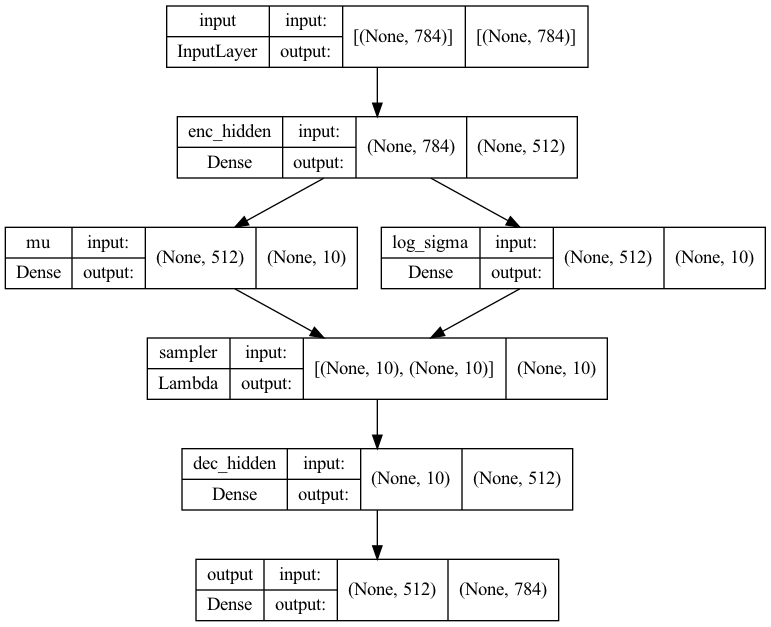

In [21]:
tmp=tf.keras.utils.plot_model(vae, show_shapes=True); tmp.width=500; tmp

- Construct the generator (decoder)
  - attach another input to the decoder layers, and connect them

In [18]:
# generator, from latent space to reconstructed inputs
decoder_input = Input(shape=(latent_dim,))  # make an input and attach it to the hidden state layer
_h_decoded = decoder_h(decoder_input)       # and other layers
_x_decoded_mean = decoder_mean(_h_decoded)

# the generator model
generator = Model(decoder_input, _x_decoded_mean)

- Decoder (generator)

In [23]:
generator.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 10)]              0         
                                                                 
 dec_hidden (Dense)          (None, 512)               5632      
                                                                 
 output (Dense)              (None, 784)               402192    
                                                                 
Total params: 407,824
Trainable params: 407,824
Non-trainable params: 0
_________________________________________________________________


- define the VAE loss function

In [19]:
# define the VAE loss
def vae_loss(x, x_decoded_mean):
    # cross-entropy loss (recontruction loss)
    xent_loss = keras.losses.binary_crossentropy(x, x_decoded_mean)
    # KL divergence loss  (regularizer)
    kl_loss = -0.5 * K.mean(1 + z_log_sigma - K.square(z_mean) - K.exp(z_log_sigma), axis=-1)
    return xent_loss + kl_loss

# compile the model for optimization
vae.compile(optimizer='rmsprop', loss=vae_loss)

- Fit the model

In [24]:
history = vae.fit(vtrainXraw, vtrainXraw,
            shuffle=True,
            epochs=epochs,
            batch_size=batch_size,
            validation_data=(validXraw, validXraw),        
            callbacks=[TensorBoard(log_dir='./logs/vae')],
            verbose=False
           )

Metal device set to: Apple M1 Max


2023-01-25 20:22:47.299282: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-01-25 20:22:47.299421: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2023-01-25 20:22:47.307580: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
2023-01-25 20:22:47.307688: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2023-01-25 20:22:47.321445: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2023-01-25 20:22:47.375246: I tensorflow/core/grappler/o

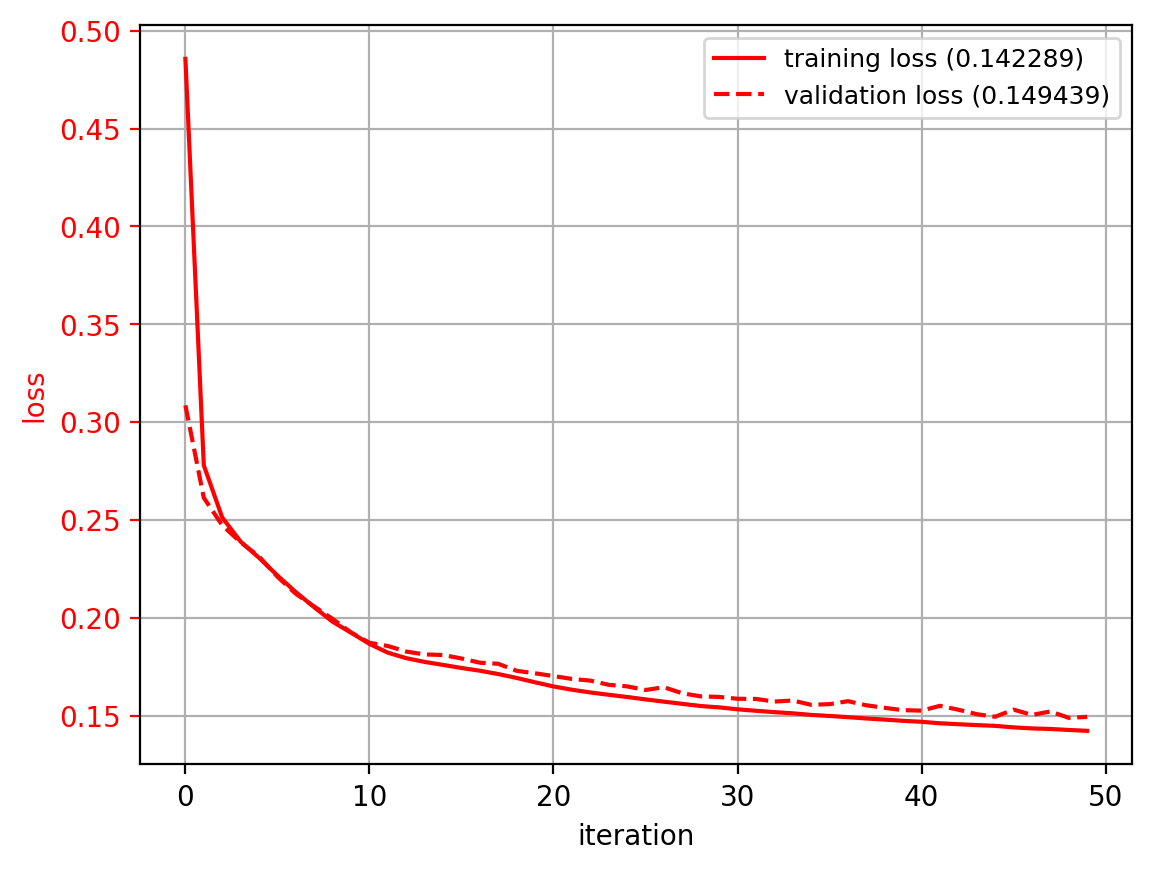

In [25]:
plot_history(history)

- View t-SNE embedding fo the latent space.

In [26]:
def plot_embedding(X, Y, perplexity=30.):
    #IPython.core.display.set_matplotlib_formats("retina") # switch to png since the next figure is complex
    tsne = manifold.TSNE(n_components=2, init='pca', perplexity=perplexity, random_state=11)
    x_pts = tsne.fit_transform(X)
    fig = plt.figure(figsize=(8,8))
    plt.scatter(x_pts[:, 0], x_pts[:, 1], c=Y, s=2, cmap=plt.get_cmap('jet'))
    plt.grid()
    plt.show()
    plt.close()
    #IPython.core.display.set_matplotlib_formats("svg")

/Users/abc/miniforge3/envs/py38tfm28/lib/python3.8/site-packages/keras/engine/training_v1.py:2079: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,
2023-01-25 20:23:05.313357: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


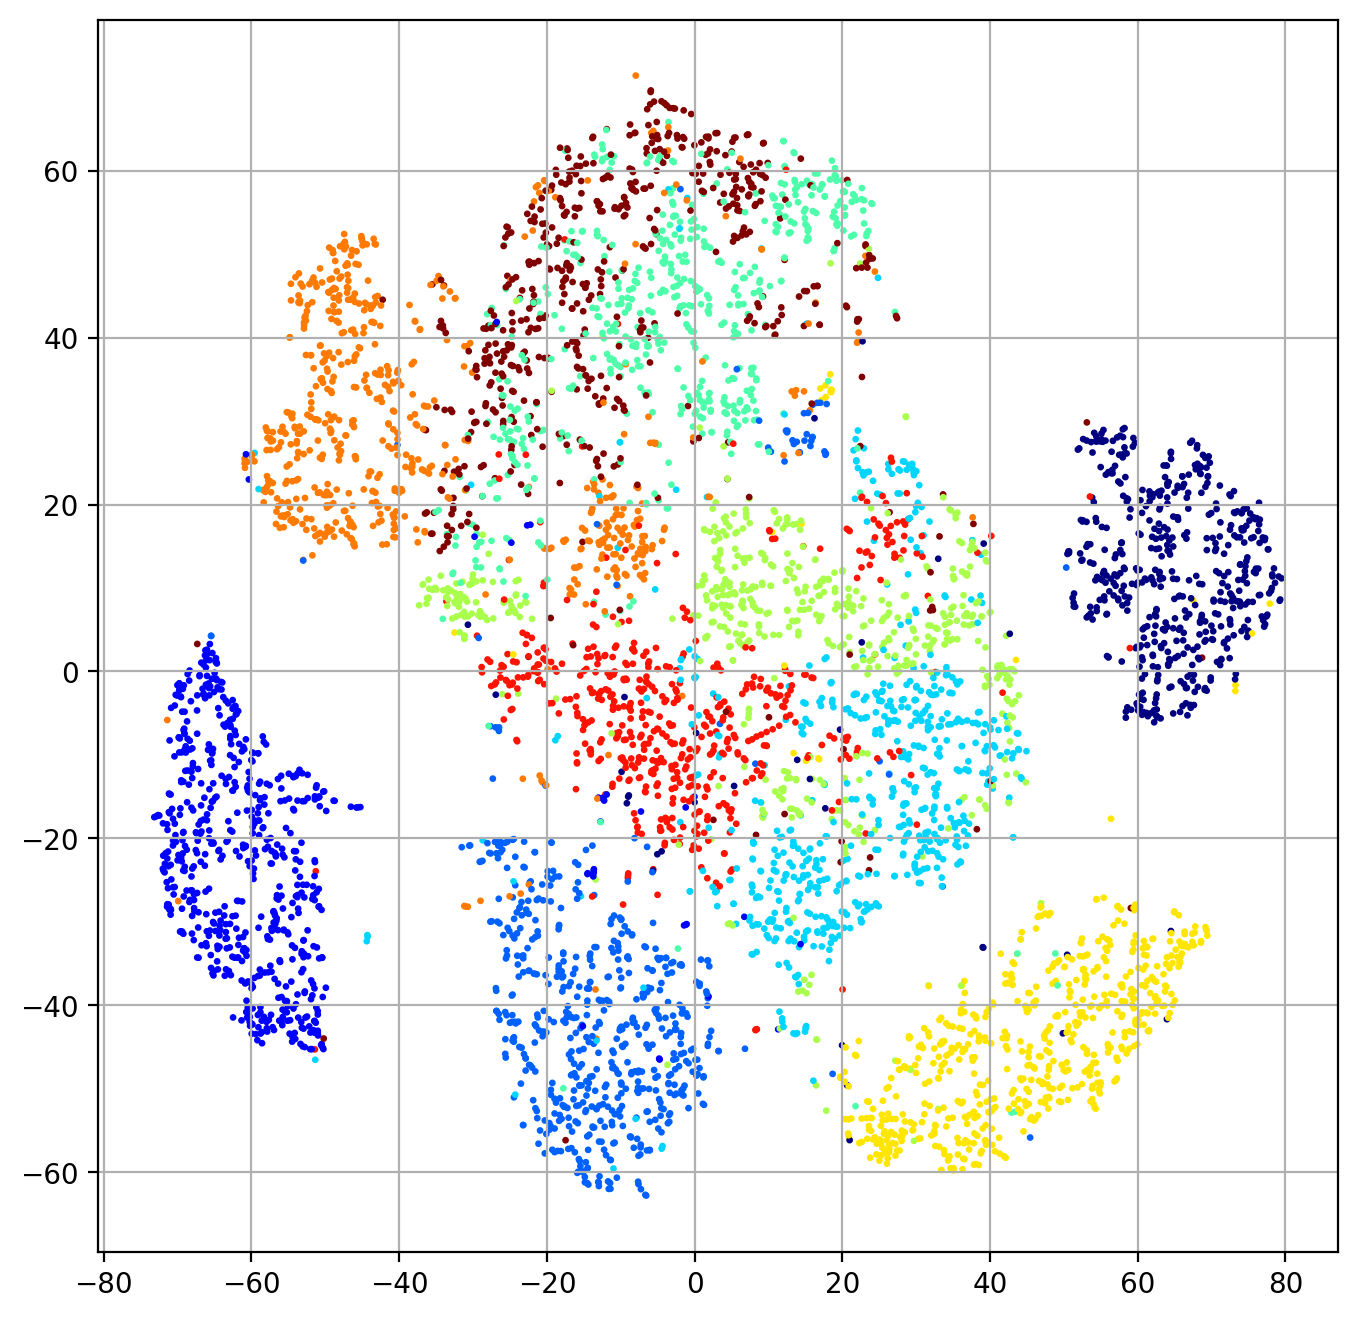

In [27]:
Z = encoder.predict(trainXraw)
plot_embedding(Z, trainY)

- View some reconstruction results

In [28]:
testXrecon = generator.predict(encoder.predict(testXraw))
imglist = []
for j,i in enumerate(range(0,100,10)):
    tmp = hstack( (testXraw[i].reshape((28,28)), testXrecon[i].reshape((28,28))) )
    imglist.append(tmp)
rfig = plt.figure(figsize=(10,3))
show_imgs(imglist,nc=5)
plt.close()

/Users/abc/miniforge3/envs/py38tfm28/lib/python3.8/site-packages/keras/engine/training_v1.py:2079: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,
2023-01-25 20:23:19.462362: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


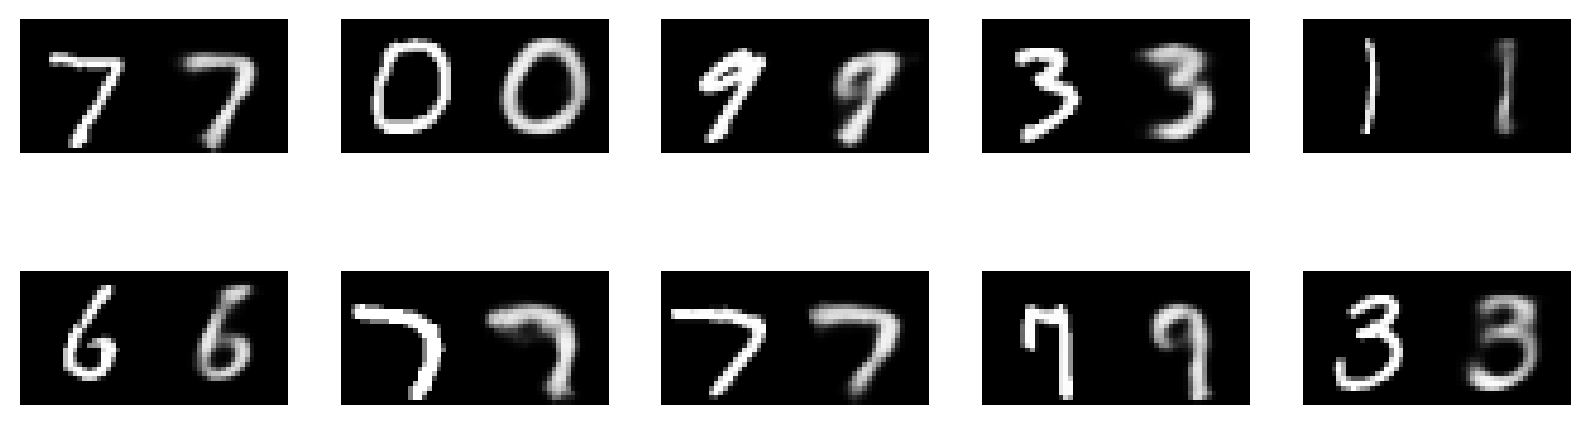

In [29]:
rfig

- visualize the latent space by interpolating between 

In [30]:
def Xinterp(X,sp=10):
    alpha = linspace(0,1,sp).reshape((sp,)+(ndim(X)-1)*(1,))
    Xint = X[0,:]*(1-alpha) + X[1,:]*alpha
    return Xint

def Xinterp2(X, sp=10):
    # [TL, TR, BL, BR]
    
    Xtbl = Xinterp(X[[0,2],:], sp=sp)
    Xtbr = Xinterp(X[[1,3],:], sp=sp)
    
    # interpolate inbetween    
    Xall = zeros((sp*sp,) + Xtbl.shape[1:])
    
    tmps = array(Xtbl.shape)
    tmps[0] = 1
    for i in range(sp):
        tmpX = concatenate((Xtbl[i,:].reshape(tmps), Xtbr[i,:].reshape(tmps)), axis=0)
        Xall[sp*i:sp*(i+1),:] = Xinterp(tmpX, sp=sp)
    return Xall

In [31]:
mydigits = where(testY==7)[0]
inds = mydigits[15:19]
X = encoder.predict(testXraw[inds,:])
Xd = generator.predict(Xinterp2(X,sp=8))
rfig = plt.figure(figsize=(6,6))
show_imgs(Xd.reshape((64,28,28)),nc=8)
plt.close()

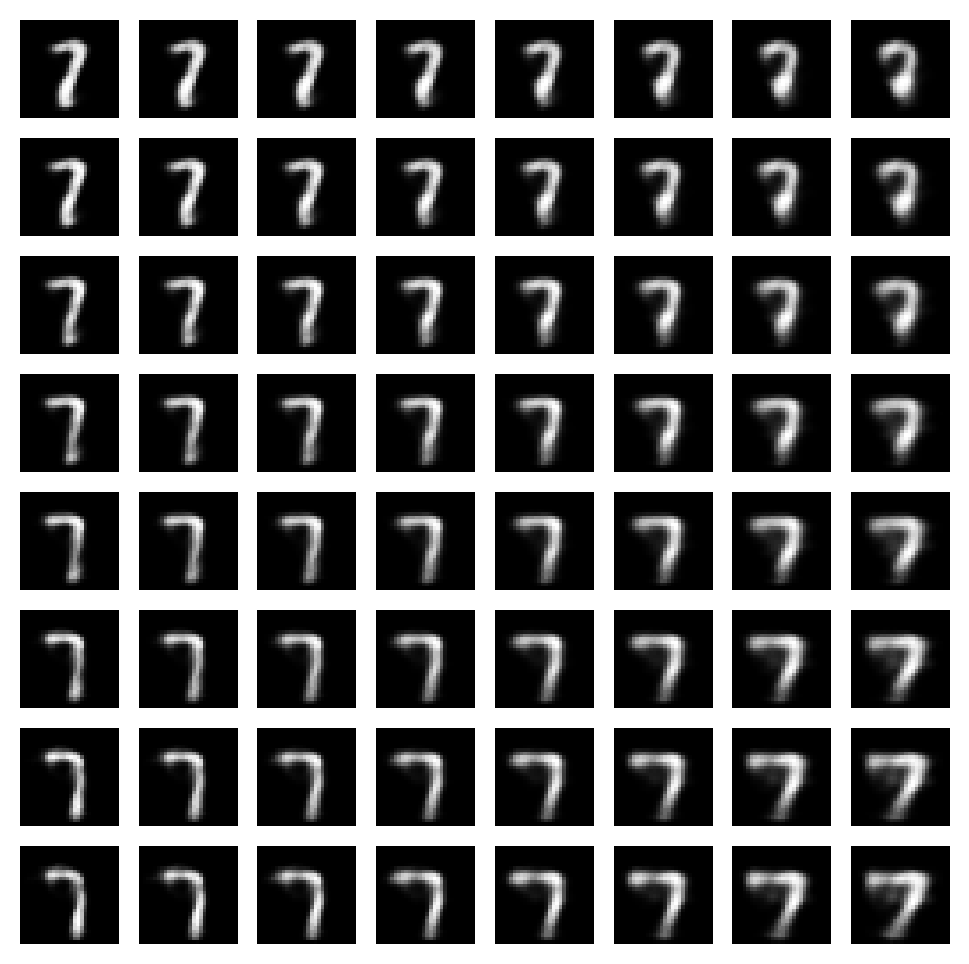

In [32]:
rfig

In [33]:
mydigits = where(testY==9)[0]
inds = mydigits[9:13]
X = encoder.predict(testXraw[inds,:])
Xd = generator.predict(Xinterp2(X,sp=8))
rfig = plt.figure(figsize=(6,6))
show_imgs(Xd.reshape((64,28,28)),nc=8)
plt.close()

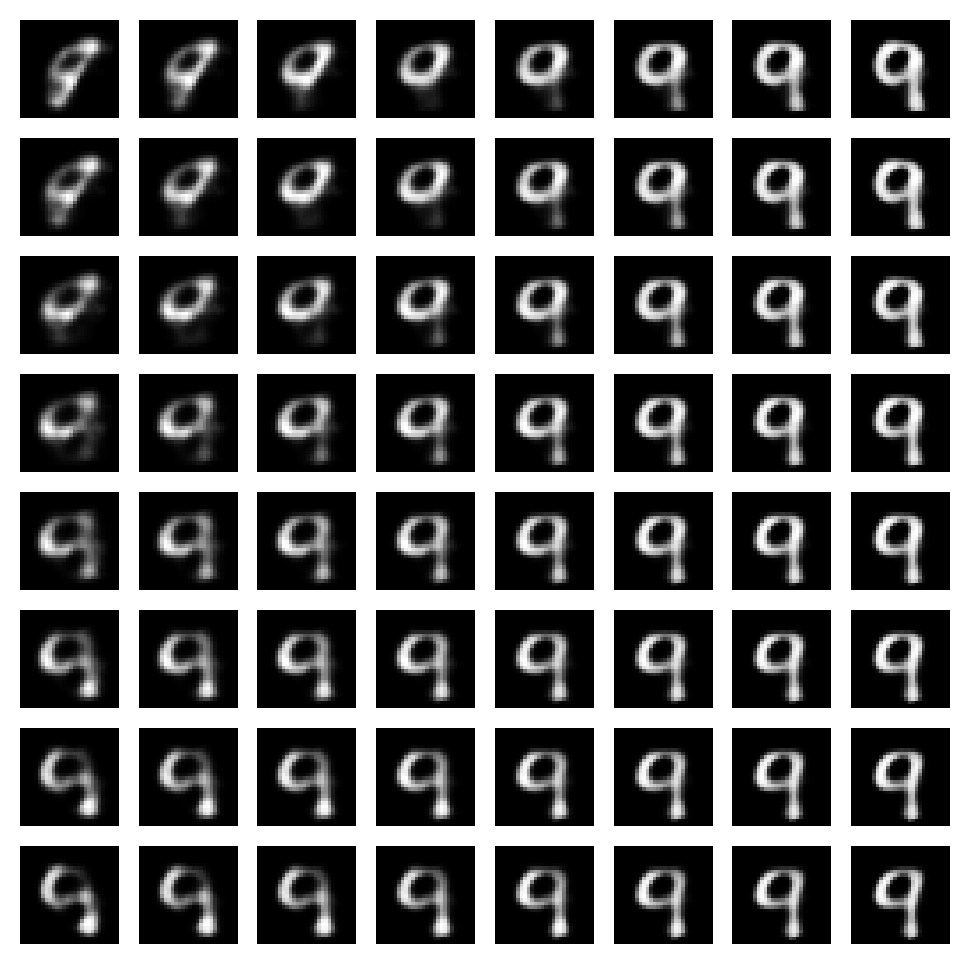

In [34]:
rfig

# Convolutional VAE
- The previous VAE is using fully-connected layers
- Since the inputs are images, then replace the Dense layers with Conv2D and Pooling
  - The encoder has 3 outputs: the latent mean, log-sigma, and the sampled z
  - Latent dimension is 10

In [35]:
# the Conv2D encoder
K.clear_session()
random.seed(4487); tf.random.set_seed(4487)

latent_dim = 10
input_img2 = Input(shape=(28, 28, 1), name='input')
x = Conv2D(16, (3, 3), activation='relu', padding='same', name='enc_conv1')(input_img2)
x = MaxPooling2D((2, 2), padding='same', name='enc_pool1')(x)
x = Conv2D(8, (3, 3), activation='relu', padding='same', name='enc_conv2')(x)
x = MaxPooling2D((2, 2), padding='same', name='enc_pool2')(x)
x = Conv2D(8, (3, 3), activation='relu', padding='same', name='enc_conv3')(x)
x = MaxPooling2D((2, 2), padding='same', name='enc_pool3')(x)
x = Flatten(name='enc_hidden')(x)

# the mean and log-sigma
z_mean      = Dense(latent_dim, name='mu')(x)
z_log_sigma = Dense(latent_dim, name='log_sigma')(x)

In [36]:
# sampling step
epsilon_std = 0.01
def sampling(args):
    z_mean, z_log_sigma = args
    epsilon = K.random_normal(shape=K.shape(z_mean), stddev=epsilon_std)
    return z_mean + K.exp(z_log_sigma) * epsilon

z = Lambda(sampling, name='sampler')([z_mean, z_log_sigma])

# build the encoder (outputs mean, log-sigma, and z)
encoder = Model(input_img2, [z_mean, z_log_sigma, z], name='encoder')

- Encoder summary

In [37]:
encoder.summary()

Model: "encoder"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input (InputLayer)             [(None, 28, 28, 1)]  0           []                               
                                                                                                  
 enc_conv1 (Conv2D)             (None, 28, 28, 16)   160         ['input[0][0]']                  
                                                                                                  
 enc_pool1 (MaxPooling2D)       (None, 14, 14, 16)   0           ['enc_conv1[0][0]']              
                                                                                                  
 enc_conv2 (Conv2D)             (None, 14, 14, 8)    1160        ['enc_pool1[0][0]']              
                                                                                            

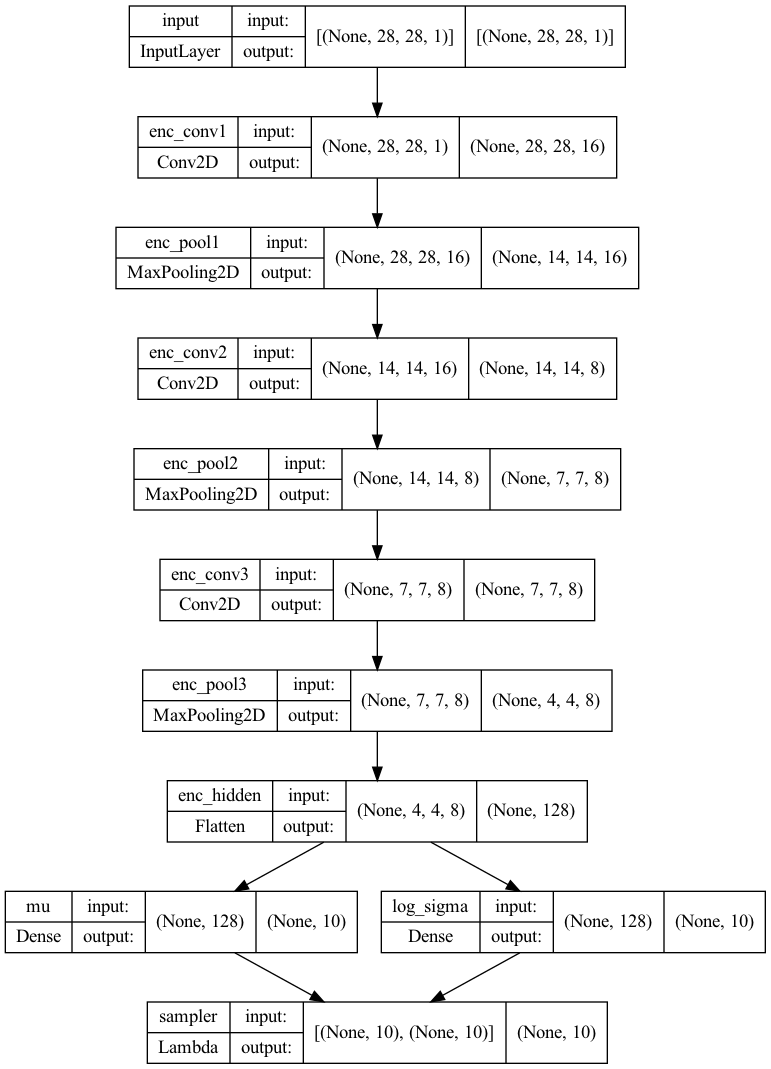

In [38]:
tmp=tf.keras.utils.plot_model(encoder, show_shapes=True); tmp.width=300; tmp

- Same for the decoder

In [39]:
# the Conv2D decoder
encoded_input2 = Input(shape=(latent_dim,))
x = Dense(128, activation='relu', name='dec_hidden')(encoded_input2)
x = Reshape((4,4,8), name='dec_reshape')(x)
x = Conv2D(8, (3, 3), activation='relu', padding='same', name='dec_conv1')(x)
x = UpSampling2D((2, 2), name='dec_up1')(x)
x = Conv2D(8, (3, 3), activation='relu', padding='same', name='dec_conv2')(x)
x = UpSampling2D((2, 2), name='dec_up2')(x)
x = Conv2D(16, (3, 3), activation='relu', name='dec_conv3')(x)
x = UpSampling2D((2, 2), name='dec_up3')(x)
x = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name='output')(x)

decoder = Model(encoded_input2, x, name='decoder')

In [40]:
decoder.summary()

Model: "decoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 10)]              0         
                                                                 
 dec_hidden (Dense)          (None, 128)               1408      
                                                                 
 dec_reshape (Reshape)       (None, 4, 4, 8)           0         
                                                                 
 dec_conv1 (Conv2D)          (None, 4, 4, 8)           584       
                                                                 
 dec_up1 (UpSampling2D)      (None, 8, 8, 8)           0         
                                                                 
 dec_conv2 (Conv2D)          (None, 8, 8, 8)           584       
                                                                 
 dec_up2 (UpSampling2D)      (None, 16, 16, 8)         0   

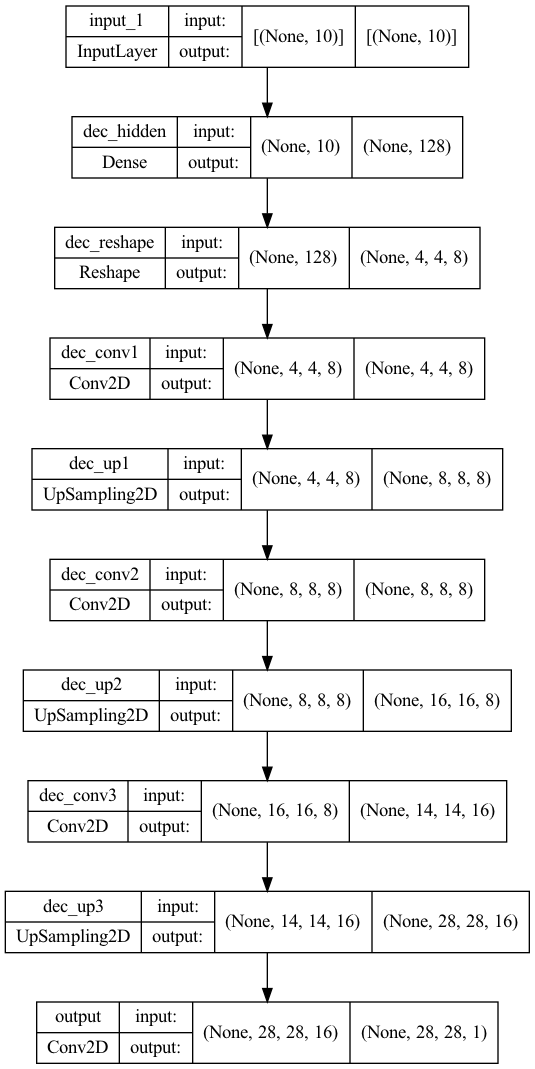

In [41]:
tmp=tf.keras.utils.plot_model(decoder, show_shapes=True); tmp.width=250; tmp

- make VAE: 
  - connect the encoder and decoder
  - select the sampled z of the encoder output as the input into  the decoder

In [42]:
vae = Model(input_img2, decoder(encoder(input_img2)[2]))

In [43]:
vae.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 28, 28, 1)]       0         
                                                                 
 encoder (Functional)        [(None, 10),              4484      
                              (None, 10),                        
                              (None, 10)]                        
                                                                 
 decoder (Functional)        (None, 28, 28, 1)         3889      
                                                                 
Total params: 8,373
Trainable params: 8,373
Non-trainable params: 0
_________________________________________________________________


- The VAE loss as before

In [44]:
def vae_loss(x, x_decoded_mean):
    xent_loss = keras.losses.binary_crossentropy(x, x_decoded_mean)
    kl_loss = - 0.5 * K.mean(K.mean(1 + z_log_sigma - K.square(z_mean) 
                                    - K.exp(z_log_sigma), axis=-1), axis=-1)
    return xent_loss + kl_loss
vae.compile(optimizer='adam', loss=vae_loss)

- Train the model

In [45]:
 # early stopping criteria
earlystop = keras.callbacks.EarlyStopping(monitor='val_loss', 
                            min_delta=0.0001, patience=10,
                            verbose=1, mode='auto')

history = vae.fit(vtrainI, vtrainI,
            shuffle=True,
            epochs=epochs,
            batch_size=batch_size,
            validation_data=(validI, validI),        
            callbacks=[earlystop, TensorBoard(log_dir='./logs/vae')],
            verbose=False
           )

2023-01-25 20:23:21.735836: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-01-25 20:23:21.735855: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2023-01-25 20:23:21.750214: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2023-01-25 20:23:21.775544: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2023-01-25 20:23:21.849793: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2023-01-25 20:23:22.26

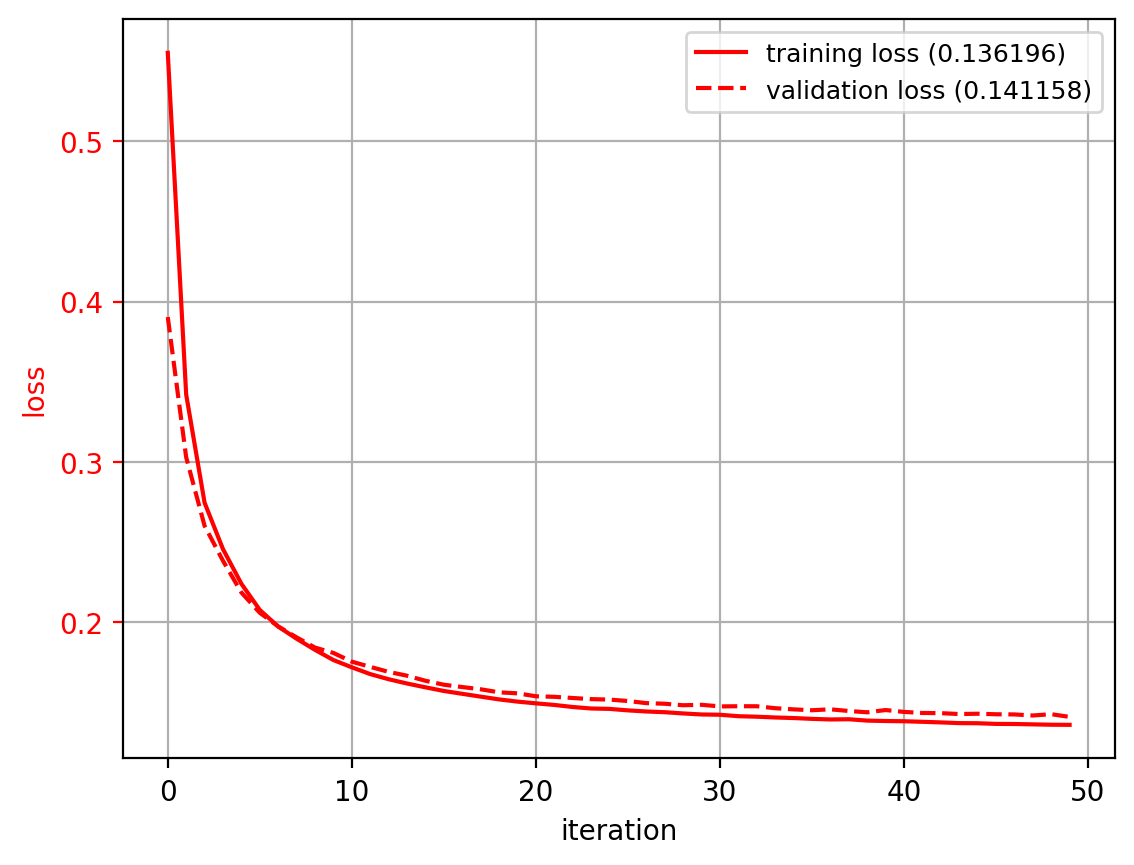

In [46]:
plot_history(history)

- Visualize the 10-dim latent space using t-SNE

/Users/abc/miniforge3/envs/py38tfm28/lib/python3.8/site-packages/keras/engine/training_v1.py:2079: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,
2023-01-25 20:24:14.464274: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


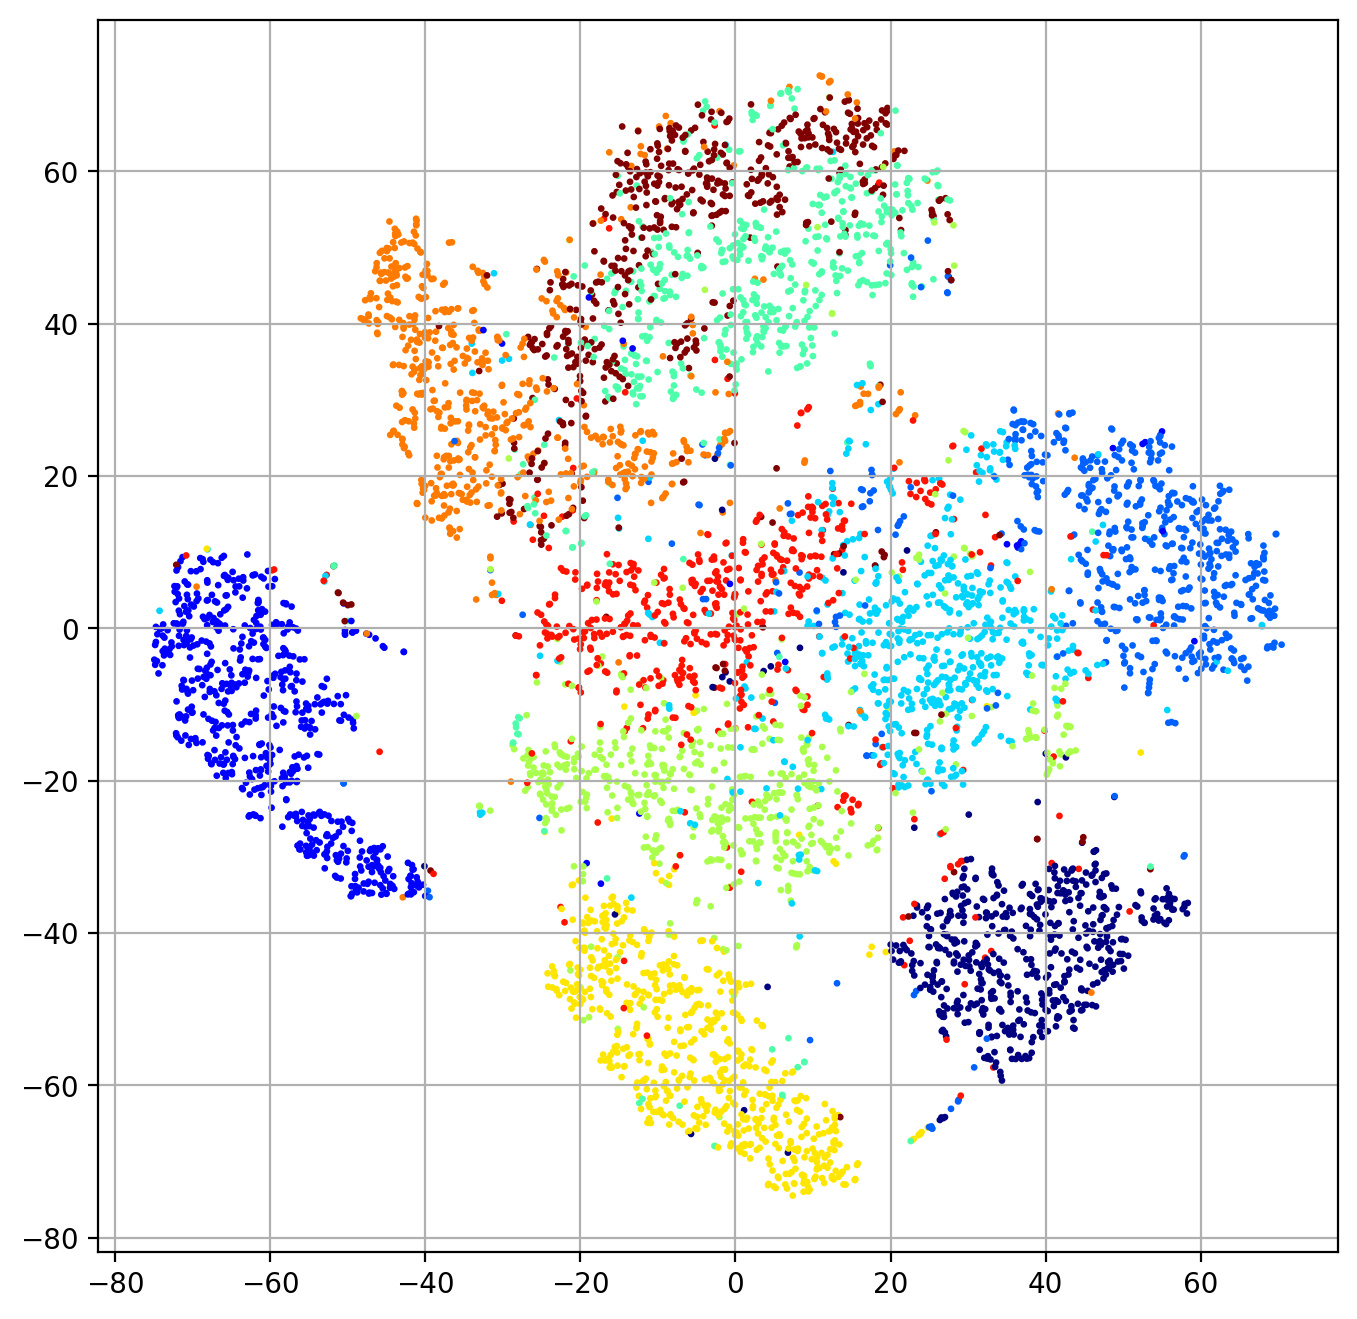

In [47]:
# select z_mean from the encoder
Z = encoder.predict(trainI)[0]
plot_embedding(Z.reshape((Z.shape[0],-1)), trainY)

- Visualize the reconstruction

In [48]:
testIrecon = decoder.predict(encoder.predict(testI)[0])
imglist = []
for j,i in enumerate(range(0,100,10)):
    tmp = hstack( (testI[i].reshape((28,28)), testIrecon[i].reshape((28,28))) )
    imglist.append(tmp)
rfig = plt.figure(figsize=(10,3))
show_imgs(imglist,nc=5)
plt.close()

/Users/abc/miniforge3/envs/py38tfm28/lib/python3.8/site-packages/keras/engine/training_v1.py:2079: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,
2023-01-25 20:24:28.486428: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


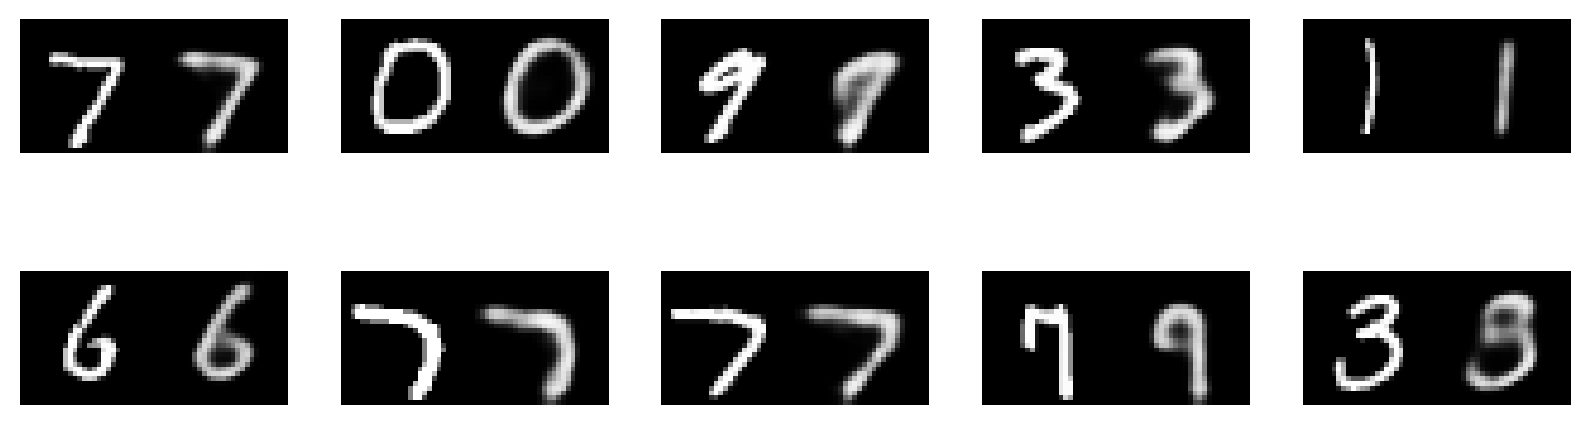

In [49]:
rfig

- Visualize the latent space between a 7, 1, 9, and 4

In [50]:
inds = [0, 40, 20, 19] #6
X = encoder.predict(testI[inds,:])[0]
Xd = decoder.predict(Xinterp2(X,sp=8))
rfig = plt.figure(figsize=(6,6))
show_imgs(Xd.reshape((64,28,28)),nc=8)
plt.close()

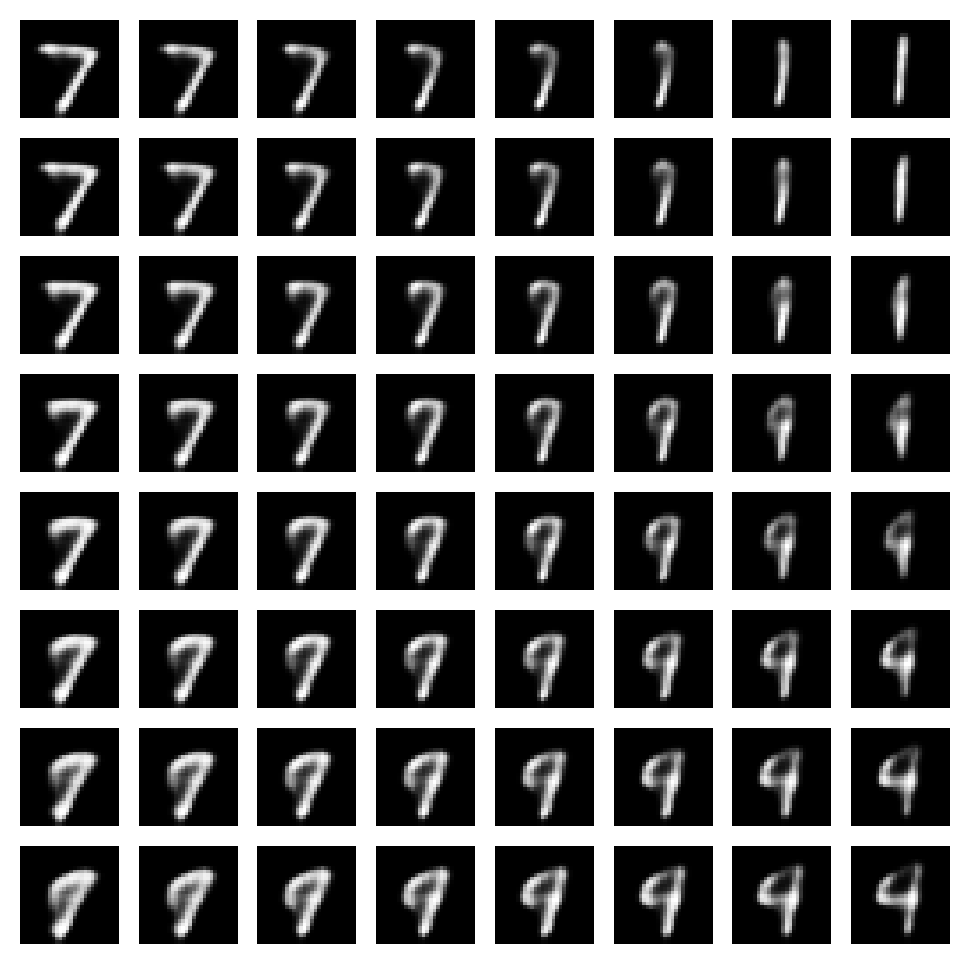

In [51]:
rfig

# Generative Adversarial Networks (GAN)

- **Goal:** generate samples from a probability density $p_{data}(x)$ which is represented by a training set $\{x_i\}$.
- Setup
  - *true data samples:* $x \sim p_d(x)$
    - we have samples ${\cal X} = \{x_i\}$, but not $p_d$.
  - *generated samples:* $x \sim p_m(x)$
    - use the reparam trick to generate samples
    - $x=g(z)$, $z\sim N(0,I)$
    - $g(\cdot)$ is a neural network
  - Usually maximize the likelihood of $p_m(x)$  using samples $\cal X$.
- **Problem:**
  - cannot explicitly compute $p_m(x)$ because of the reparam trick.

- **Solution:** look at the samples directly  
- Build a classifier to predict whether a sample is *real* (from training samples) or *fake* (generated)

<table><tr><td><img src="imgs/gan-eg-1.png"></td><td><img src="imgs/gan-eg-2.png"></td></tr><tr><td><img src="imgs/gan-eg-3.png"></td><td><img src="imgs/gan-eg-4.png"></td></tr></table>


- Two models:
  - Generator (G) - make fake samples to fool the discriminator
  - Discriminator (D) - classify $x$ as real or fake<center><img src="imgs/GAN.png" width=500></center>

- **Advantages:**
  - don't need to approximate the likelihood function or inference procedure
  - don't need the partition function (normalization constant)
  - easy to generate samples (good for synthesis)
- **Disadvantages:**
  - cannot compute the likelihood value (probability density) of a sample
  - difficult to train
  - ...

# GAN Training

- Define two class labels:
  - $y=1$ means "real" sample
  - $y=0$ means "fake" sample
- Define discriminator (classifier): $D(x) = p(y=1|x)$
  - probability of real sample
- Cross-entropy loss to train the discriminator
  - let $\{x_i,y_i\}$ be a dataset of true/fake samples.
  
$$\begin{aligned}&\min_D -\sum_i y_i \log D(x_i) + (1-y_i) \log (1-D(x_i))\\
&=\max_D  \underbrace{\sum_{y_i=1} \log D(x_i)}_{\text{real examples}} + \underbrace{\sum_{y_i=0} \log (1-D(x_i))}_{\text{generated examples}} \end{aligned}$$


- Replace the sum of samples with expectations

$$\begin{aligned}&\max_D  \sum_{y_i=1} \log D(x_i) + \sum_{y_i=0} \log (1-D(x_i)) \\
&=\max_D  \mathbb{E}_{x\sim p_d}[\log D(x_i)] + \mathbb{E}_{x\sim p_m}[\log (1-D(x_i))] \\
&=\max_D  \mathbb{E}_{x\sim p_d}[\log D(x_i)] + \mathbb{E}_{z\sim {\cal N}(0,I)}[\log (1-D(G(z))]
\end{aligned}$$



- The G's objective is to maximize the cross entropy loss, i.e., make $D$ predict wrongly. 
- Final training problem:
  $$ \min_G \max_D  \mathbb{E}_{x\sim p_d}[\log D(x_i)] + \mathbb{E}_{z\sim {\cal N}(0,I)}[\log (1-D(G(z))]$$
- **Notes:**
  - it is a *minimax* game (zero-sum game)
    - the values for D and G move in opposite directions
    - the equilibrium point is a *saddle* point
      - i.e., a local max for D, and local min for G
  - G can also be trained to make the D predict "real"
    - $\min_G -\mathbb{E}_z[\log D(G(z))]$
    - i.e., pass the generated samples with "real" class label to D

# Analysis of GAN
- Assuming that G and D have enough capacity
- Considering the defined training problem:
  - the optimal discriminator is
    - $D^*(x) = \frac{p_d(x)}{p_d(x)+p_m(x)} = p(\text{real}|x)$
  - given the optimal discriminator, the optimal generator is
    - $p^*_m(x) = p_d(x)$
- thus, ideally, we can obtain the true distribution.

In [52]:
def compute_xform_pdf(f):
    tmp_x = linspace(0.001,0.999,201)
    tmp_n = stats.norm.ppf(tmp_x)
    tmp_g = (f(tmp_n)).ravel()
    tmp_p = abs((tmp_x[1]-tmp_x[0]) / (tmp_g[1:] - tmp_g[0:-1]))
    tmp_x2 = 0.5*(tmp_g[1:] + tmp_g[0:-1])
    return tmp_x2, tmp_p

def get_bounds(f, factor=0.2):
    tmpx,tmpp = compute_xform_pdf(f)
    minx = min(tmpx)
    maxx = max(tmpx)
    dx = maxx-minx    
    return (minx-dx*factor, maxx+dx*factor)

In [53]:
def compute_xform_pdf2(f):
    npts=201
    npts2=201
    # transform the cdf
    tmp_x = linspace(0.001,0.999,npts)
    tmp_n = stats.norm.ppf(tmp_x)
    tmp_g = (f(tmp_n)).ravel()
    # take derivative to get pdf
    tmp_p = abs((tmp_x[1]-tmp_x[0]) / (tmp_g[1:] - tmp_g[0:-1]))
    tmp_x2 = 0.5*(tmp_g[1:] + tmp_g[0:-1])
    
    # re-interpolate evenly on x
    minx = min(tmp_x2)
    maxx = max(tmp_x2)
    xx = linspace(minx, maxx, npts2)
    pp = zeros((npts2,))

    # find change in direction
    xdx = diff(tmp_x2)    
    #ii = where(abs(xdx)<1e-10)[0]
    #xdx[ii] = xdx[ii+1]
    dx = sign(xdx)  # dx[i]  = sign of x[i+1]-x[i]
    ddx = sign(diff(dx)) # ddx[i] = change starts at position x[i+2]
    changes = where(ddx)[0]
    changes = concatenate((changes, [len(ddx)]))
    #print(xdx)
    #print(dx)
    #plt.plot(tmp_x2, tmp_p, 'k-')
    
    i = 0
    for j in changes:
        inds = range(i,j+2)  
        if tmp_x2[inds[0]] > tmp_x2[inds[-1]]:
            inds = flip(inds)
        newp = interp(xx, tmp_x2[inds], tmp_p[inds], left=0, right=0)        
        #plt.plot(xx, newp, '.:')
        pp += newp
        i = j+1
    
    #plt.plot(xx, pp, 'b-')
    return xx, pp

In [54]:
def plot_epoch(noise_gen=None, sample_batch=None, title="", onlygt=False):
    fig=plt.figure(figsize=(10,2.5))
    plt.subplot(1,2,1)
    # plot the samples from noise source
    bins = linspace(-3,3,31)
    if not onlygt:
        plt.hist(noise_gen, bins, color='magenta', alpha=0.5, label='noise samples', density=True)
    # plot the pdf
    tmp_b = linspace(-3,3,500)
    plt.plot(tmp_b, stats.norm.pdf(tmp_b), 'm-', label='noise pdf')
    plt.legend(loc='upper left')
    plt.title(title)
    plt.xlabel('z')
    plt.ylabel('p(z)')

    # plot the generator transformation function
    ax2=plt.gca().twinx()
    ax2.plot(tmp_b, xform(tmp_b), 'b-', label='true f(z)')
    if not onlygt:
        tmp_g = generator.predict(tmp_b.reshape((500,1)))
        ax2.plot(tmp_b, tmp_g, 'r-', label='fake f(z)')
    plt.grid(True)
    plt.legend(loc='upper right')
    plt.ylabel('f(z)')

    plt.subplot(1,2,2)
    # plot the true samples and fake samples
    if not onlygt:
        tmp_x2, tmp_p = compute_xform_pdf2(generator.predict)    
        generated_sample = generator.predict(noise_gen)
        bins = linspace(sample_range[0], sample_range[1], 31)
        diffb = bins[1]-bins[0]
        g_bins = bins
        if min(tmp_x2) < sample_range[0]:
            tmp = flip(arange(sample_range[0], min(tmp_x2)-diffb, -diffb))
            g_bins = concatenate((tmp[0:-1], g_bins))
        if max(tmp_x2) > sample_range[1]:
            tmp = arange(sample_range[1], max(tmp_x2)+diffb, diffb)
            g_bins = concatenate((g_bins, tmp[1:]))
            
        plt.hist(sample_batch, bins, color='blue', alpha=0.5, density=True)
        plt.hist(generated_sample, g_bins, color='red', alpha=0.5, density=True)
        plt.plot(sample_batch, -0.1*ones(sample_batch.shape), 'bx')
        plt.plot(generated_sample, -0.2*ones(generated_sample.shape), 'r+')

        # plot fake PDF
        plt.plot(tmp_x2, tmp_p, 'r-', label='fake pdf')

    # plot true PDF
    tmp_b, tmp_c = compute_xform_pdf2(xform)
    plt.plot(tmp_b, tmp_c, 'b-', label='true pdf')
    plt.legend(loc='upper left')
    plt.ylim(-0.3, max(tmp_c)*2.)
    plt.xlabel('x')
    plt.ylabel('p(x)')
    #plt.xlim(sample_range[0], sample_range[1])

    # plot the discriminator response
    if not onlygt:
        sr2 = linspace(sample_range[0], sample_range[1], 201)
        sr2 = linspace(g_bins[0], g_bins[-1], 201)
        ax2=plt.gca().twinx()
        tmp_d = discriminator.predict(sr2)
        ax2.plot(sr2, tmp_d, 'k--', label='p(real|x)')
        #plt.ylim([0.25,.75])
        plt.ylim([0.,1.])
        plt.yticks([0.5])
        ax2.legend(loc="upper right")
        plt.ylabel('D(x)')

    plt.grid()
    plt.tight_layout()
    #plt.show()
    plt.close()
    return fig

# 1-D GAN example
- the true distribution
  - transform `xform` of Gaussian(0,1)

In [55]:
# transformed gaussian
xform = lambda x: (0.5*x)+1
sample_range = get_bounds(xform)

In [56]:
# samples from the true distribution 
def sample(N, mu=0.0, sigma=1):
    samples = xform(random.normal(mu, sigma,N))
    return reshape(samples,(len(samples),1))

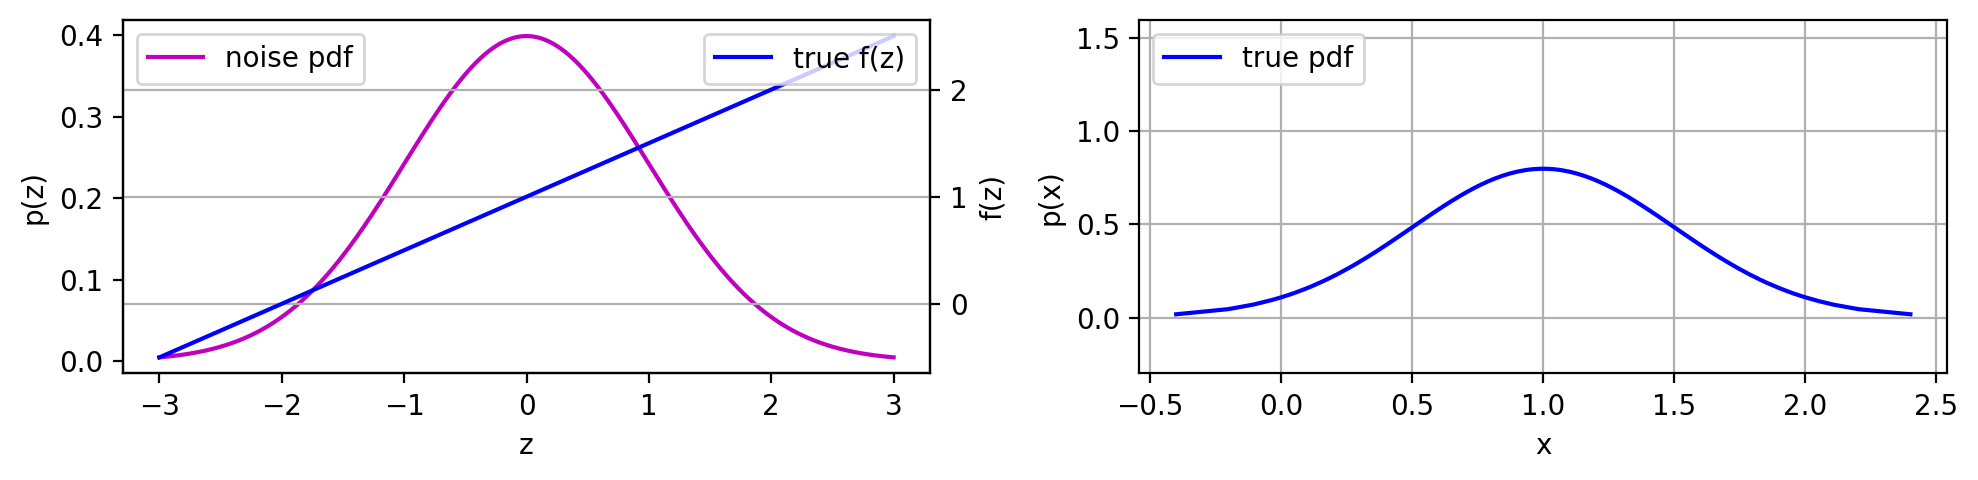

In [57]:
plot_epoch(onlygt=True)

- samples from the noise source

In [58]:
# samples from the generator noise source (Gaussian(0,1))
def g_sample(N,rng=5): 
    a = random.normal(0,1,N)
    return reshape(a,(len(a),1))

- function to build a generator
  - the input is a 1-D noise source
  - output is a 1-D sample

In [59]:
# build the generator
def gen(hidden_size, n_layers=2, activation="tanh"):
    g_input = Input(shape=[1],name="in1")
    x = g_input
    # hidden layers
    for n in range(n_layers):
        x = Dense(hidden_size, activation=activation, 
                  name="g{}".format(n))(x)
    # output layer
    ho = Dense(1, name="go")(x)
    g = Model(g_input,ho, name='generator')
    return g

- function to build a discriminator
  - the input is a 1-D sample
  - the output is class label (0=fake, 1=real)
  - need to `compile` since D is trained by itself

In [60]:
# build the discriminator
def disc(hidden_size, n_layers=2, activation='tanh'):
    inputd = Input(shape=[1],name="in2")
    x = inputd
    for n in range(n_layers):
        x = Dense( hidden_size * 2, activation=activation, 
                  name="d{}".format(n))(x)
    ho = Dense(1, activation="sigmoid", name="do")(x)
    d = Model(inputd, ho, name='discriminator')
    d.compile(loss="binary_crossentropy", optimizer="sgd", 
              metrics=['accuracy'])
    return d

- we will alternate training D and G
- this function sets the trainable flags in a `Model` to prevent/allow updating the weights

In [61]:
# set trainable flag for a model
def make_trainable(net, val):
    net.trainable = val   # this only works before compiling
    for l in net.layers:
        l.trainable = val # this works before/after compiling

- build the G and D
- connect G and D to make GAN
  - compile GAN for training G

In [62]:
K.clear_session()
random.seed(5489); tf.random.set_seed(5488)

# the generator
noise = Input(shape=[1])
generator = gen(10, activation='softplus')
g = generator(noise)

# the discriminator
discriminator = disc(10, activation='tanh')
d = discriminator(g)
make_trainable(discriminator, False)

# the GAN w/ noise input and discrim output
GAN = Model(noise, d)
GAN.compile(loss="binary_crossentropy", optimizer="sgd", metrics=['accuracy'])
GAN.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 1)]               0         
                                                                 
 generator (Functional)      (None, 1)                 141       
                                                                 
 discriminator (Functional)  (None, 1)                 481       
                                                                 
Total params: 622
Trainable params: 141
Non-trainable params: 481
_________________________________________________________________


In [63]:
generator.summary()

Model: "generator"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 in1 (InputLayer)            [(None, 1)]               0         
                                                                 
 g0 (Dense)                  (None, 10)                20        
                                                                 
 g1 (Dense)                  (None, 10)                110       
                                                                 
 go (Dense)                  (None, 1)                 11        
                                                                 
Total params: 141
Trainable params: 141
Non-trainable params: 0
_________________________________________________________________


In [64]:
discriminator.summary()

Model: "discriminator"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 in2 (InputLayer)            [(None, 1)]               0         
                                                                 
 d0 (Dense)                  (None, 20)                40        
                                                                 
 d1 (Dense)                  (None, 20)                420       
                                                                 
 do (Dense)                  (None, 1)                 21        
                                                                 
Total params: 962
Trainable params: 481
Non-trainable params: 481
_________________________________________________________________


In [65]:
def masub(x, subsample):
    tmp = convolve(x, ones((subsample,))/subsample, 'same')
    xx = range(subsample//2, len(tmp), subsample)
    return xx, tmp[xx]
    
    
def plot_epochs(epochs, subsample=20):
    plt.figure(figsize=(8,4))
    plt.subplot(2,1,1)
    plt.plot(*masub(epochs['d_loss'], subsample), label='discriminator loss')
    plt.plot(*masub(epochs['g_loss'], subsample), label='generator loss')
    plt.grid(True)
    plt.ylabel('loss')
    plt.legend()
    plt.subplot(2,1,2)
    plt.plot(*masub(epochs['d_acc'], subsample), label='discriminator acc')
    plt.plot(*masub(epochs['g_acc'], subsample), label='generator acc')
    plt.grid(True)
    plt.legend()
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.show()
    plt.close()

# GAN Training
- Loop over training the discriminator and the generator
  - train the discriminator well (20 updates), vs 1 update for the generator

In [66]:
def train_for_n(nb_epoch=50, plt_frq=25, BATCH_SIZE=100, lr=0.01, g_inner=1, d_inner=20):
    epochs = {'g_loss':[], 'g_acc':[], 'd_loss':[], 'd_acc':[], 'figs':[]}

    for e in range(nb_epoch): 
        #  Make generative sample
        sample_batch = sample(BATCH_SIZE) 
        noise_gen = g_sample(BATCH_SIZE)
        generated_sample = generator.predict(noise_gen)

        # Train discriminator on generated samples
        X = concatenate((sample_batch, generated_sample))
        # class 1=real, class 0 = fake
        y = concatenate((ones((BATCH_SIZE,)), zeros((BATCH_SIZE,))))

        # train the discriminator a few steps on this batch        
        make_trainable(discriminator,True)          # make it trainable
        K.set_value(discriminator.optimizer.lr, lr) # set the learning rate
        for i in range(d_inner):                    # train...
            d_loss = discriminator.train_on_batch(X,y) 

        epochs['d_loss'].append(d_loss[0])
        epochs['d_acc'].append(d_loss[1])
        
        # Train the generator
        y2 = ones((BATCH_SIZE,))  # target for generator is real class (1)
        noise_gen = g_sample(BATCH_SIZE)

        # keep discriminator fixed        

        # run a few updates on this batch      
        make_trainable(discriminator,False)  # freeze discriminator
        K.set_value(GAN.optimizer.lr, lr)    # set learning rate
        for i in range(g_inner):             # train.. .
            g_loss = GAN.train_on_batch(noise_gen, y2)

        epochs['g_loss'].append(g_loss[0])
        epochs['g_acc'].append(g_loss[1])
    
        # some plots
        if (e % plt_frq==0) or (e+1==nb_epoch):
            fig=plot_epoch(noise_gen, sample_batch, "epoch {}".format(e))
            epochs['figs'].append(fig)

    return epochs

- train the GAN for 3000 epochs

In [67]:
epochs = train_for_n(nb_epoch=3000, lr=0.01, plt_frq=500)

2023-01-25 20:24:30.842743: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-01-25 20:24:30.842764: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2023-01-25 20:24:30.847946: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2023-01-25 20:24:30.854803: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2023-01-25 20:24:30.887429: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2023-01-25 20:24:30.92

- Visualization:
  - (left) noise source and transformations
  - (right) true/fake pdfs; discriminator function $p(y=1|x)$ (prob of true sample)

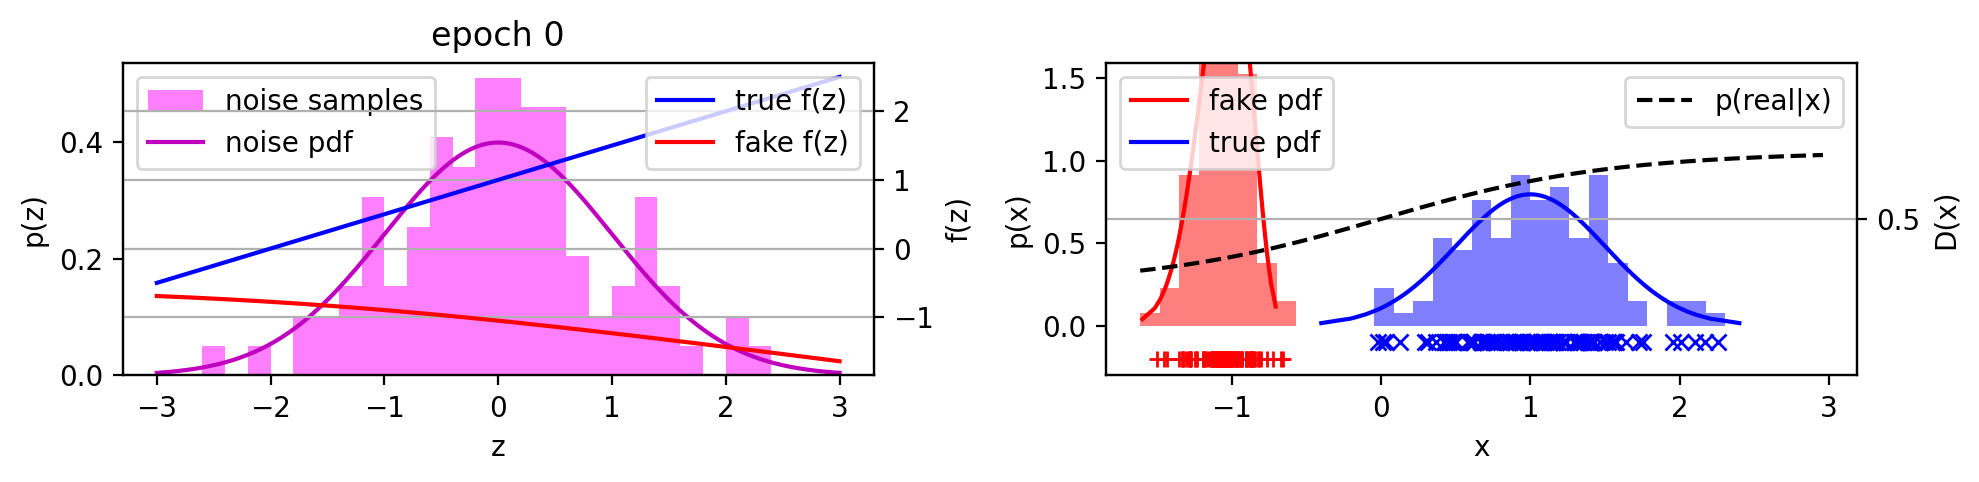

In [68]:
epochs['figs'][0]

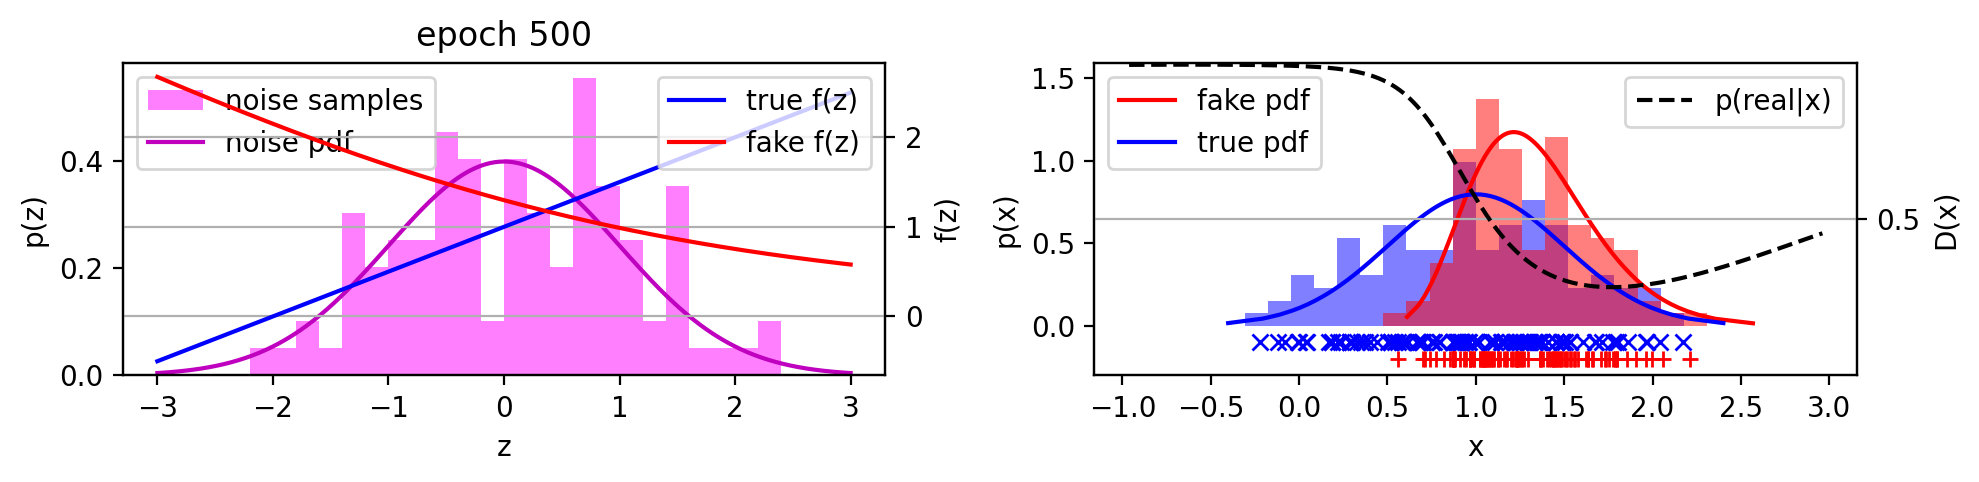

In [69]:
epochs['figs'][1]

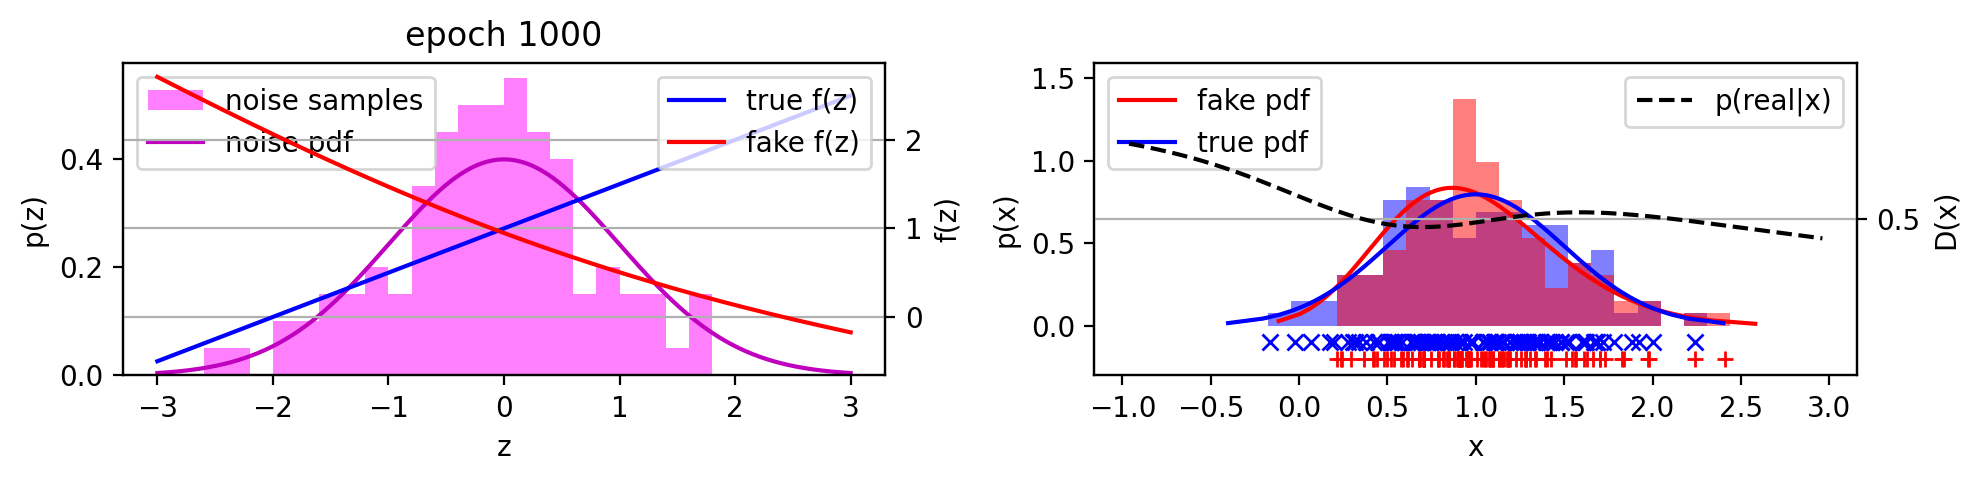

In [70]:
epochs['figs'][2]

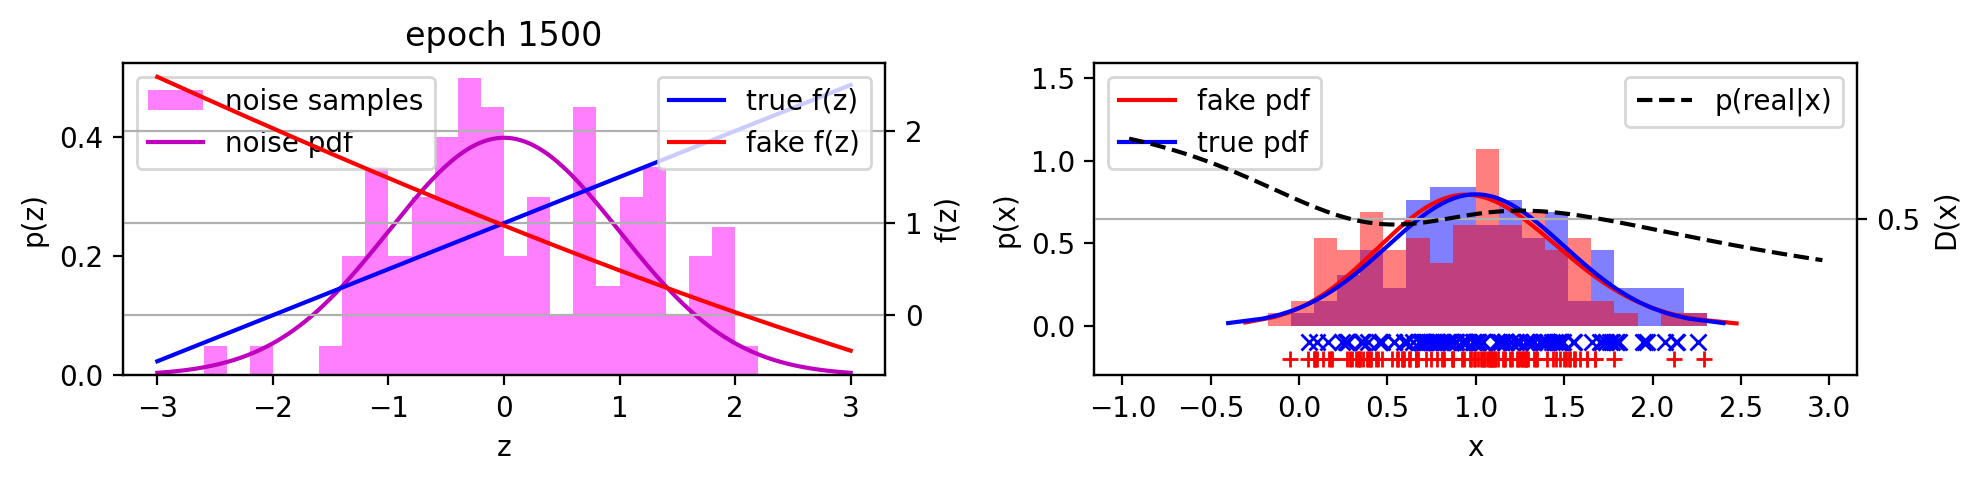

In [71]:
epochs['figs'][3]

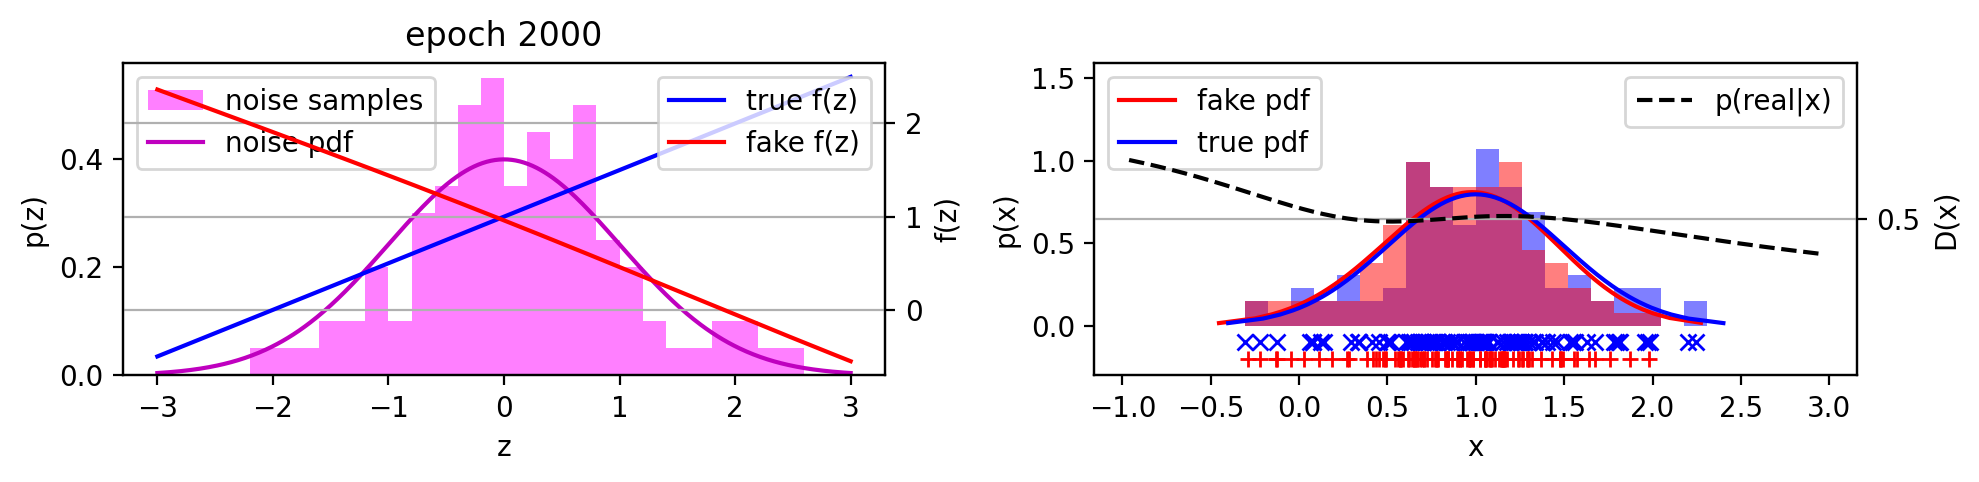

In [72]:
epochs['figs'][4]

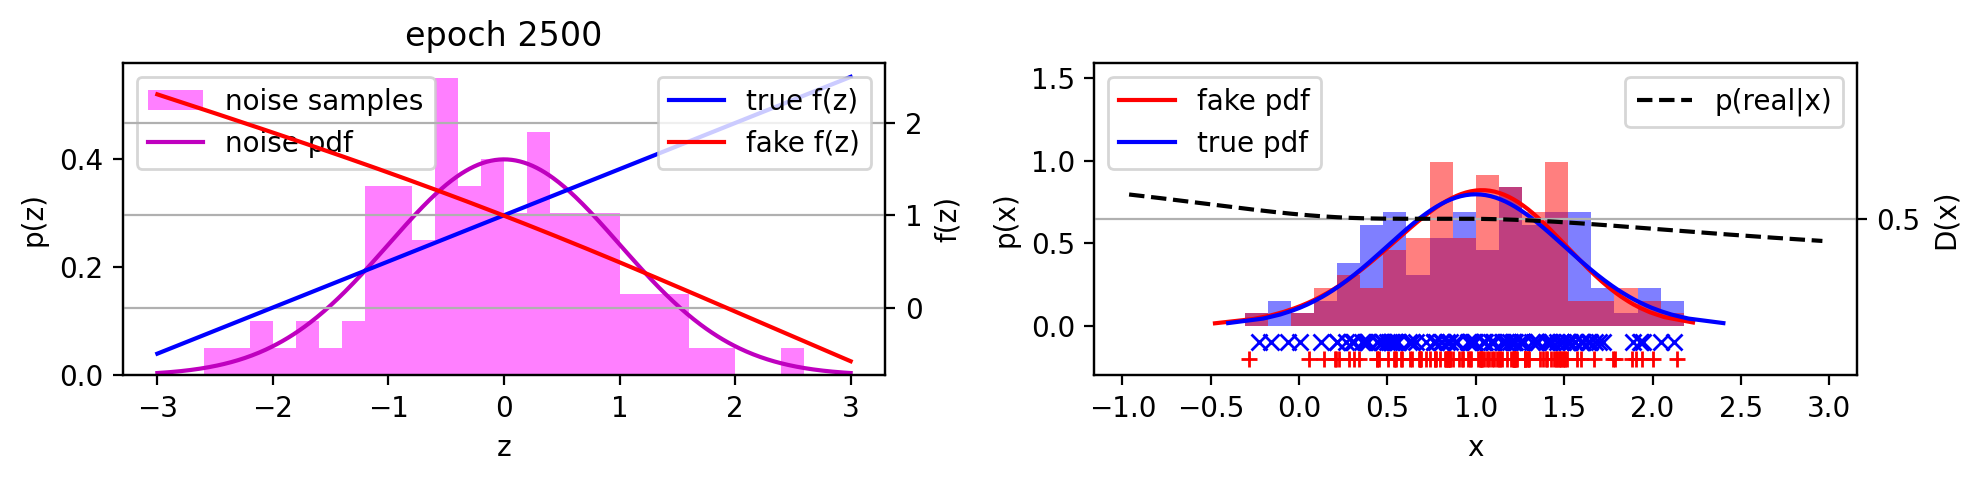

In [73]:
epochs['figs'][5]

- True and fake pdfs have converged.
  - discriminator can't tell the difference
  - However the actual function $f(z)$ is different, but since noise source is symmetric this is fine.

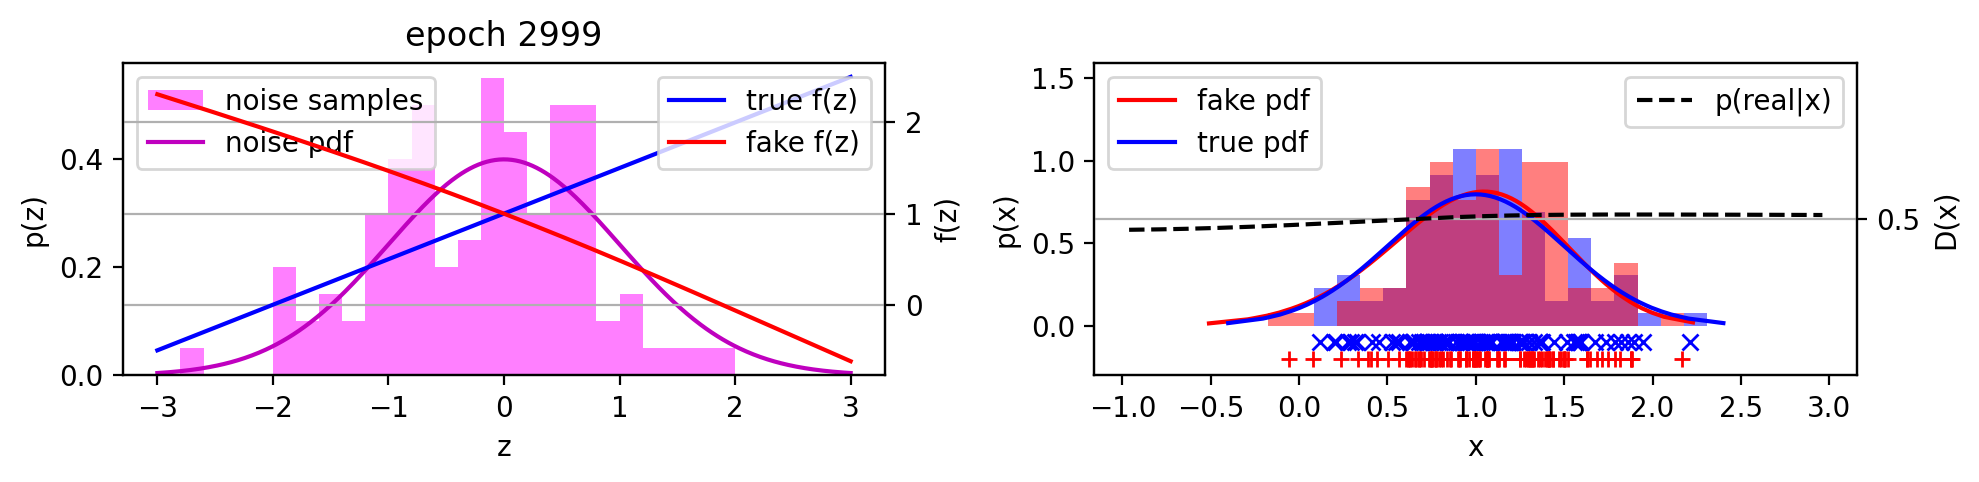

In [74]:
epochs['figs'][6]

- loss/accuracy during training. 
  - the values will oscillate, since the two networks are playing against each other.
  - at convergence, both G & D obtain 50% accuracy (random chance).

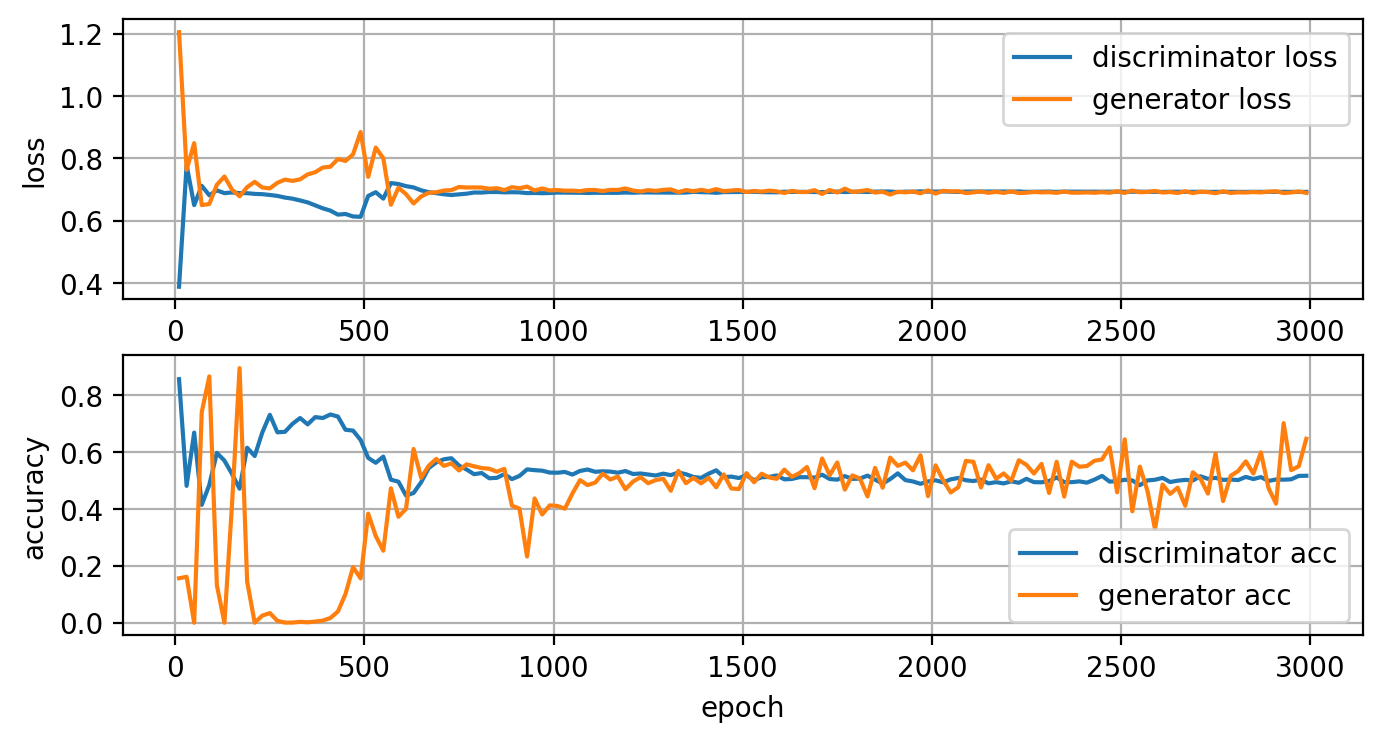

In [75]:
plot_epochs(epochs)

# Another example 
- distribution with a long-tail

In [76]:
xform = lambda x: abs(x)**1.2
sample_range = get_bounds(xform)

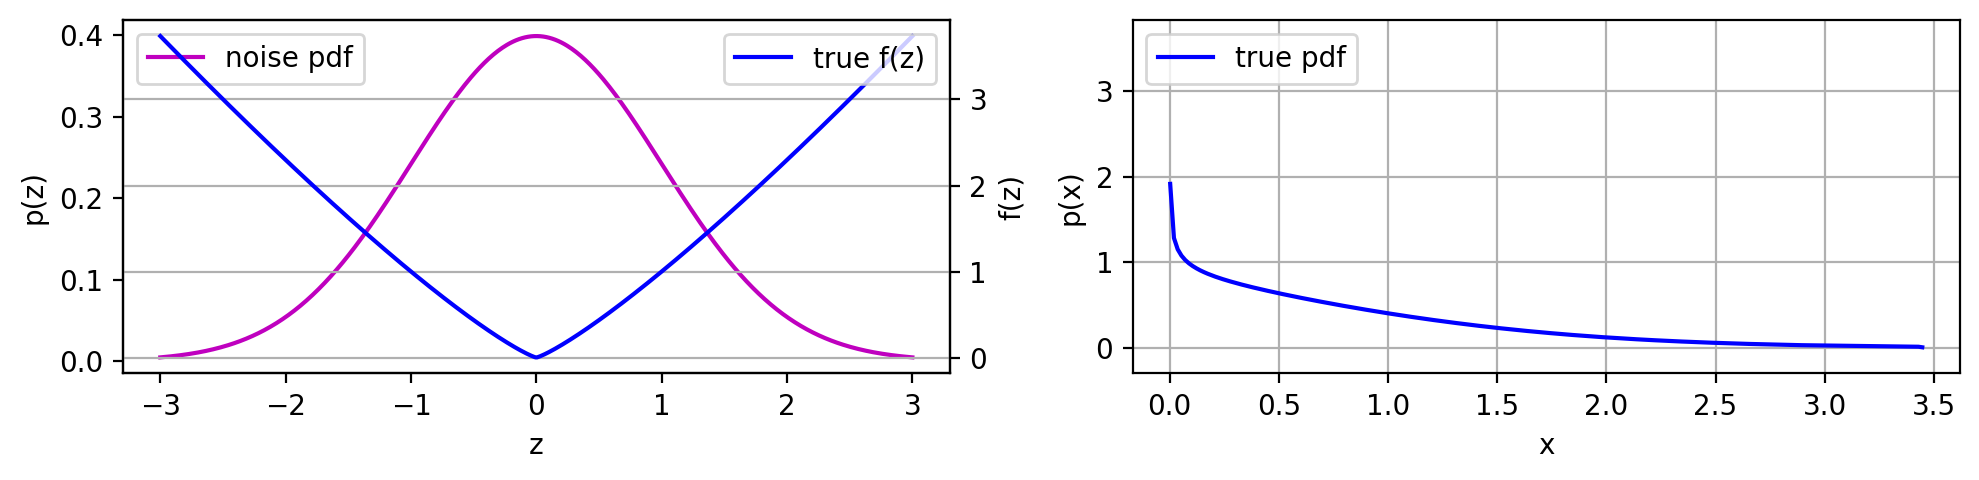

In [77]:
plot_epoch(onlygt=True)

- build the GAN

In [78]:
K.clear_session()
random.seed(5489); tf.random.set_seed(5489)
noise = Input(shape=[1])
generator = gen(10, activation='relu')
g = generator(noise)
discriminator = disc(10, activation='relu')
d = discriminator(g)
make_trainable(discriminator, False)
GAN = Model(noise, d)
GAN.compile(loss="binary_crossentropy", optimizer="sgd", metrics=['accuracy'])

- train for 3000 epochs

In [79]:
epochs = train_for_n(nb_epoch=3000, lr=0.01, plt_frq=500)

2023-01-25 20:30:24.777467: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-01-25 20:30:24.777488: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2023-01-25 20:30:24.782135: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2023-01-25 20:30:24.789004: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2023-01-25 20:30:24.823720: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2023-01-25 20:30:24.84

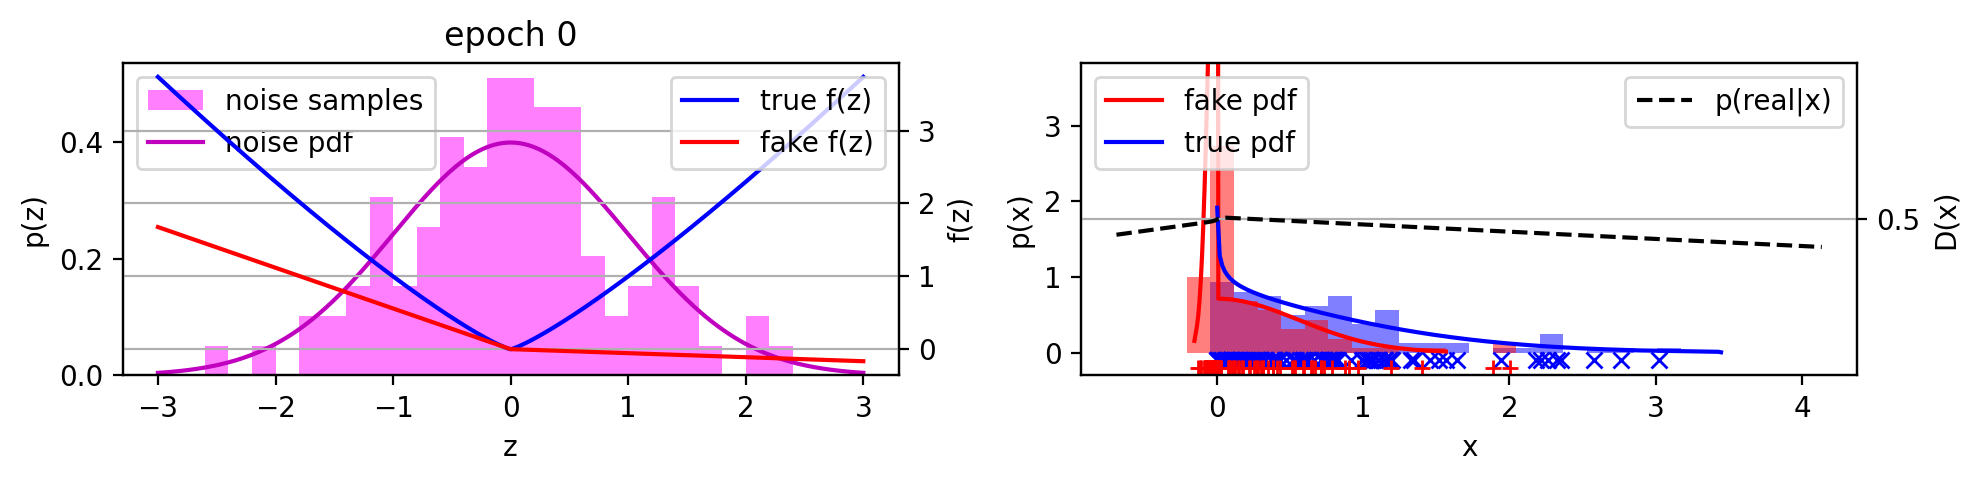

In [80]:
epochs['figs'][0]

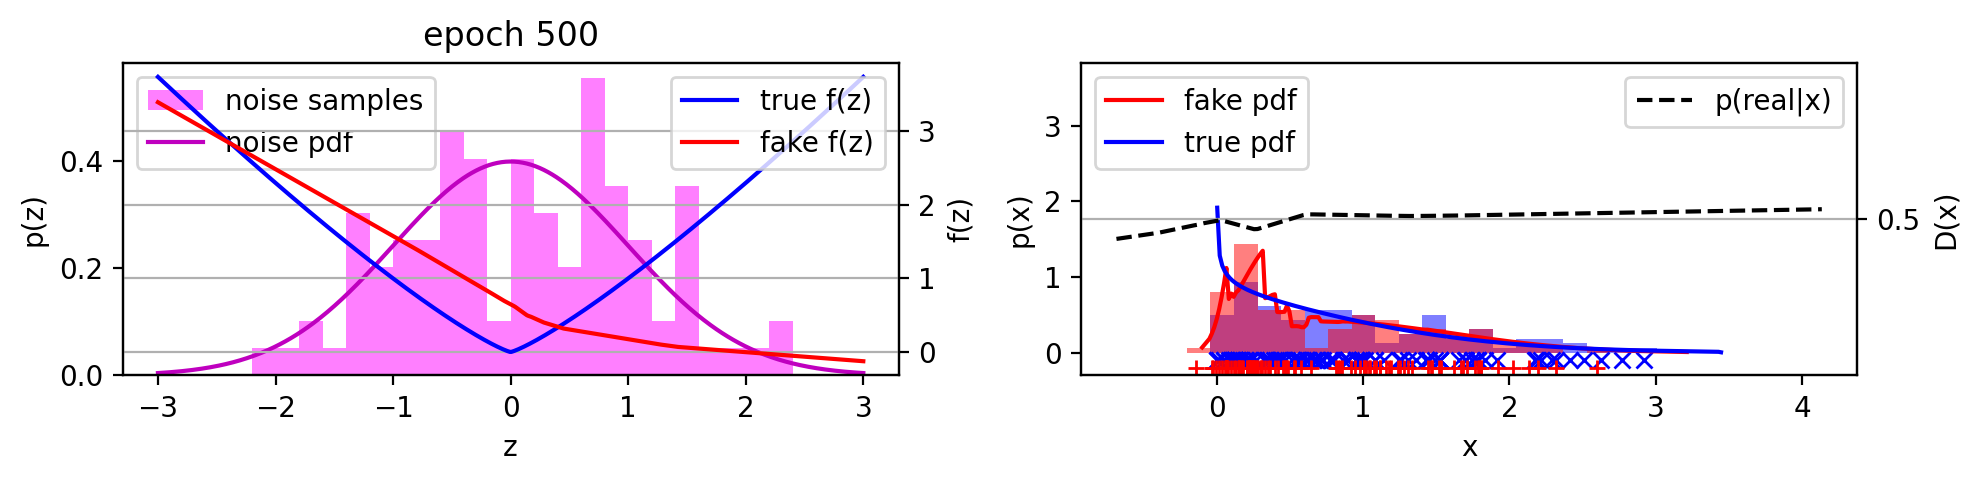

In [81]:
epochs['figs'][1]

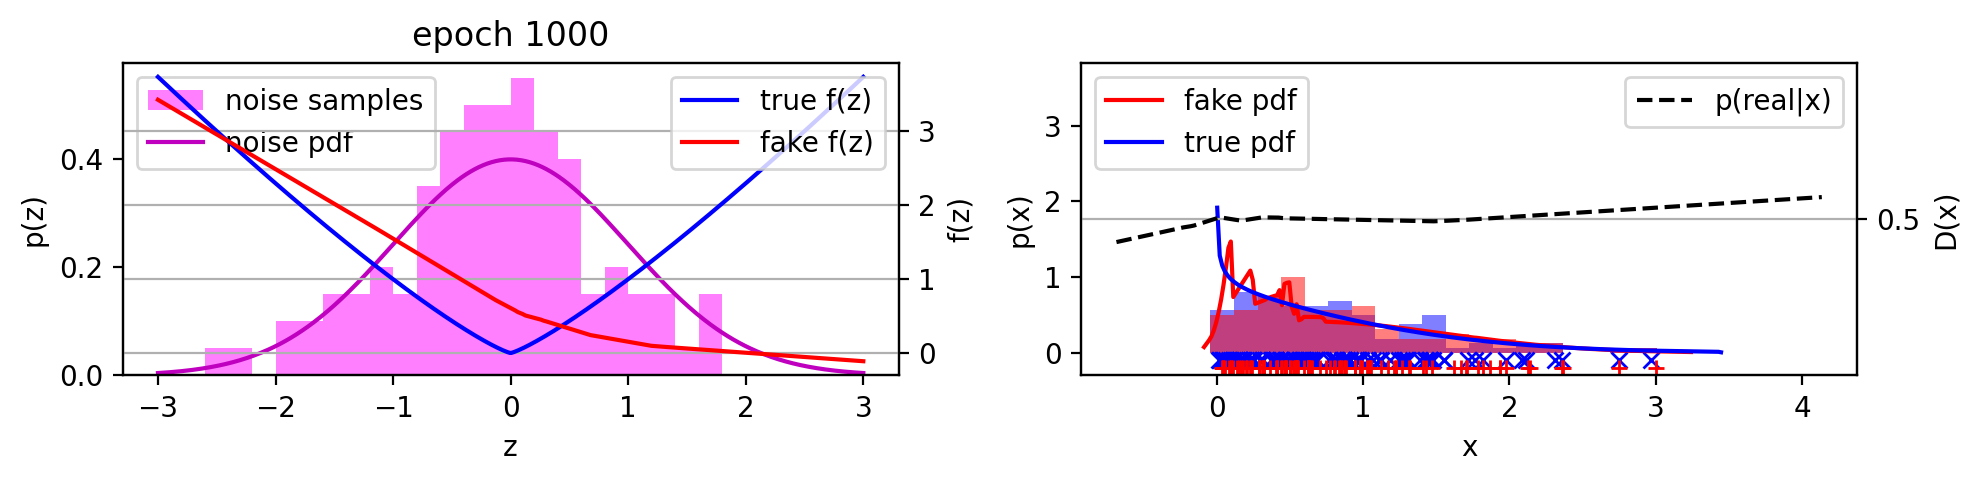

In [82]:
epochs['figs'][2]

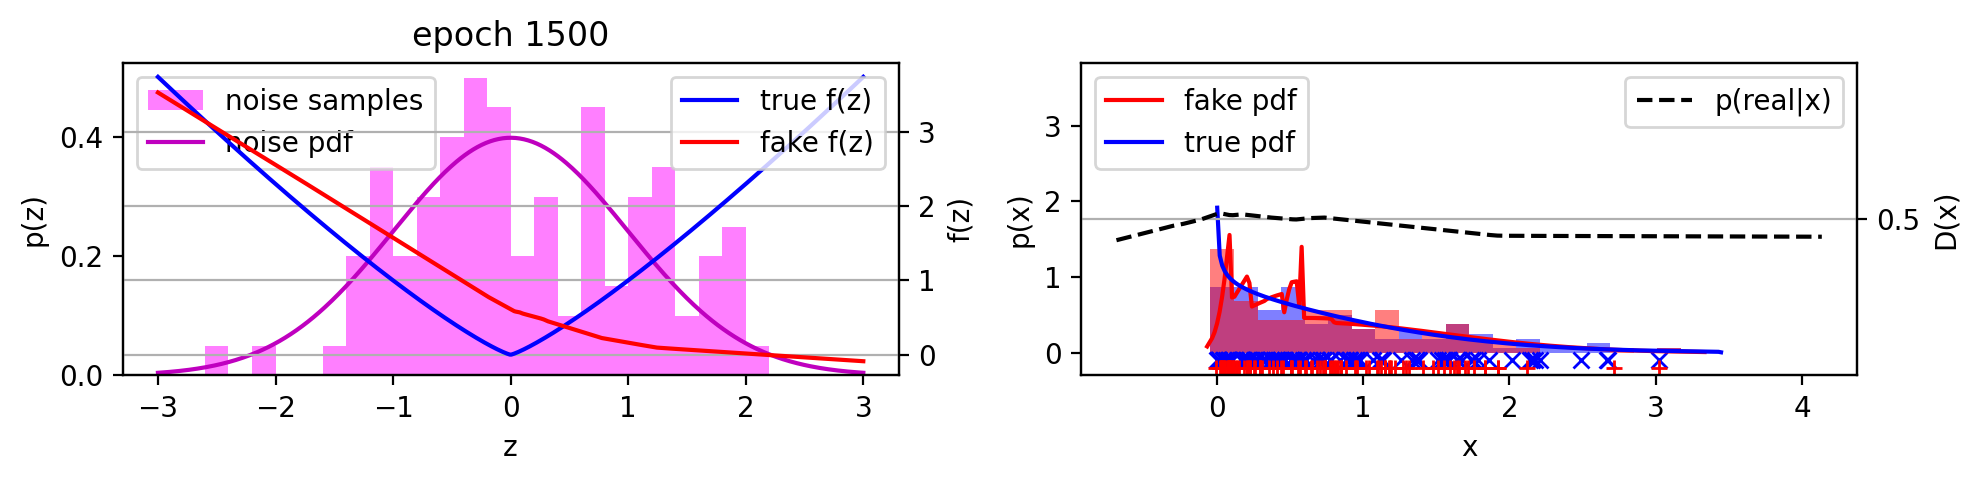

In [83]:
epochs['figs'][3]

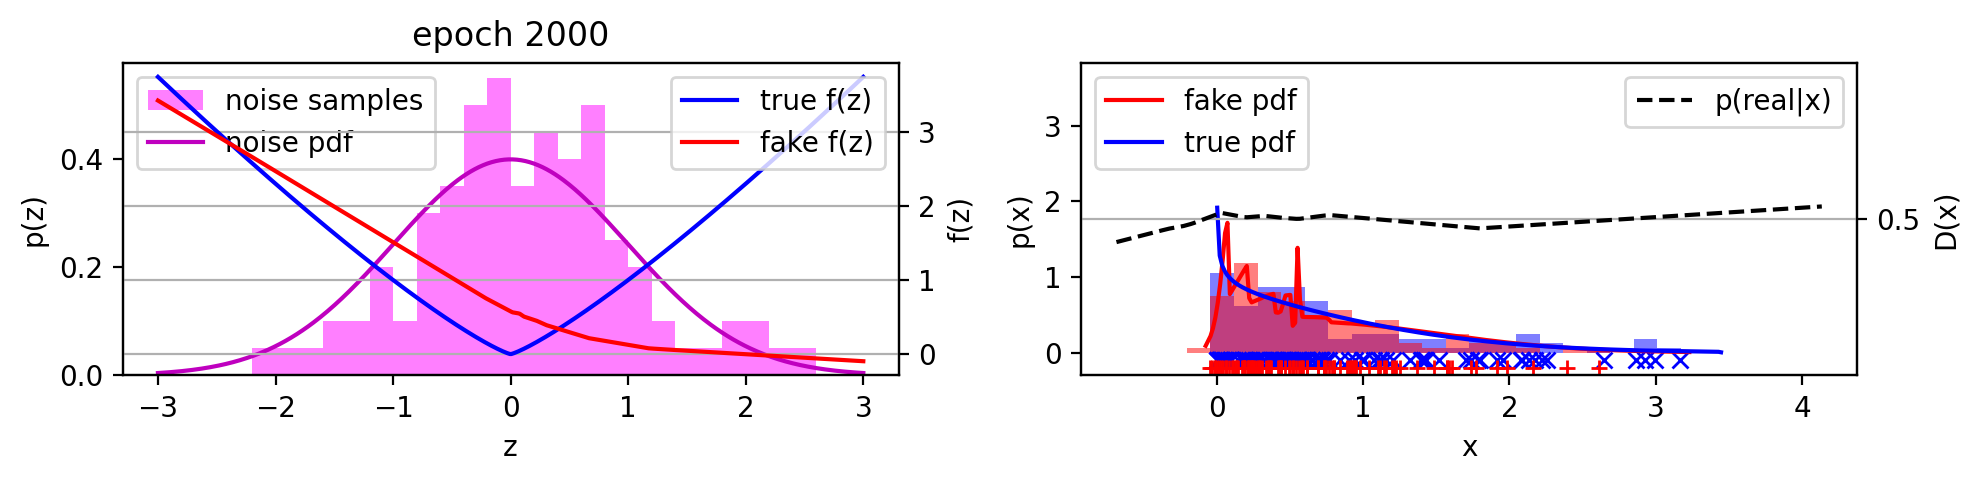

In [84]:
epochs['figs'][4]

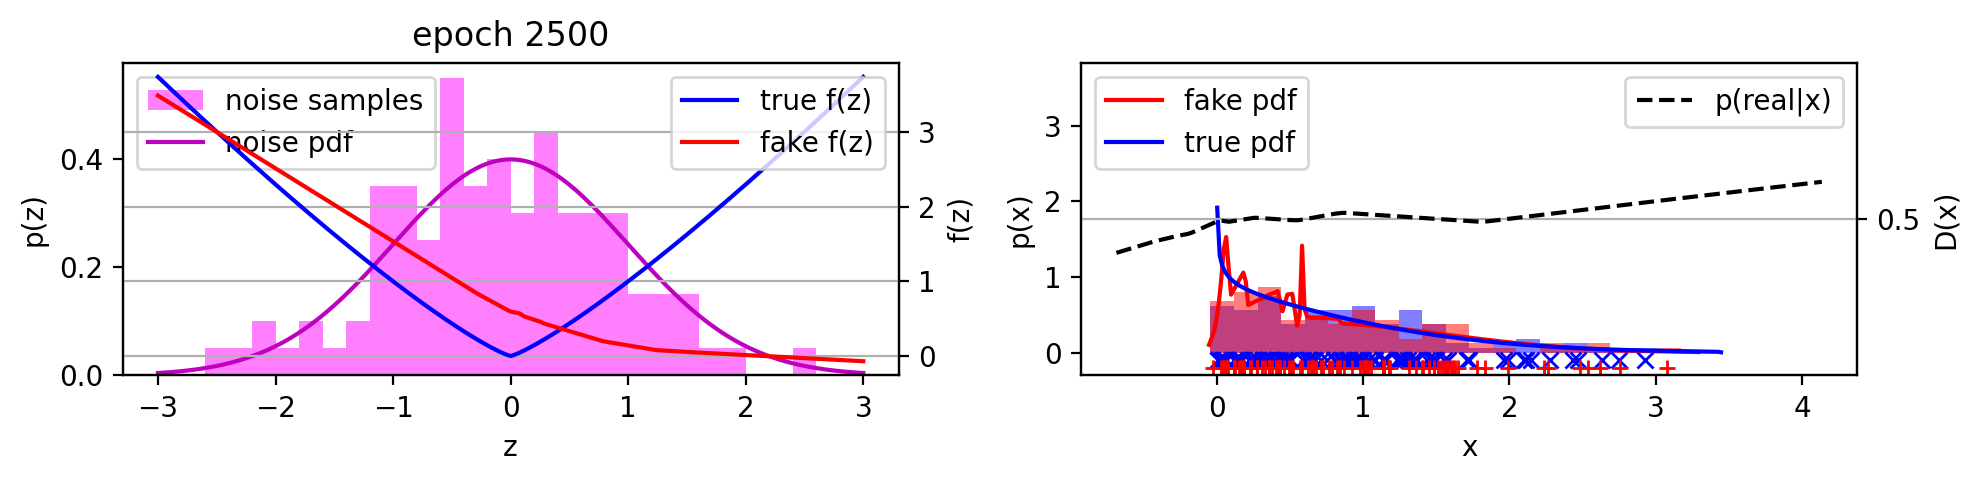

In [85]:
epochs['figs'][5]

  - converges to an equivalent transformation to the real one.

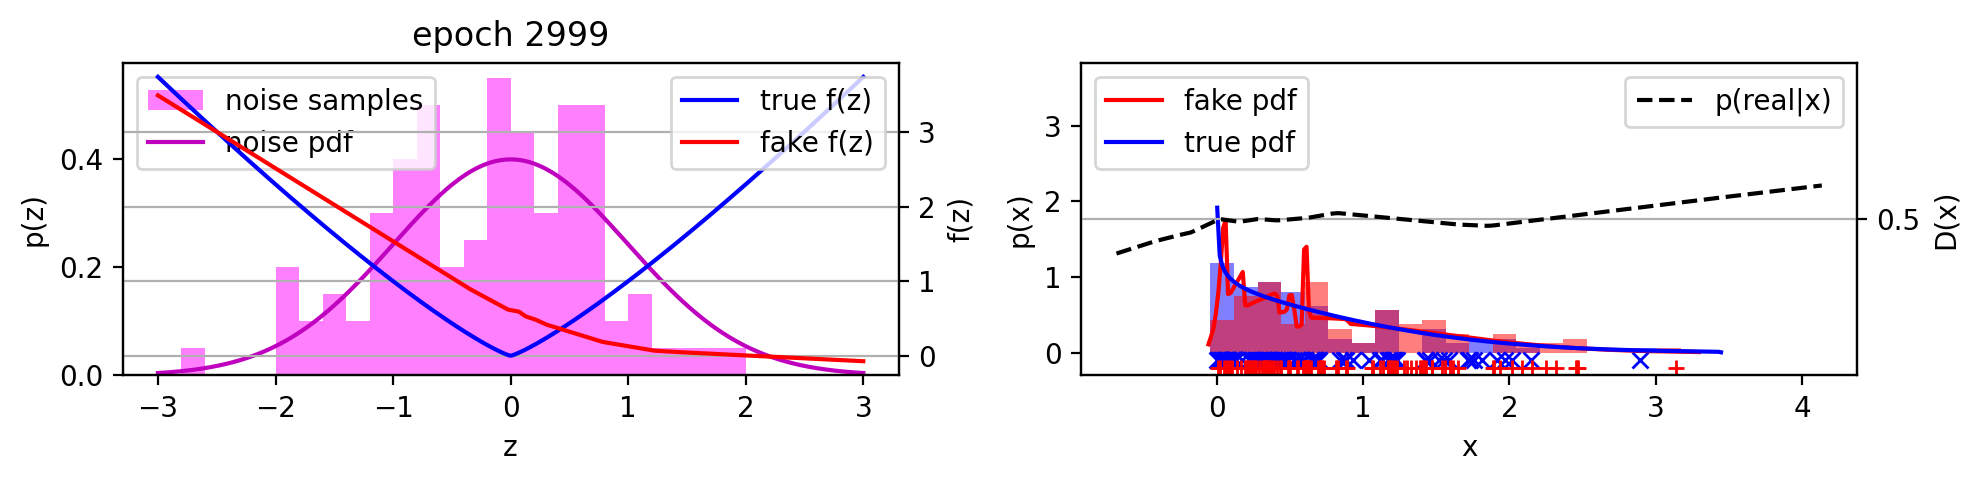

In [86]:
epochs['figs'][6]

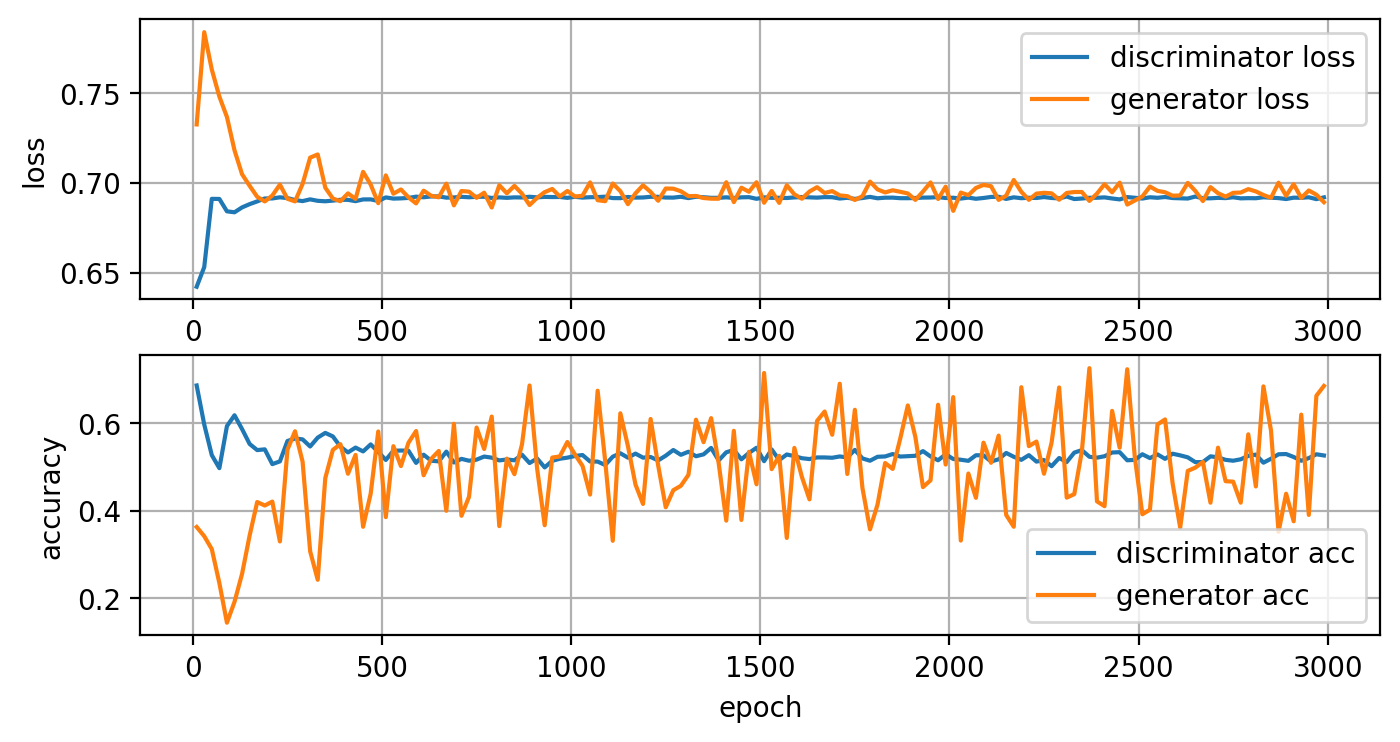

In [87]:
plot_epochs(epochs)

# Mode collapse problem
- GANs also work to learn multi-modal distributions

In [88]:
# two modes
sigmoid = lambda x,a: 1/(1+exp(-a*x))
xform = lambda x: (0.5*x-2)*sigmoid(-x,10) + (x+2)*sigmoid(x,10)
sample_range = get_bounds(xform)

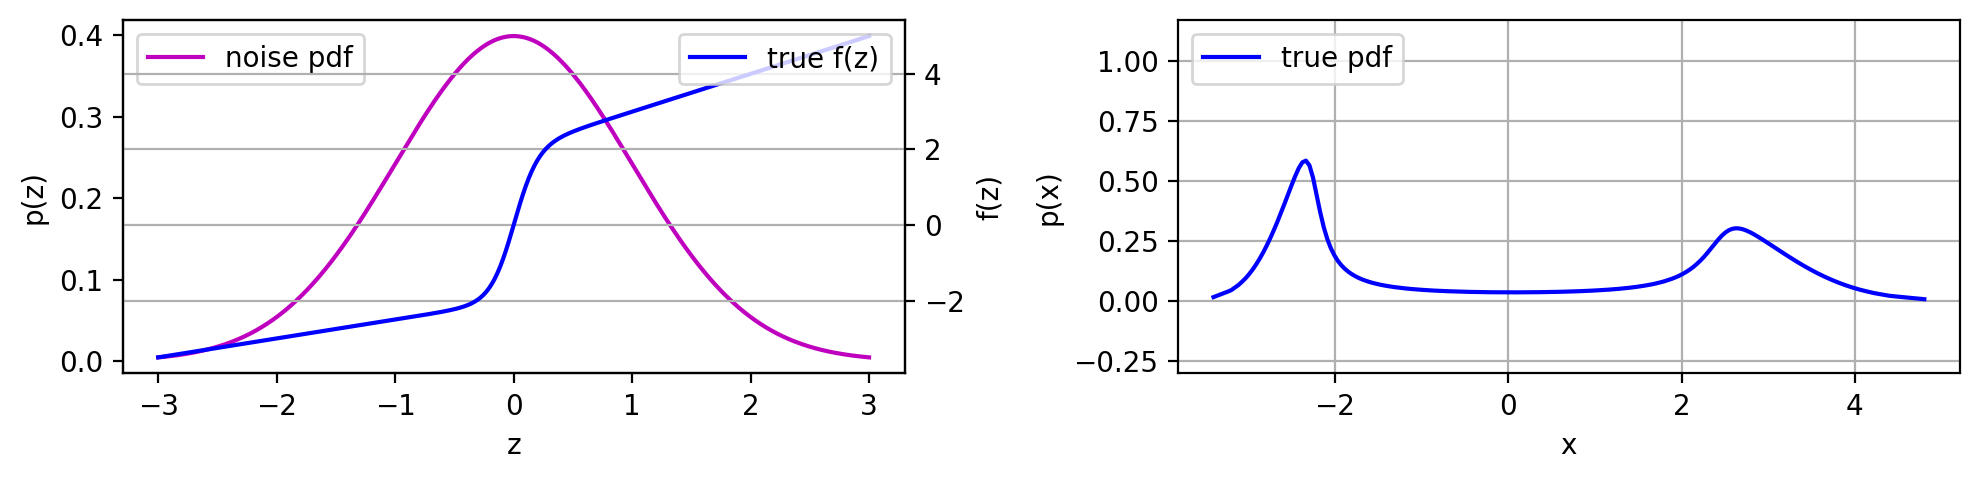

In [89]:
plot_epoch(onlygt=True)

- build GAN

In [90]:
K.clear_session()
random.seed(5489); tf.random.set_seed(5411)

noise = Input(shape=[1])
generator = gen(50, activation='relu')
g = generator(noise)
discriminator = disc(50, activation='relu')
d = discriminator(g)
make_trainable(discriminator, False)
GAN = Model(noise, d)
GAN.compile(loss="binary_crossentropy", optimizer="sgd", metrics=['accuracy'])

- train 3000 epochs

In [91]:
epochs = train_for_n(nb_epoch=3000, lr=0.01, plt_frq=500)

2023-01-25 20:36:01.060915: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-01-25 20:36:01.060939: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2023-01-25 20:36:01.065167: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2023-01-25 20:36:01.071950: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2023-01-25 20:36:01.105224: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2023-01-25 20:36:01.13

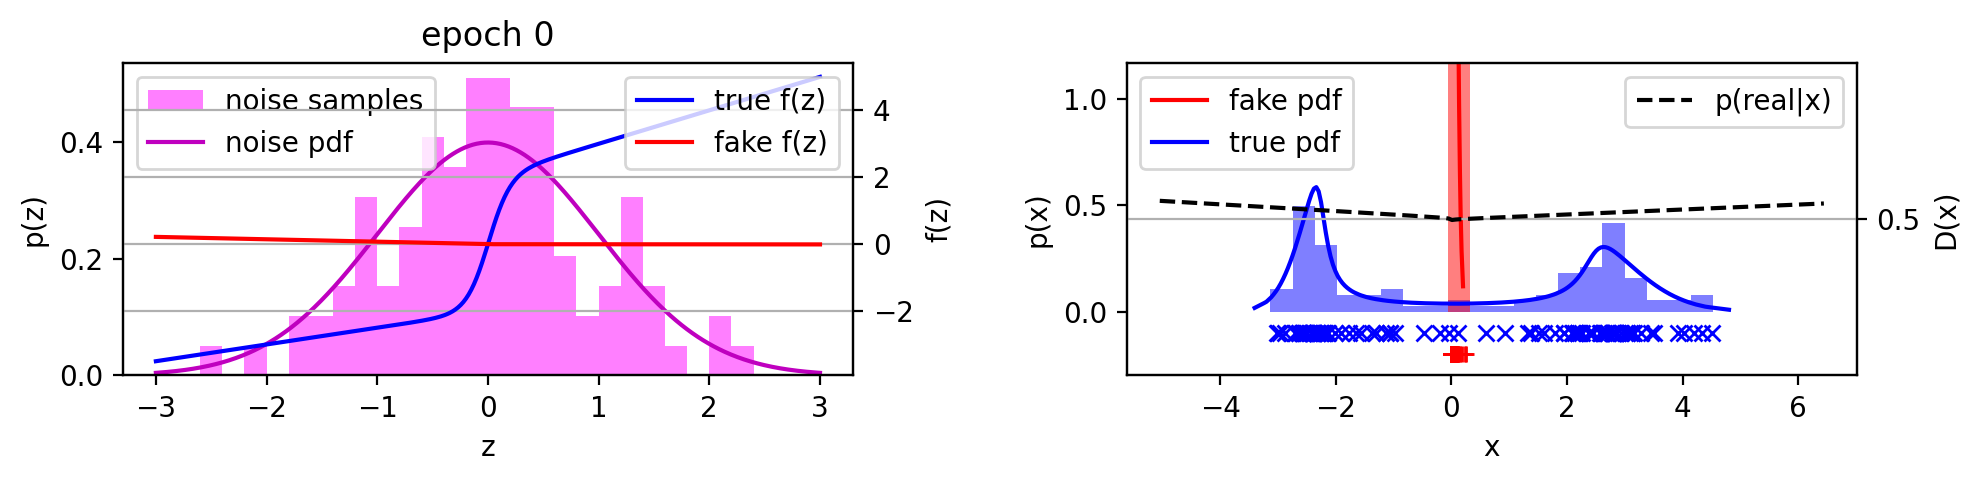

In [92]:
epochs['figs'][0]

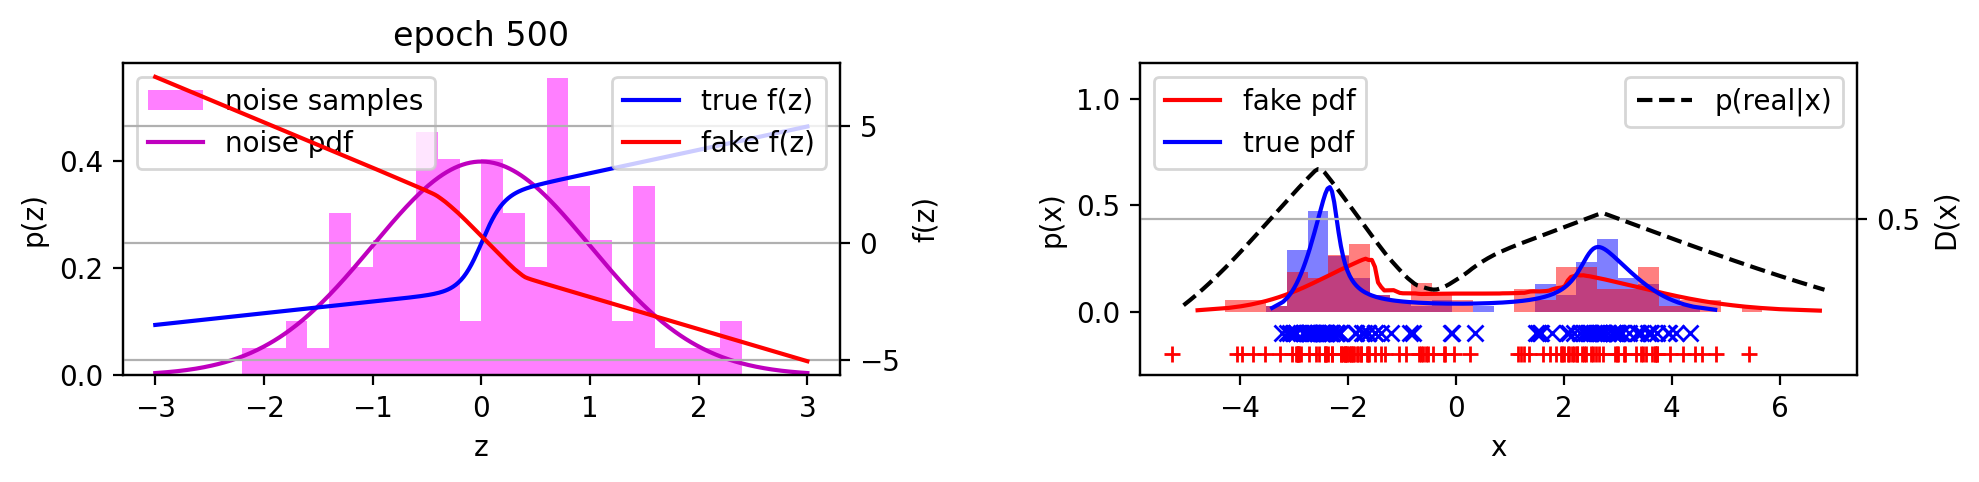

In [93]:
epochs['figs'][1]

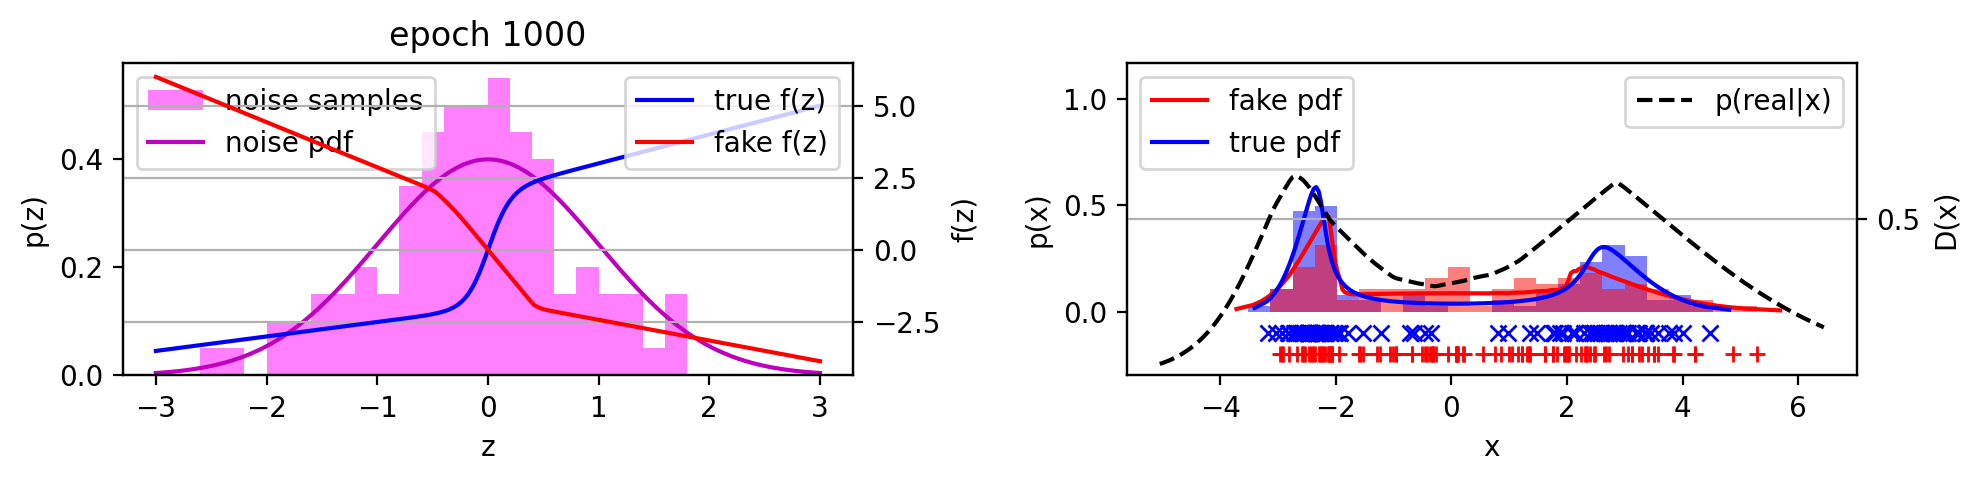

In [94]:
epochs['figs'][2]

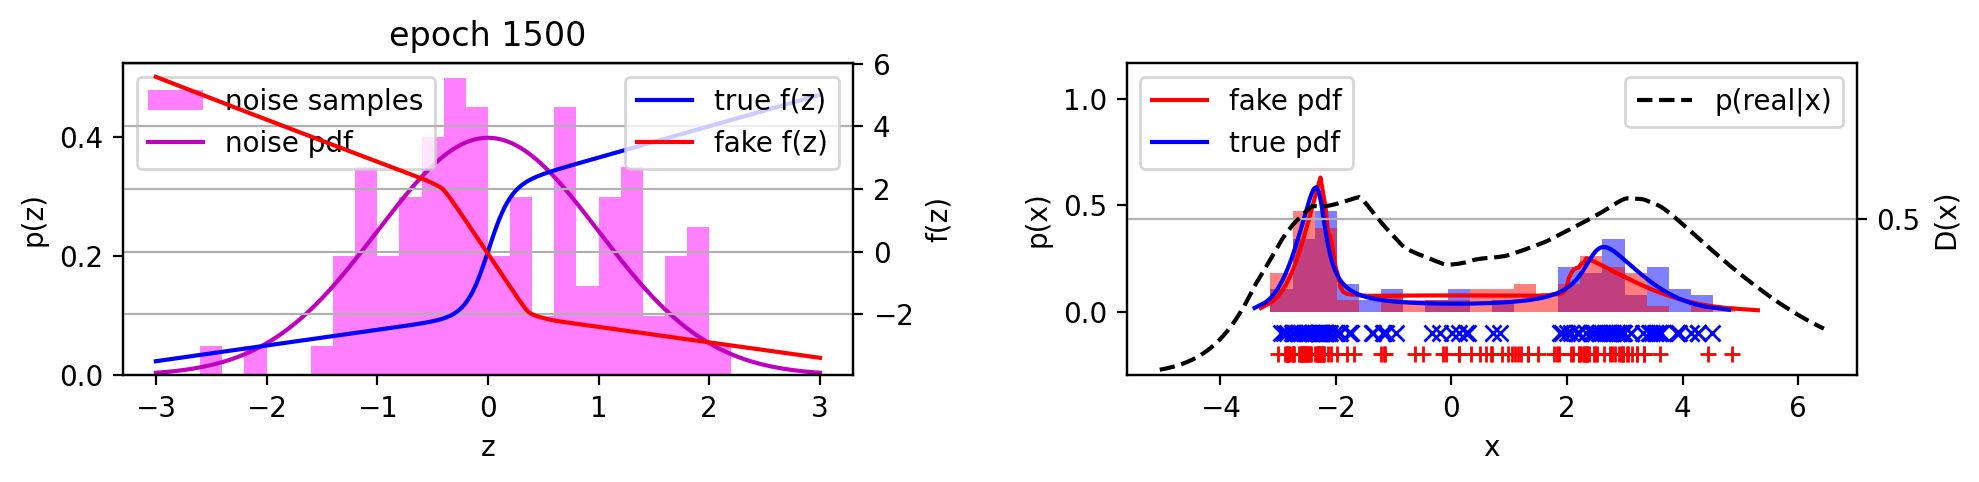

In [95]:
epochs['figs'][3]

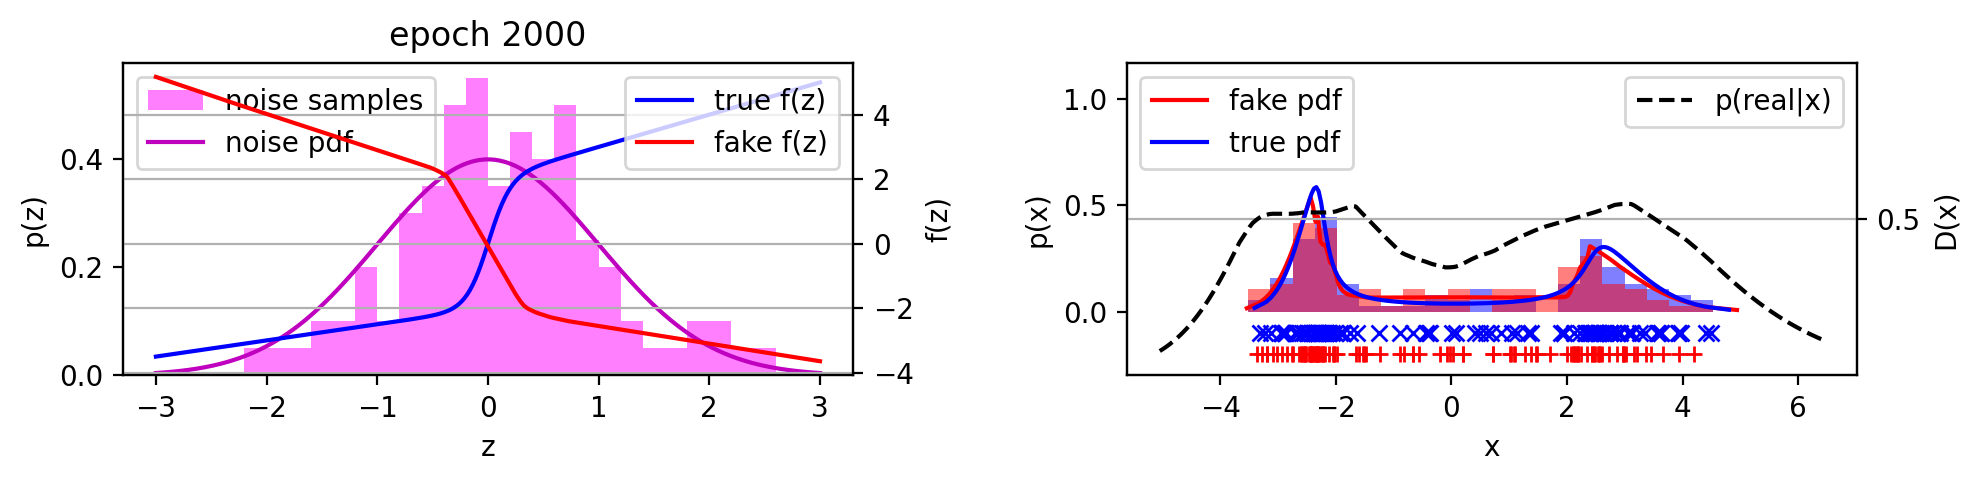

In [96]:
epochs['figs'][4]

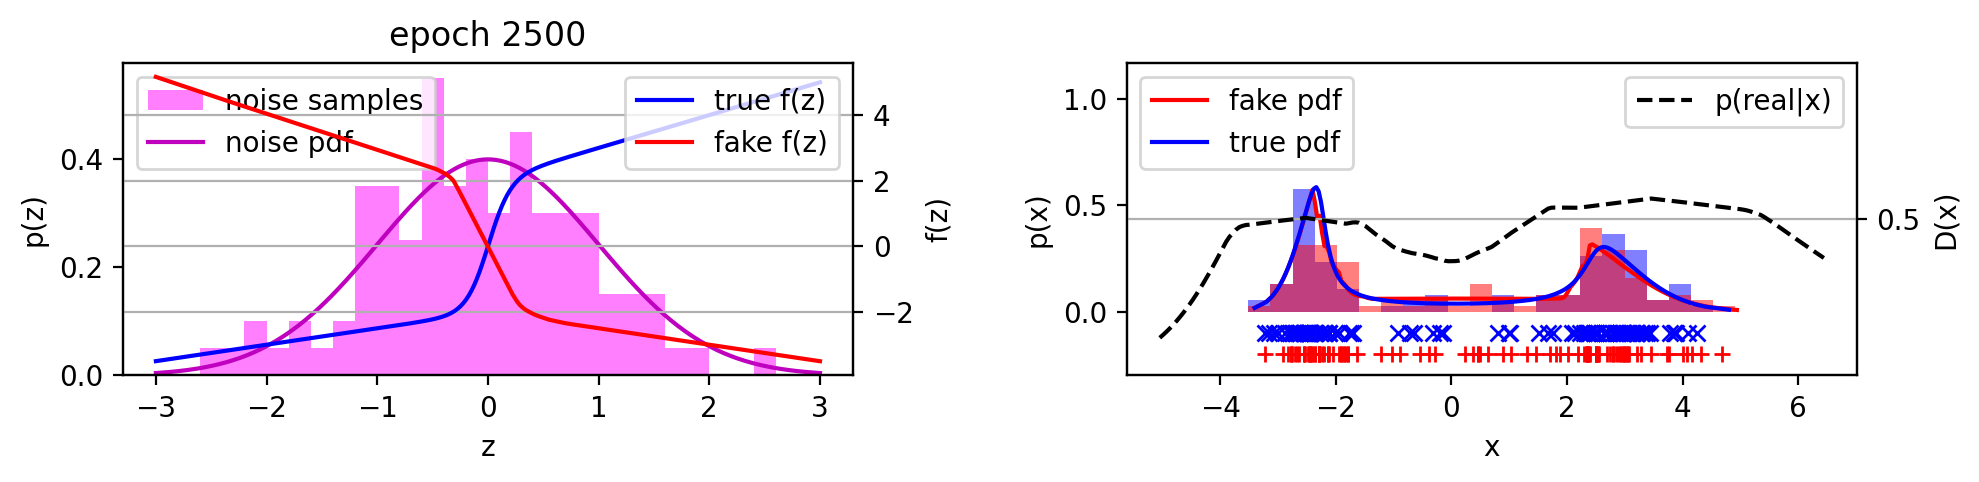

In [97]:
epochs['figs'][5]

  - represents both modes of the target density
  - converges to true transformation

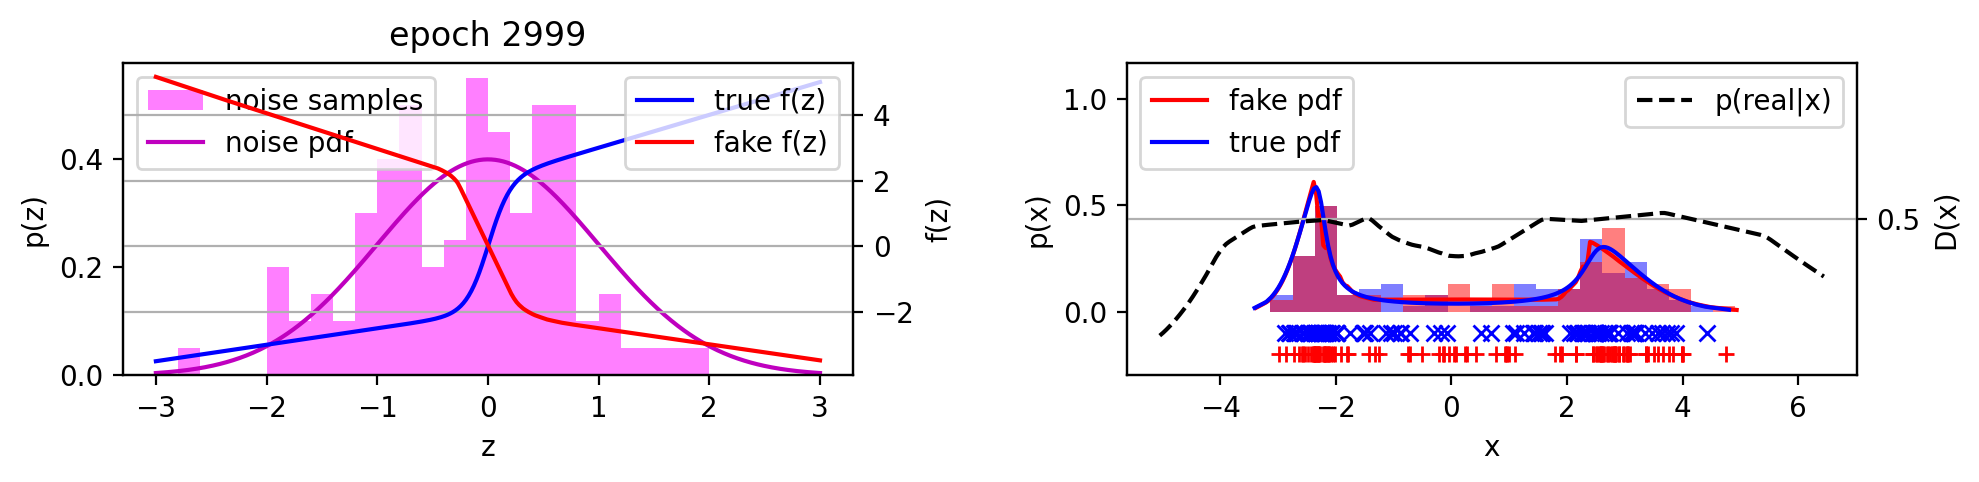

In [98]:
epochs['figs'][6]

- try another example
  - modes are farther apart

In [99]:
# two modes
sigmoid = lambda x,a: 1/(1+exp(-a*x))
xform = lambda x: (x)*sigmoid(-x,30) + (x+15)*sigmoid(x,30)
sample_range = get_bounds(xform)

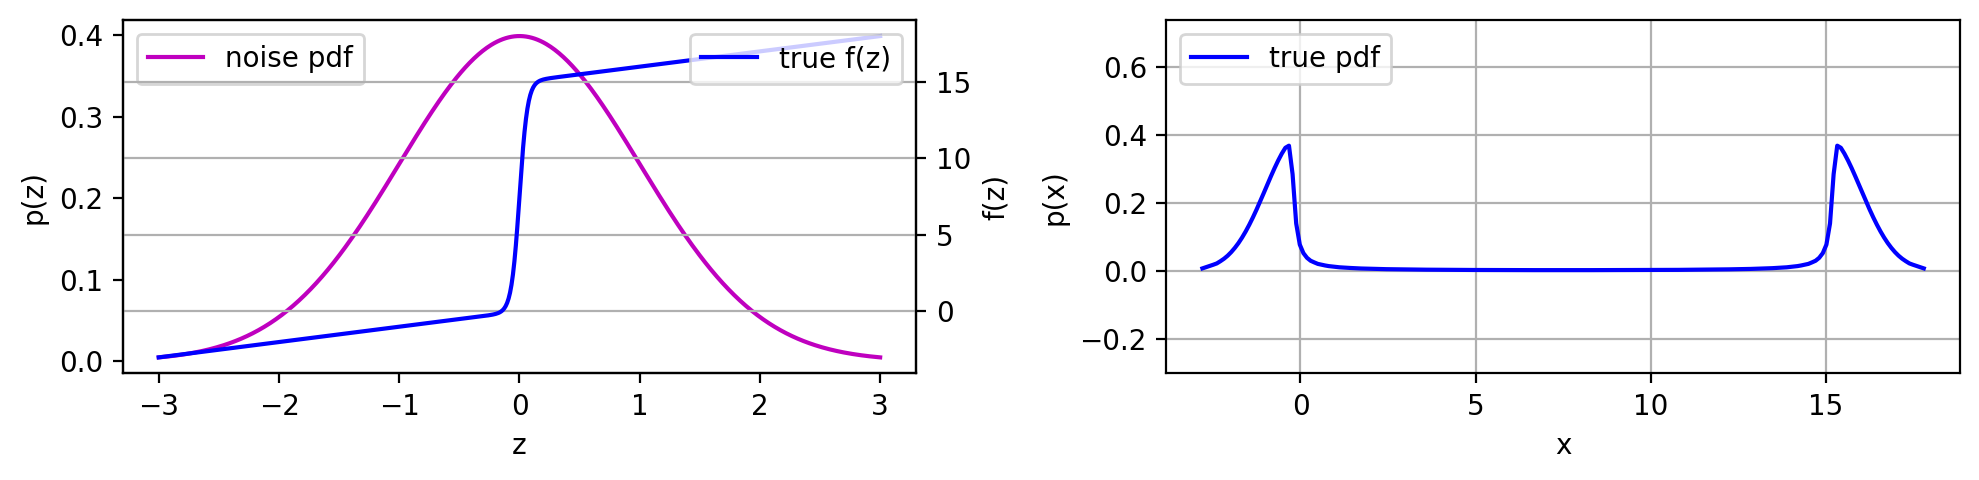

In [100]:
plot_epoch(onlygt=True)

In [101]:
K.clear_session()
random.seed(54); tf.random.set_seed(54)

noise = Input(shape=[1])
generator = gen(5, activation='relu')
g = generator(noise)
discriminator = disc(100, activation='relu')
d = discriminator(g)
make_trainable(discriminator, False)
GAN = Model(noise, d)
GAN.compile(loss="binary_crossentropy", optimizer="sgd", metrics=['accuracy'])
GAN.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 1)]               0         
                                                                 
 generator (Functional)      (None, 1)                 46        
                                                                 
 discriminator (Functional)  (None, 1)                 40801     
                                                                 
Total params: 40,847
Trainable params: 46
Non-trainable params: 40,801
_________________________________________________________________


- G collapses to sample from only one of the modes
  - G can always fool D with this one mode

In [102]:
epochs = train_for_n(nb_epoch=5000, lr=0.01, plt_frq=1000)

2023-01-25 20:41:54.277128: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-01-25 20:41:54.277148: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2023-01-25 20:41:54.282016: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2023-01-25 20:41:54.288794: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2023-01-25 20:41:54.322626: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2023-01-25 20:41:54.35

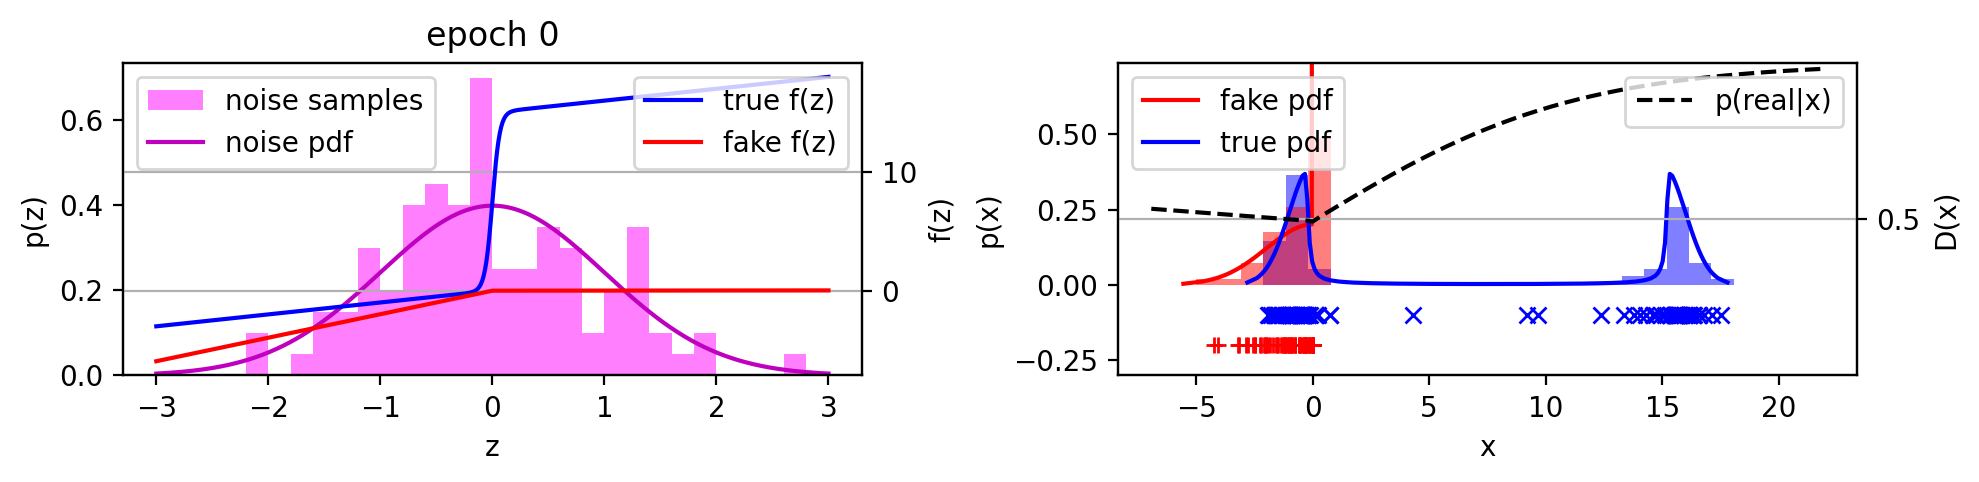

In [103]:
epochs['figs'][0]

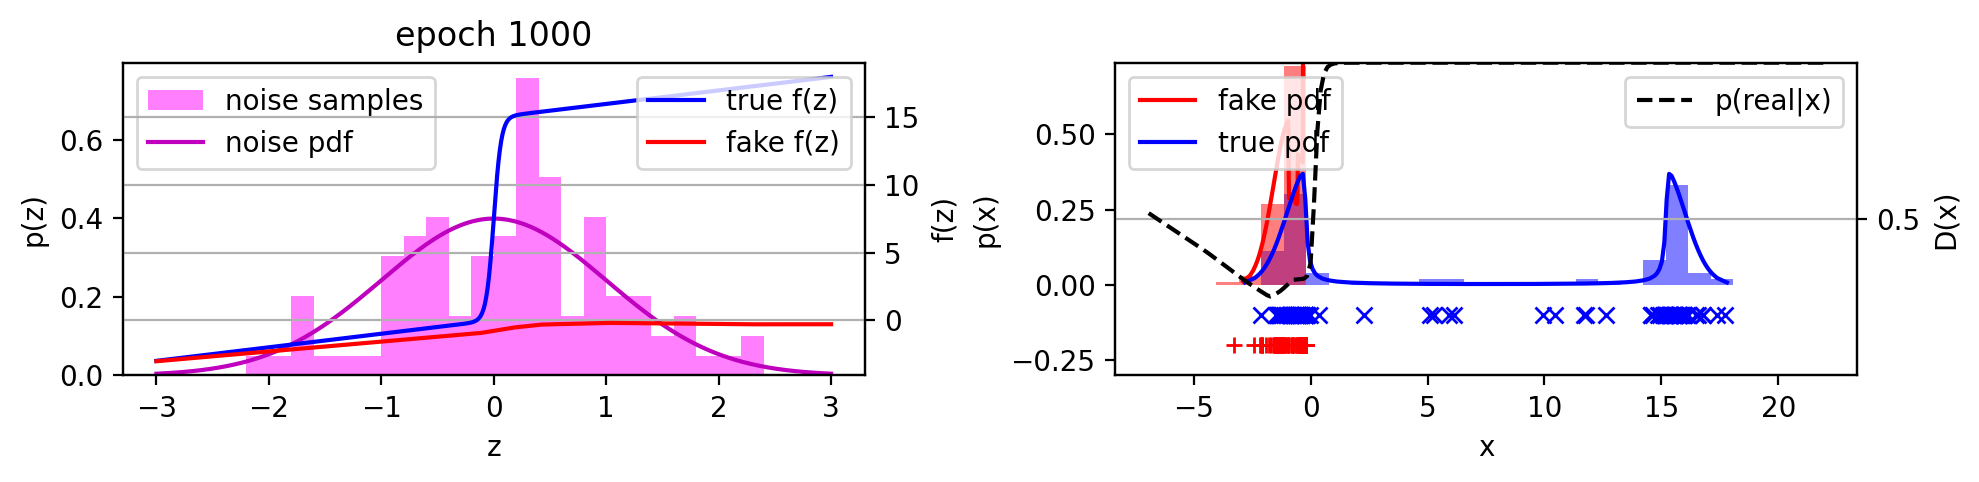

In [104]:
epochs['figs'][1]

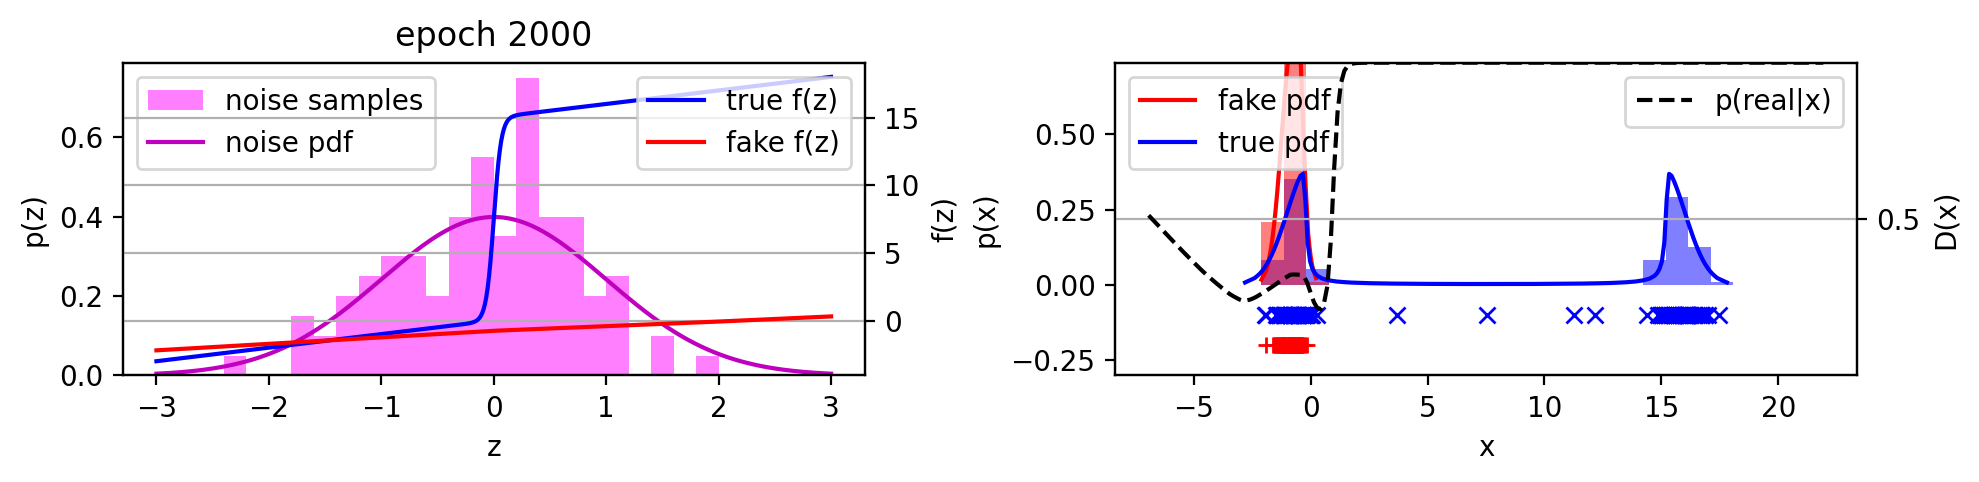

In [105]:
epochs['figs'][2]

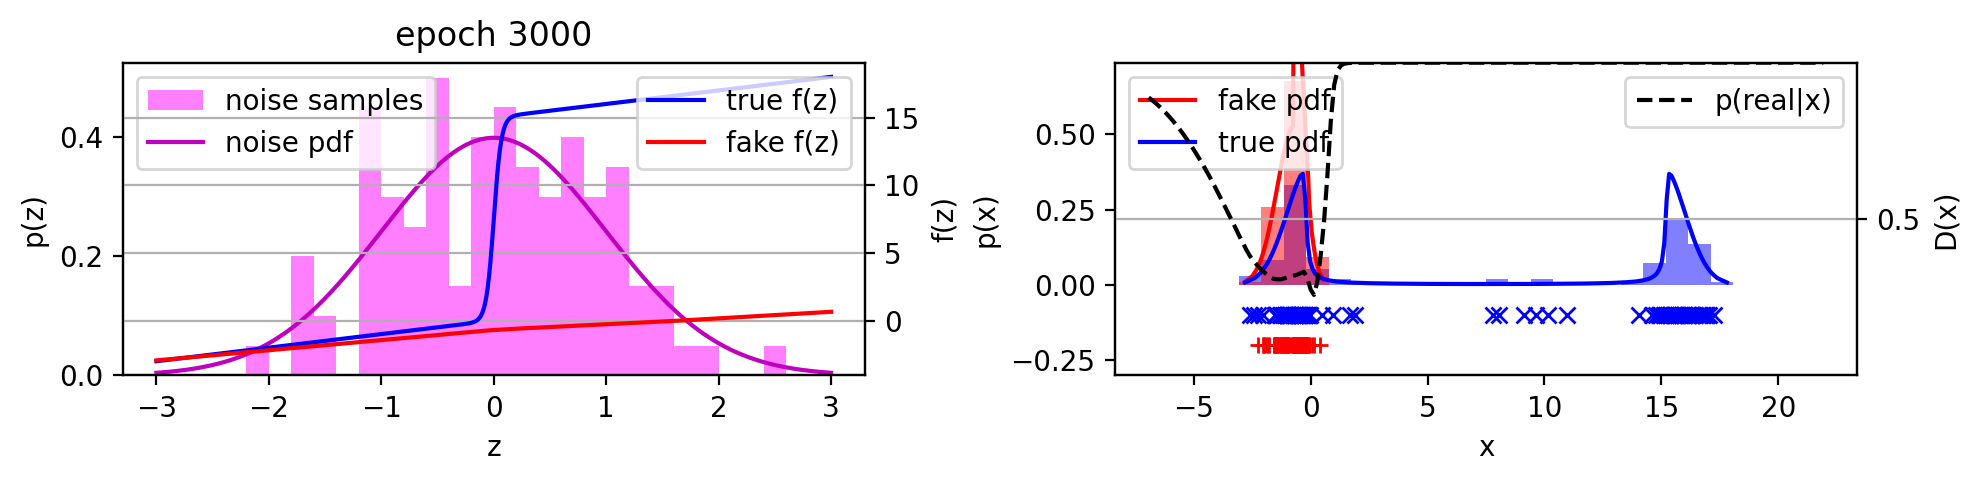

In [106]:
epochs['figs'][3]

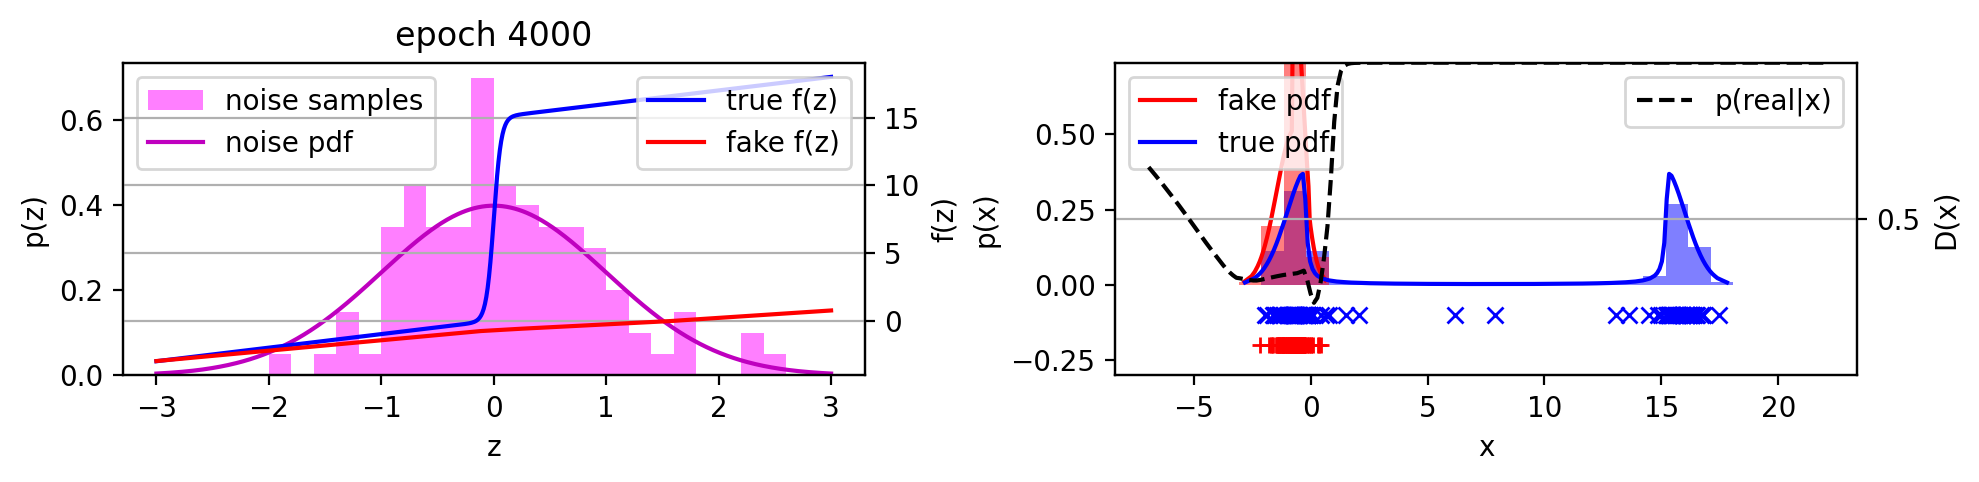

In [107]:
epochs['figs'][4]

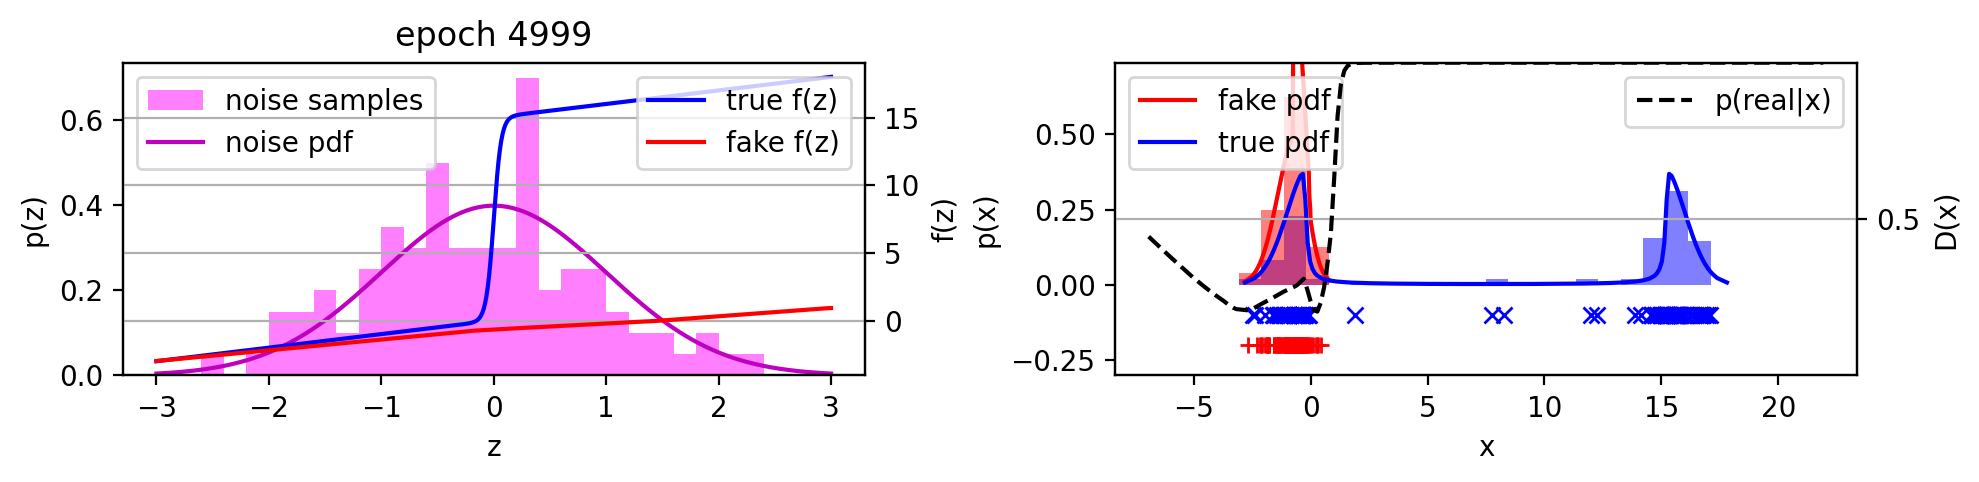

In [108]:
epochs['figs'][5]

- **Mode collapse problem**
  - G samples from one mode.
  - when D catches this, G switches to another mode
  - and so on

# Example from beginning

In [109]:
xform = lambda x: x+3
sample_range = get_bounds(xform)
K.clear_session()
random.seed(54); tf.random.set_seed(5411)

noise = Input(shape=[1])
generator = gen(1, n_layers=0, activation='linear')
g = generator(noise)
discriminator = disc(10, n_layers=1, activation='relu')
d = discriminator(g)
make_trainable(discriminator, False)
GAN = Model(noise, d)
GAN.compile(loss="binary_crossentropy", optimizer="sgd", metrics=['accuracy'])

In [110]:
epochs = train_for_n(nb_epoch=1500, lr=0.01, plt_frq=100, d_inner=50)

2023-01-25 20:51:38.552343: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-01-25 20:51:38.552362: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2023-01-25 20:51:38.556069: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2023-01-25 20:51:38.561091: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2023-01-25 20:51:38.581371: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2023-01-25 20:51:38.59

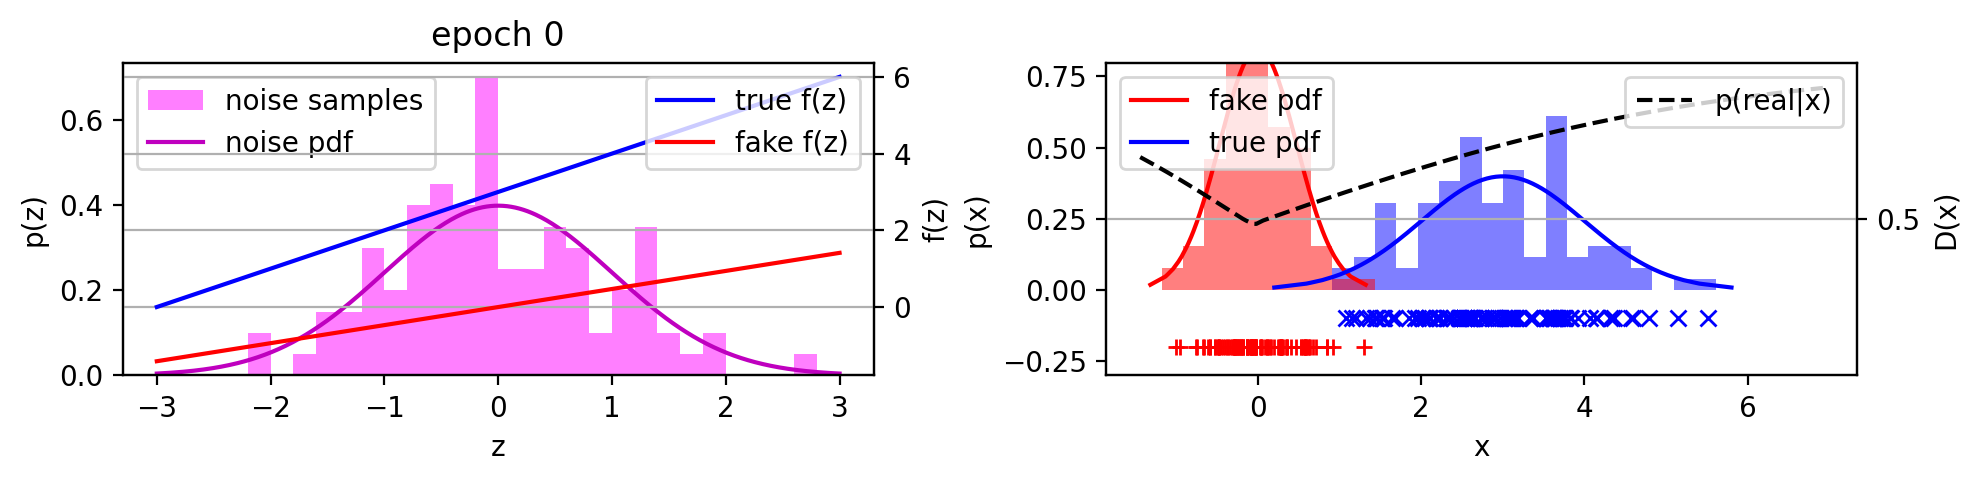

In [111]:
epochs['figs'][0]

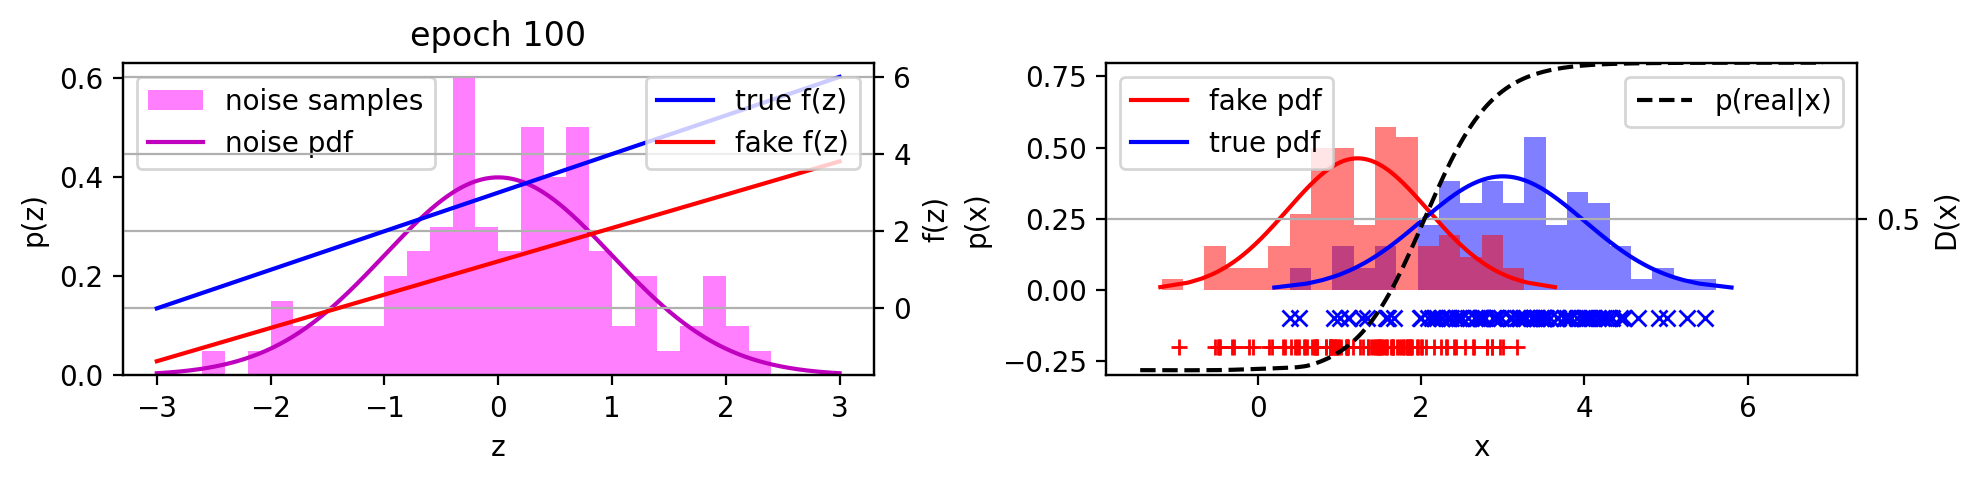

In [112]:
epochs['figs'][1]

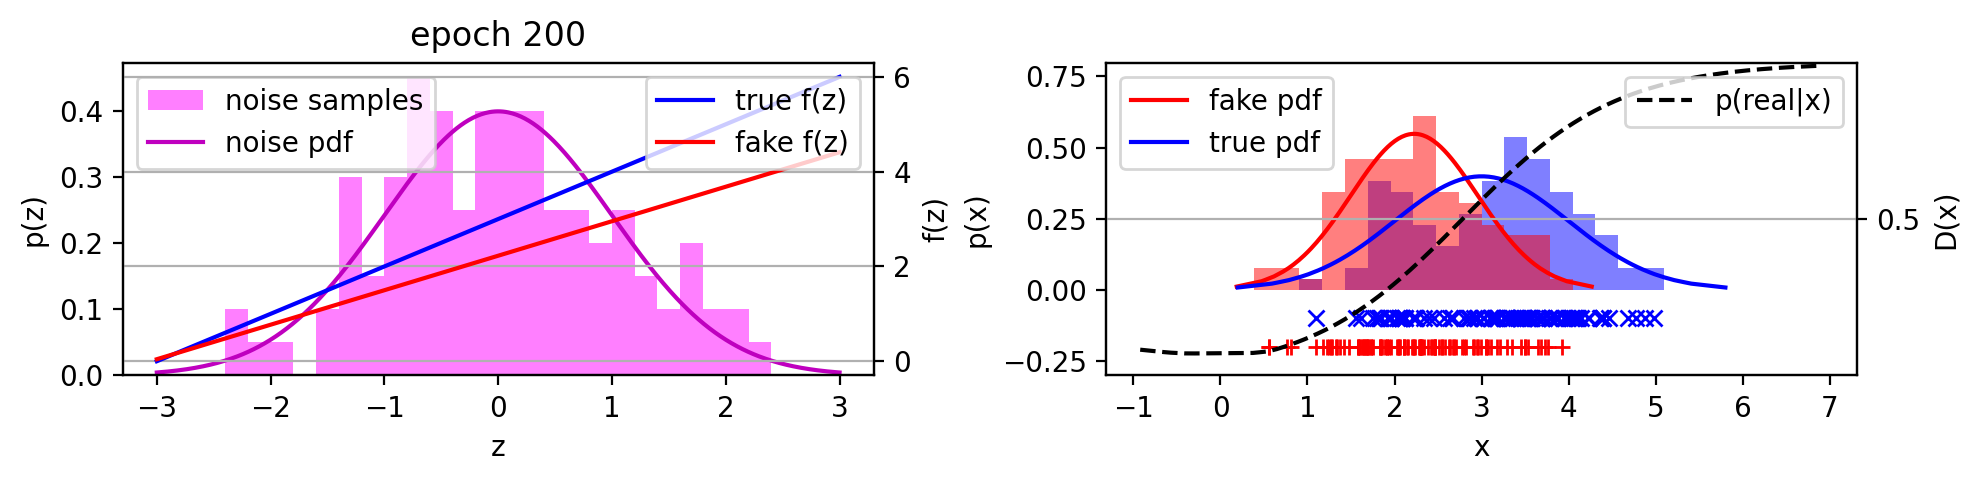

In [113]:
epochs['figs'][2]

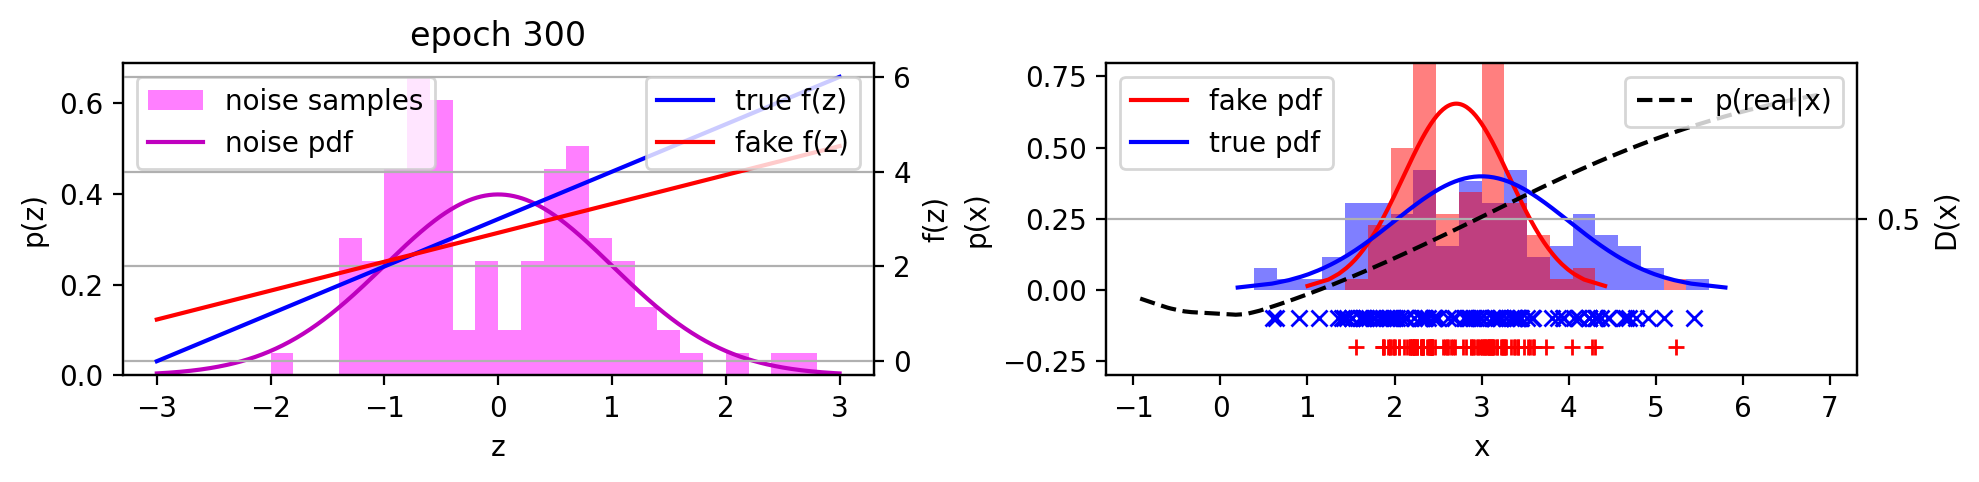

In [114]:
epochs['figs'][3]

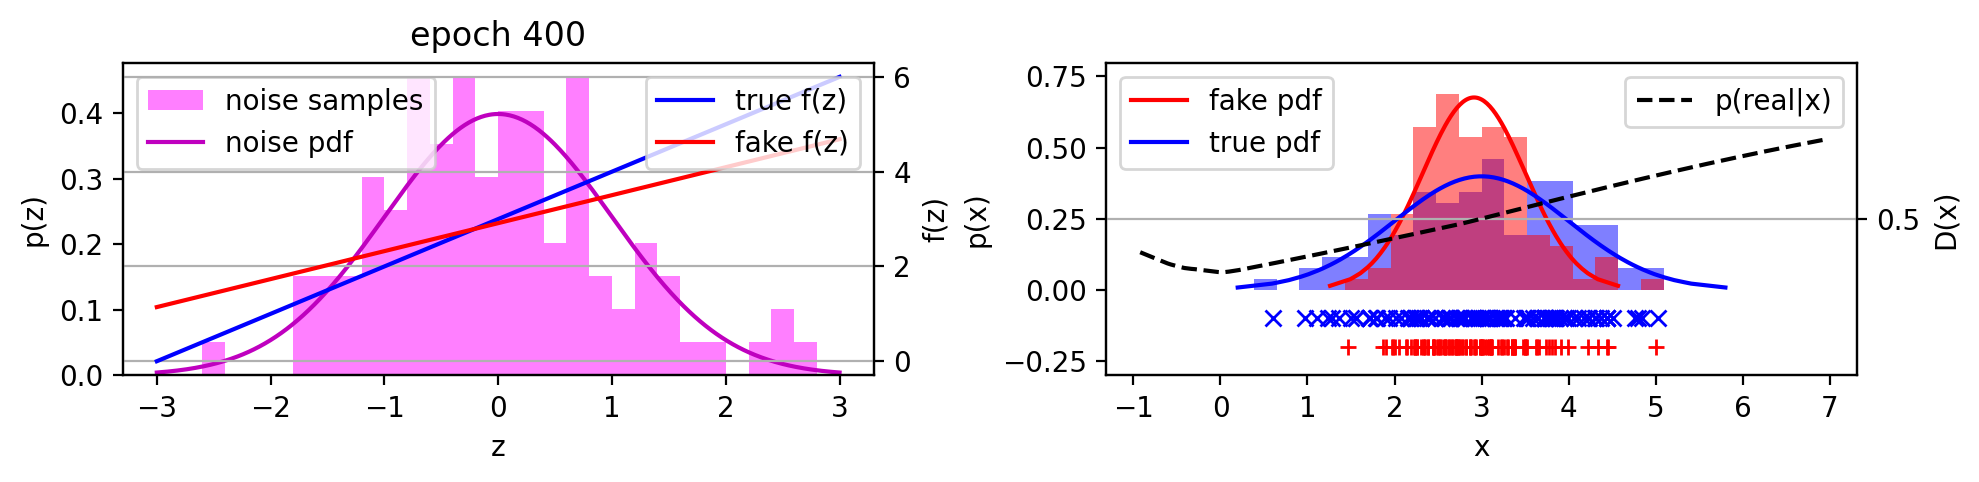

In [115]:
epochs['figs'][4]

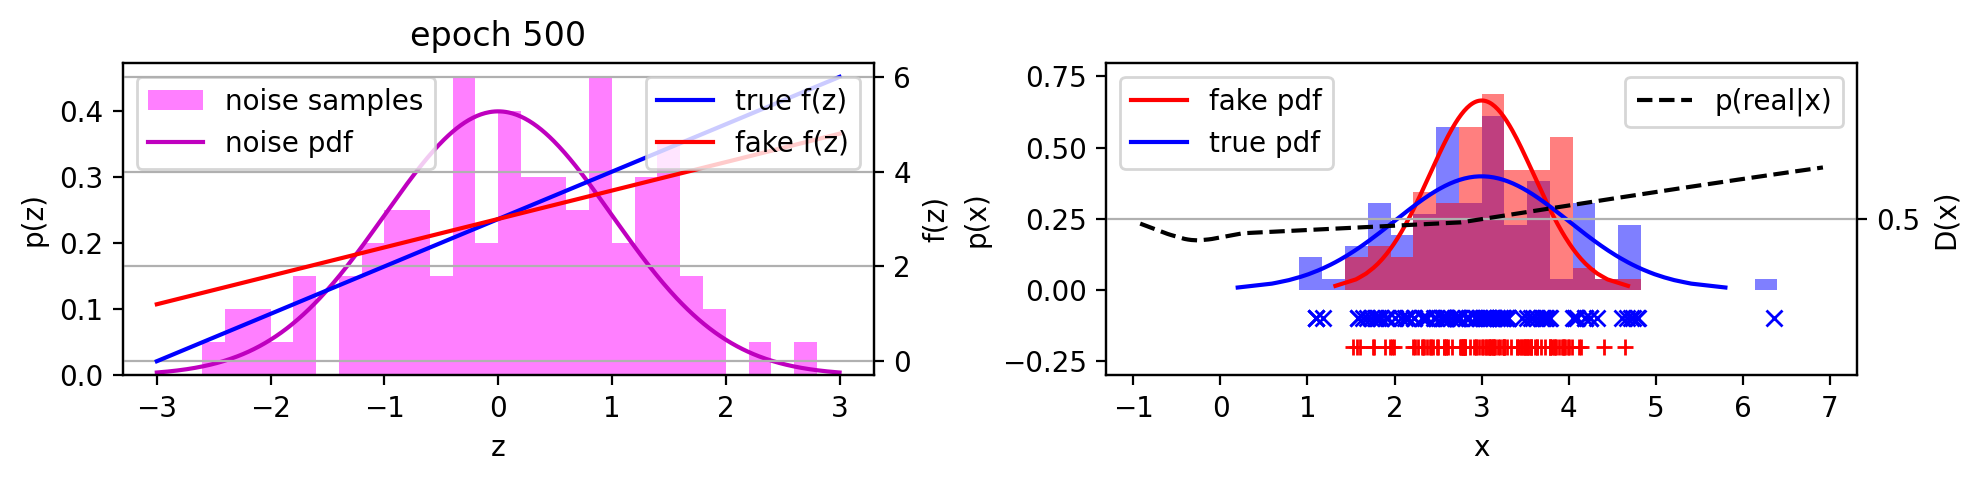

In [116]:
epochs['figs'][5]

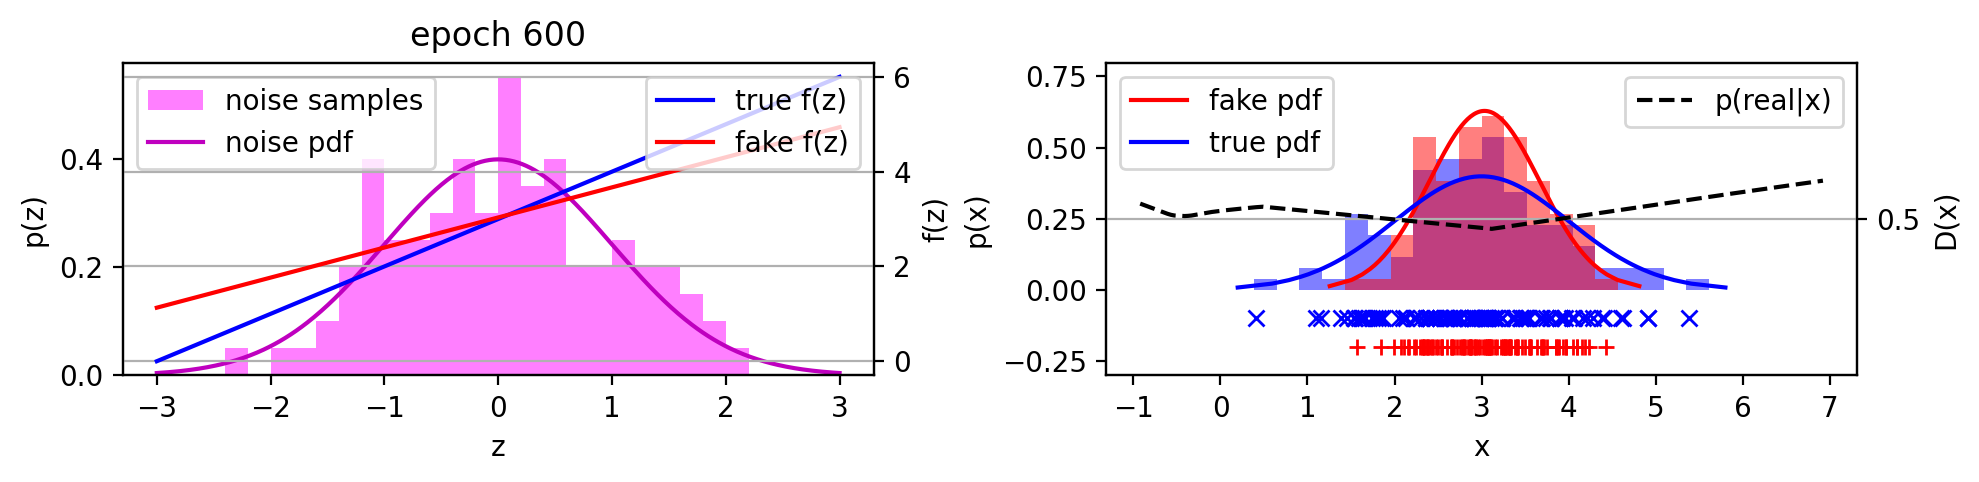

In [117]:
epochs['figs'][6]

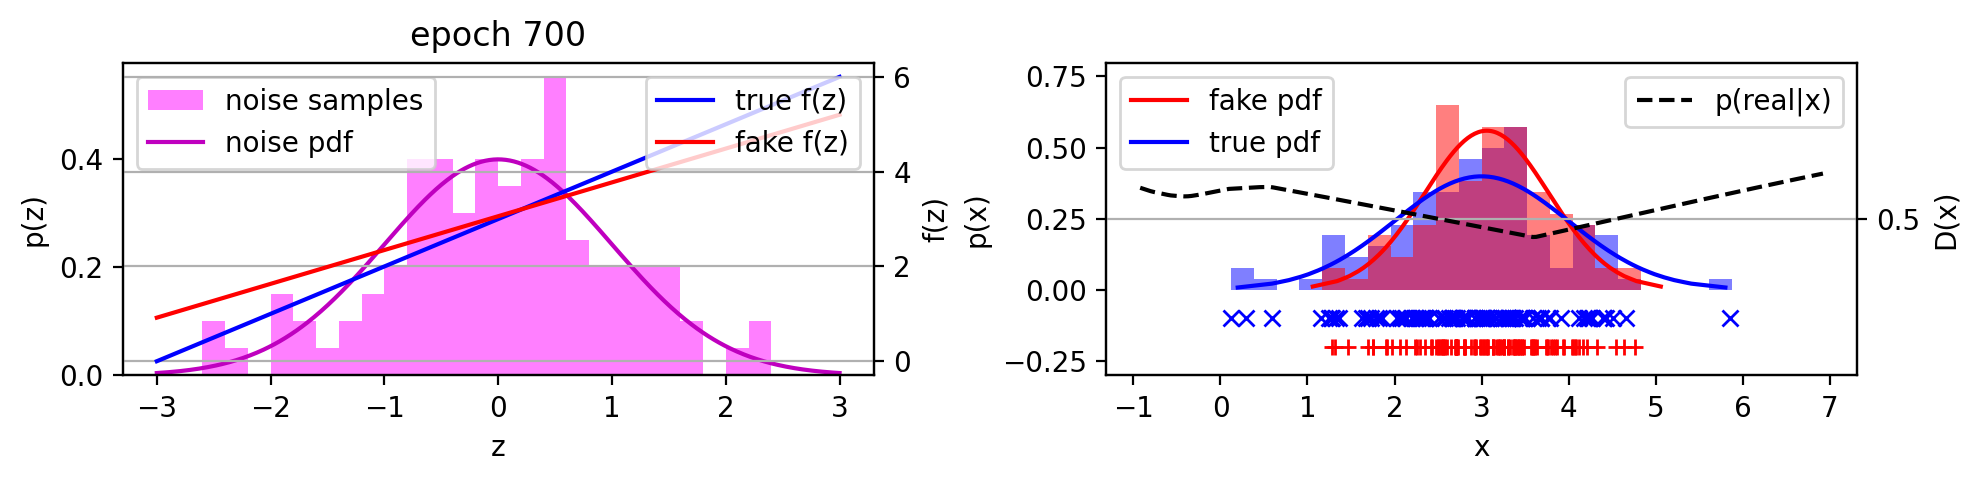

In [118]:
epochs['figs'][7]

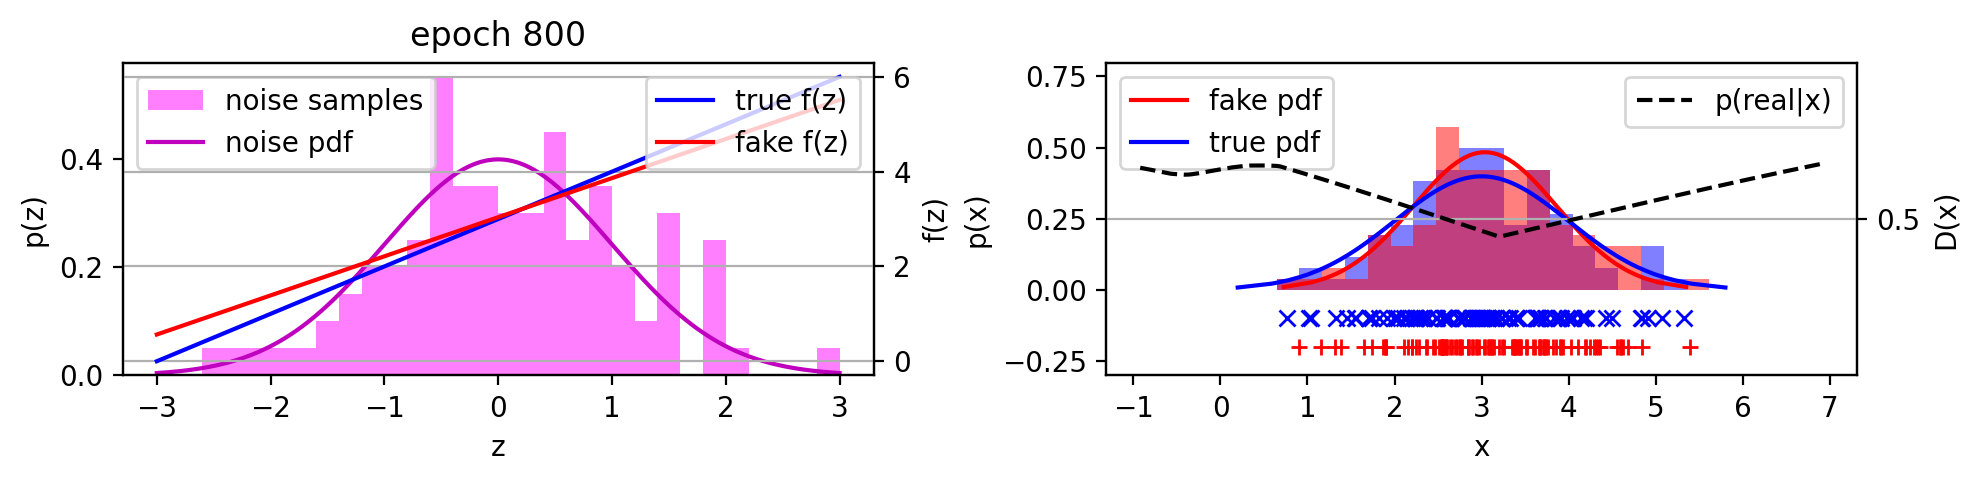

In [119]:
epochs['figs'][8]

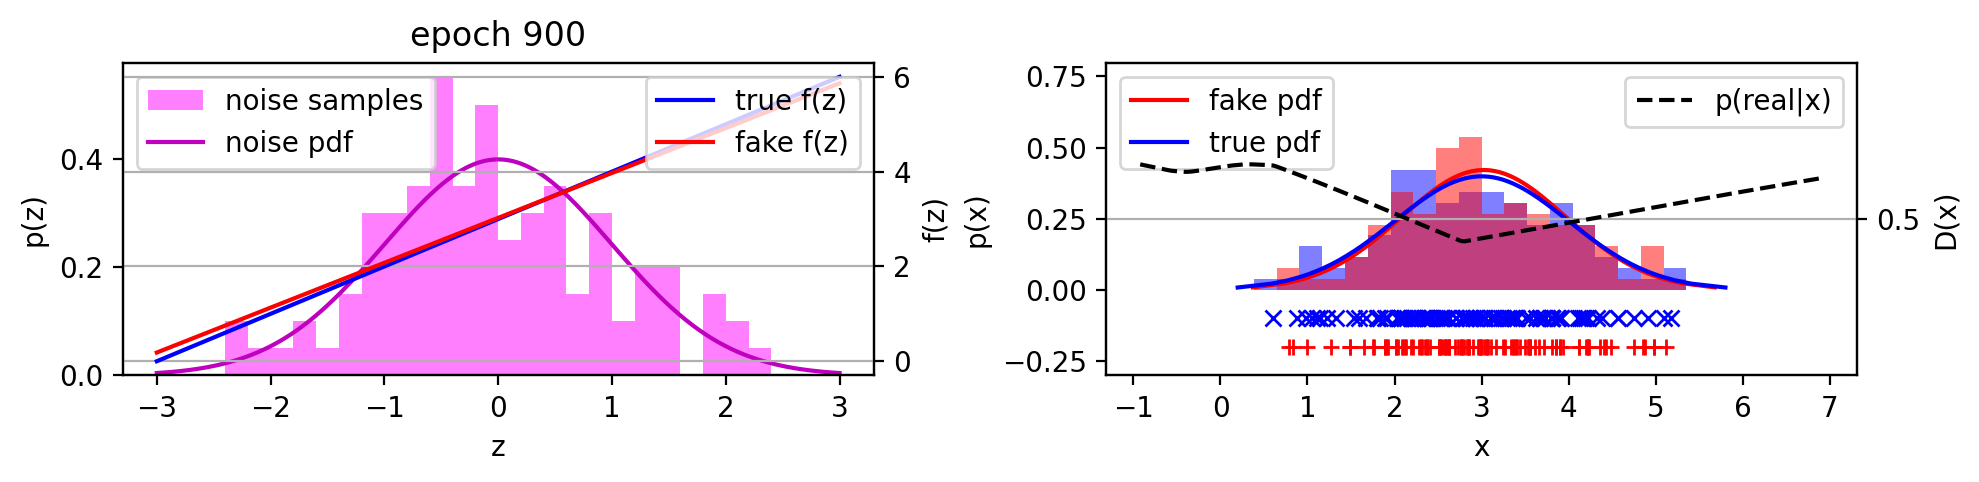

In [120]:
epochs['figs'][9]

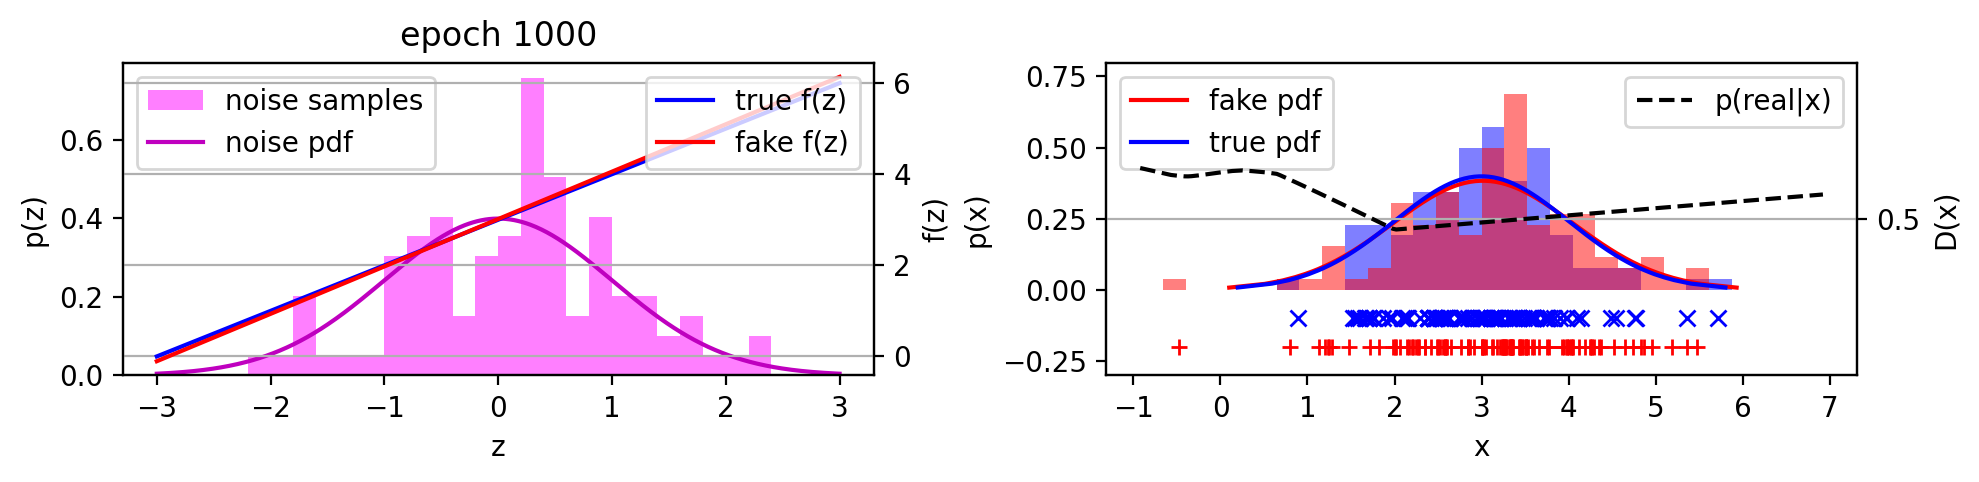

In [121]:
epochs['figs'][10]

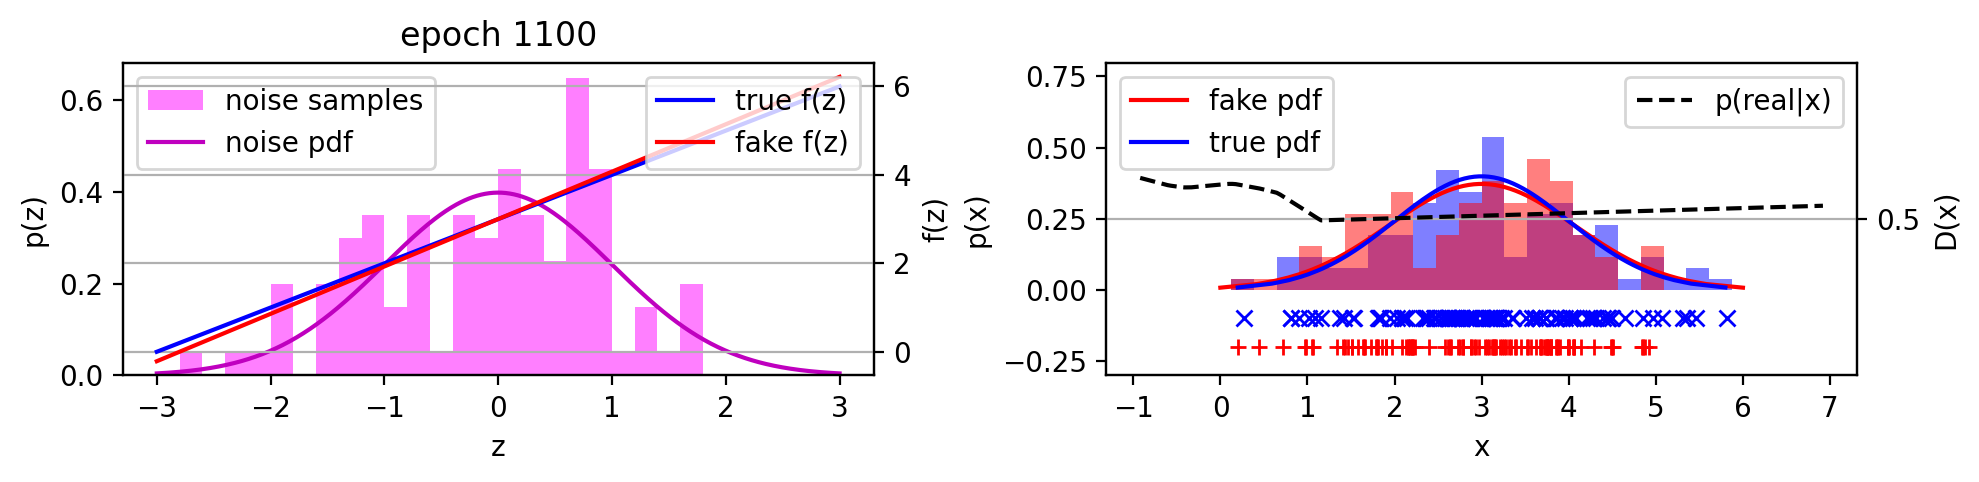

In [122]:
epochs['figs'][11]

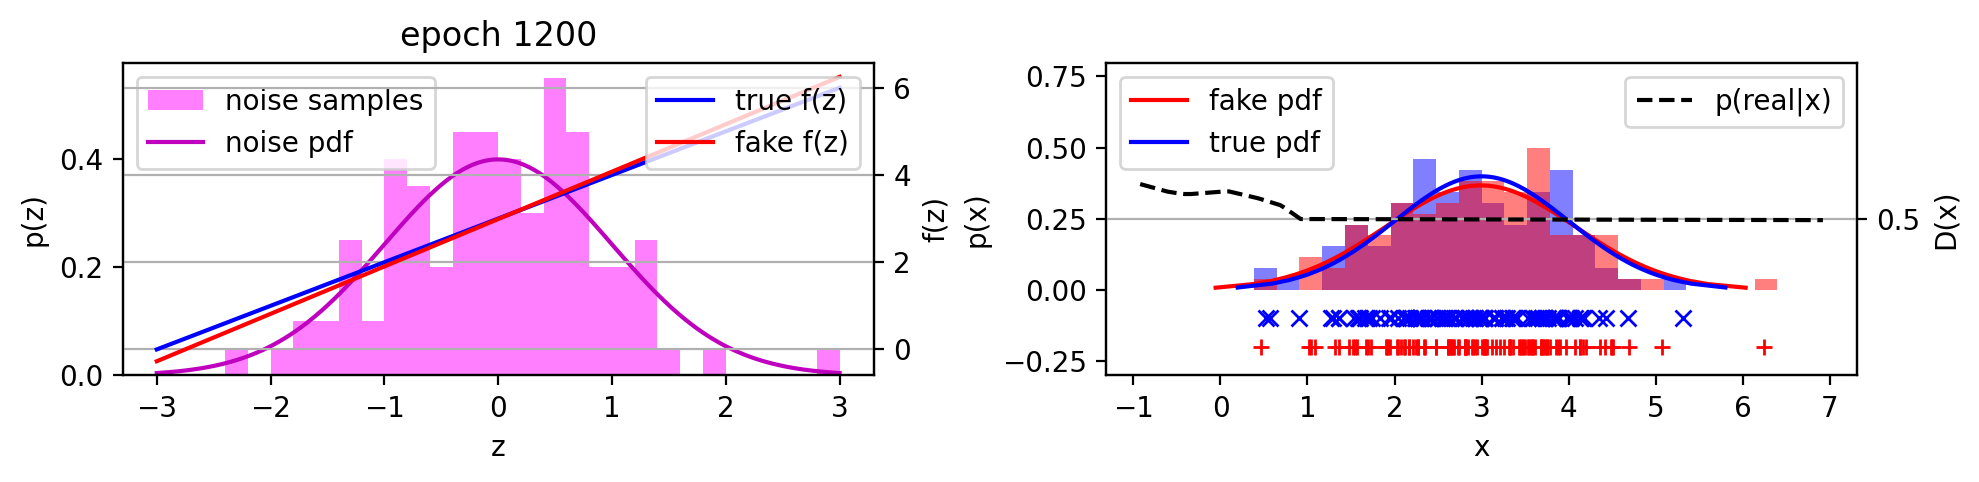

In [123]:
epochs['figs'][12]

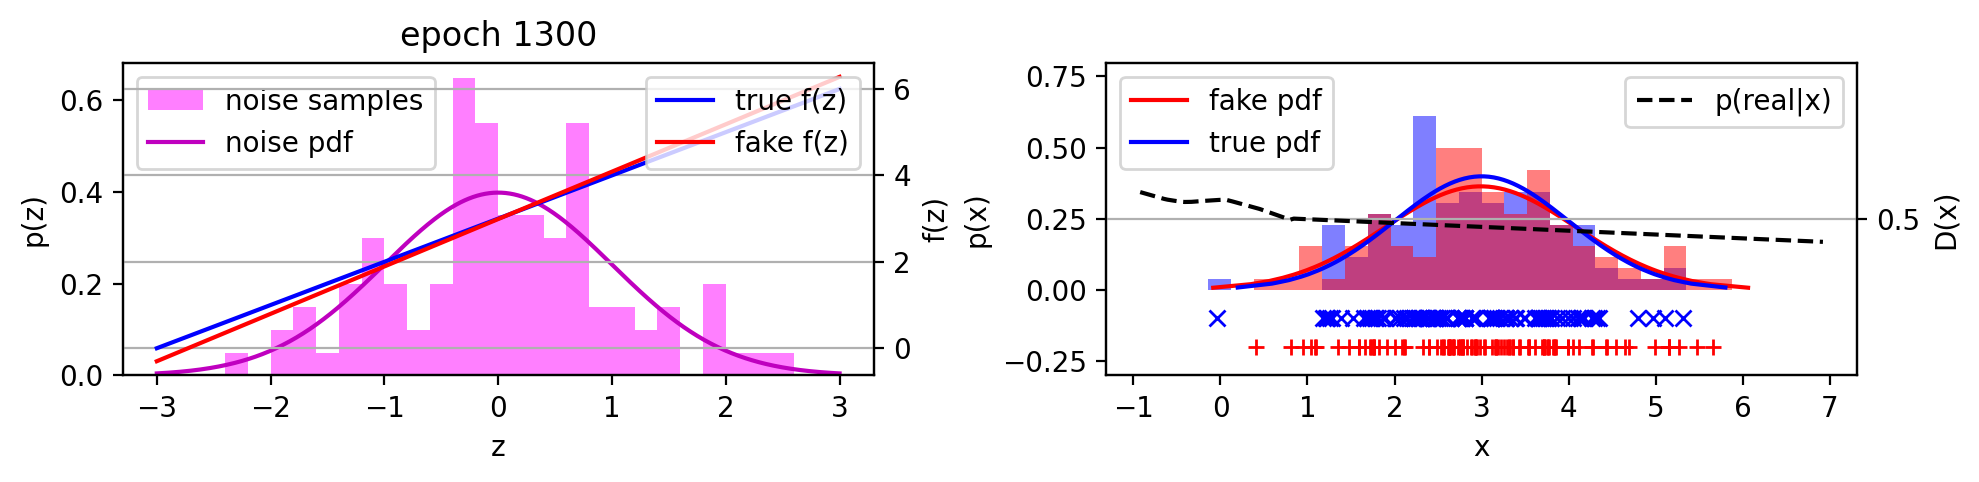

In [124]:
epochs['figs'][13]

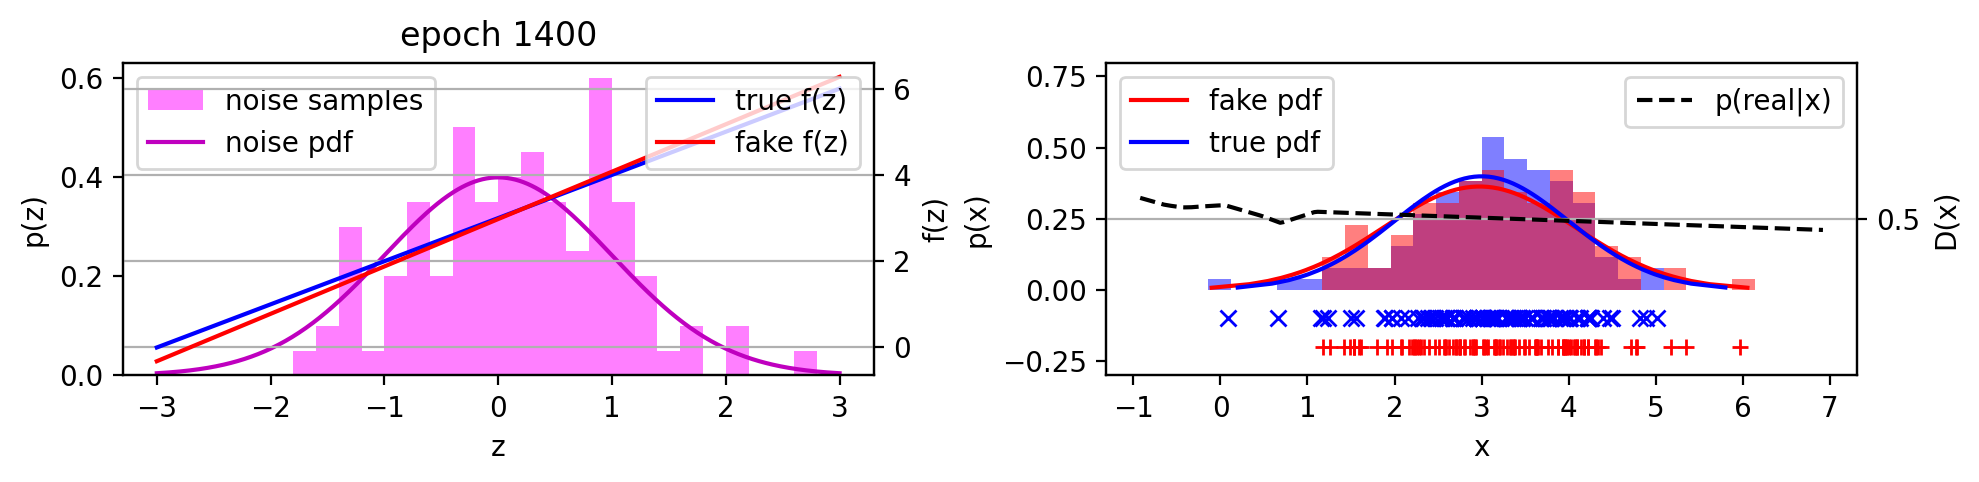

In [125]:
epochs['figs'][14]

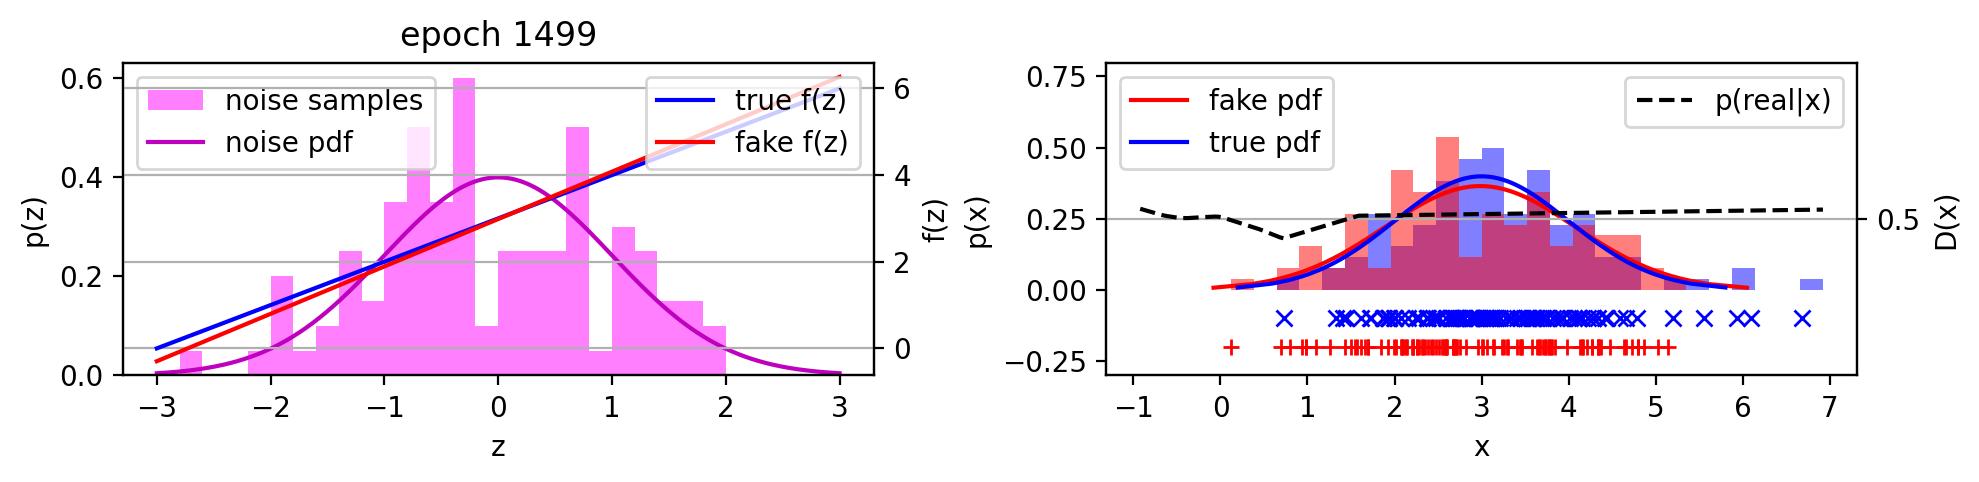

In [126]:
epochs['figs'][15]

# Example on MNIST 
- use a deep convolutional network as the generator (Source: [post](https://www.wouterbulten.nl/blog/tech/getting-started-with-generative-adversarial-networks/]), [code](https://github.com/wouterbulten/deeplearning-resources/blob/master/notebooks/1%20-%20Getting%20started%20with%20Generative%20Adversarial%20Networks%20using%20Keras%20and%20MNIST.ipynb))
<center><img src="imgs/dcgan.png" width=500></center>
- generated images
<center><img src="imgs/mnistkeras_24_0_10k_generated.png" width=500></center>

- generated examples during training
<center><img src="imgs/learning_10k_optim.gif" width=400></center>

# Example: Style transfer (CycleGAN)

<center><img src="imgs/CycleGAN.png" width=600></center>


# Example: Face Synthesis
- Which faces are fake?
<center><img src="imgs/faceGAN.png" width=600></center>


  - Try it out: https://thispersondoesnotexist.com (broken)
    - https://this-person-does-not-exist.com/en
    - https://www.unrealperson.com

# Diffusion Models

- Define a forward diffusion process that gradually turns an image into noise.
- Learn the reverse process that can gradually remove the noise and recover the image. 
  - _key difference_: supervision on each reverse step.
  
<center><img src="imgs/generative_models.png" width=500></center>

# Forward diffusion process
- In each step, fade the image and add Gaussian noise.
  - $\mathbf{x_0}$ = image
  - $\mathbf{x_t} = \sqrt{1-\beta_t}\mathbf{x}_{t-1} + \sqrt{\beta_t}\epsilon_t$, $\epsilon_t\sim \cal{N}(0,\mathbf{I})$
  - Noise variance schedule: $\{\beta_1,\cdots,\beta_T\}$
- Probability distributions
  - for one step: $q(\mathbf{x}_t | \mathbf{x}_{t-1}) = {\cal N}(\mathbf{x}_{t} | \sqrt{1-\beta_t}\mathbf{x}_{t-1}, \beta_t \mathbf{I})$
  - for all steps: $q(\mathbf{x}_{1:T} | \mathbf{x}_0) = \prod_{t=1}^T q(\mathbf{x}_t | \mathbf{x}_{t-1})$

<center><img src="imgs/diff-forward.png" width=900></center>

# Reverse diffusion process

- We want recover the image from the noise.
  - the true reverse process $q(\mathbf{x}_{t-1}|\mathbf{x}_{t})$ is not tractable.
- Approximate it with a parametric model (NN) $p_{\theta}(\mathbf{x}_{t-1}|\mathbf{x}_t)$
  - assume Gaussian: $p_{\theta}(\mathbf{x}_{t-1}|\mathbf{x}_t) = {\cal N}(\mathbf{x}_{t-1}|\mathbf{\mu}_{\theta}(\mathbf{x}_t,t), \Sigma_\theta(\mathbf{x}_t,t))$
  - for all steps: $p(\mathbf{x}_{0:T}) = p_{\theta}(\mathbf{x}_T)\prod_{t=1}^T p_{\theta}(\mathbf{x}_{t-1}|\mathbf{x}_t)$
  
<center><img src="imgs/diff-reverse.png" width=900></center>

# Training 

- minimize an upper-bound on the negative data log-likelihood.
  $$\mathbb{E}[-\log p_\theta(\mathbf{x}_0)] \leq \mathbb{E}_q\left[-\log \frac{p_{\theta}(\mathbf{x}_{0:T})}{q(\mathbf{x}_{1:T}|\mathbf{x}_0)}\right] = \sum_{t=0}^T L_t$$
  - $L_0 = -\log p_{\theta}(\mathbf{x}_0|\mathbf{x}_1)$
  - $L_{t-1} = KL(q(\mathbf{x}_{t-1}|\mathbf{x}_t,\mathbf{x}_0),  p(\mathbf{x}_{t-1} | \mathbf{x}_t))$
  - $L_T = KL(q(\mathbf{x}_T|\mathbf{x}_0,  p(\mathbf{x}_T))$
- Usually use a U-net to model $\mu_\theta,\Sigma_\theta$.
- After simplification we usually optimize for $$ \mathbb{E}_{t,x_0,\epsilon} \|\epsilon-\epsilon_{\theta}(x_t,t)\|^2 $$

<center><img src="imgs/loss_fig.png" width=600></center>

<center>
<img src="imgs/ddpm1.png" width=900>
</center>

<center>
<img src="imgs/ddpm2.png" width=900>
</center>

# Summary

- **Unsupervised Learning**
  - Autoencoder - unsupervised dimensionality reduction and clustering.
  - Convolutional autoencoder - AE for images.
  - Masked Autoencoder (MAE) - self-supervised representation learning
  - Variational autoencoder (VAE) - improve interpolation ability, generative model
  - Generative Adversarial Networks (GAN) - learn to generate samples from a distribution
  - Diffusion model - transform noise into image, step by step.